# Localization-rApp: Estimação do Andar do UE com Non-RT RIC


**Relatório técnico autocontido** — Parte 3 do projeto final

Baseado em: *"RAN Intelligent Controller (RIC): From open-source implementation to real-world validation"*, caso de uso **Localization-rApp**.

Dataset público: [FCCLab/sutd_5g_dataset_2023](https://github.com/FCCLab/sutd_5g_dataset_2023/tree/dataset) (já clonado localmente em `sutd_5g_dataset_2023/`).



## 1. Introdução

### Roteiro deste notebook

1. Introdução (este texto) | 2. Caso de uso | 3. Dataset | 4. Construção do target |
5. Auditoria | 6. Pré-processamento | 7. Protocolos experimentais | 8. Modelos |
9. Resultados do Protocolo A | 10. Resultados do Protocolo B | 11. Comparação
instance vs. sequence | 12. Comparação com o artigo | 13. Estudo de janela |
14. Ablation study | 15. Teste OOD | 16. Discussão | 17. Limitações | 18. Conclusão |
19. Arquivos gerados.

## 2. Caso de uso

### 2.1 O caso de uso Localization-rApp

O artigo de referência descreve uma arquitetura O-RAN em que funções de inteligência de rede (rApps) são executadas sobre o **Non-RT RIC** (Non-Real-Time RAN Intelligent Controller), consumindo indicadores de desempenho de rádio (RSRP, RSRQ, SINR, MCS, PRBs, throughput, etc.) coletados via interfaces de monitoramento (O1/O-FH ou equivalentes) e produzindo inferências que realimentam decisões de gerenciamento de rede em escalas de tempo não críticas (segundos a minutos).

O **Localization-rApp** é um desses casos de uso: em vez de localizar o UE via GPS (indisponível em ambientes indoor) ou via triangulação de múltiplas células, a rApp estima o **andar do prédio (floor)** em que o UE se encontra **exclusivamente a partir de métricas de camada física/MAC coletadas pela própria rede**. Essa é uma forma de *radio-fingerprinting*: cada andar produz uma assinatura estatística característica de RSRP/RSRQ/SINR/MCS/PRBs devido a diferenças de propagação, obstrução por lajes/paredes e distância às RRUs (Remote Radio Units).

### 2.2 Diferença entre localização por andar e localização GPS

| | Localização GPS | Localização por andar (Localization-rApp) |
|---|---|---|
| Sinal usado | Satélite (GNSS) | Indicadores de rádio celular (RSRP, RSRQ, SINR, MCS, PRBs, throughput) |
| Funciona indoor? | Não (ou com grande erro) | Sim — é o cenário-alvo |
| Granularidade | Coordenadas contínuas (lat/lon/alt) | Classe discreta (andar 0, 1, 2, ...) |
| Custo de hardware no UE | Chip GNSS dedicado | Nenhum — usa medições já reportadas pela rede/UE |
| Onde roda a inferência | Dispositivo | Non-RT RIC (rApp), fora do UE |

Ou seja, este não é um problema de regressão de coordenadas, e sim um problema de **classificação multiclasse**: dado um vetor (ou uma janela temporal) de indicadores de rádio, prever a que andar (classe) ele pertence.

### 2.3 Relação com o Non-RT RIC

Na arquitetura O-RAN, o Non-RT RIC hospeda rApps que operam em ciclos de segundos a minutos (em oposição ao Near-RT RIC, que opera em 10 ms–1 s). A Localization-rApp se encaixa nessa camada porque:

- não exige controle de rádio em tempo real (não decide handover instantaneamente);
- consome dados históricos/quase em tempo real via interface O1/R1;
- produz uma estimativa de localização que outras rApps (ex.: otimização de cobertura, balanceamento de carga, rApps de manutenção preditiva) podem consumir como contexto adicional.

A métrica de **tempo de inferência** (Seções 9-10) é relevante justamente para avaliar se o modelo é compatível com esse orçamento de latência do Non-RT RIC.

### 2.4 Reconstrução do rótulo de localização a partir dos cenários

O dataset **não contém uma coluna `location`**. Em vez disso, os arquivos são organizados por cenário de coleta (andar + configuração de RRUs ativas). Seguimos estritamente a especificação deste projeto:

$$
\text{location} =
\begin{cases}
0, & \text{arquivo do cenário Level 4} \\
1, & \text{arquivo do cenário Level 5} \\
2, & \text{arquivo do cenário Level 6 com todas as RRUs ativas}
\end{cases}
$$

O cenário **Level 6 com apenas 1 RRU ativa** (`Lvl6_1RRUOn`) fica **fora do treinamento principal** — ele representa uma configuração de infraestrutura diferente (menos RRUs ativas altera a assinatura de rádio do mesmo andar) e é usado apenas na Seção 15 como teste de generalização *out-of-distribution* (OOD).

A coluna `Label` do dataset **não é usada como rótulo de localização**: como veremos na auditoria de colunas (Seção 5), `Label` é, na verdade, uma codificação combinada de outras colunas auxiliares (`lab_anom`, `lab_bs`, `lab_inf`, `lab_1rr`) relacionadas a anomalias e não à localização por andar.

## 3. Dataset

### 3.1 Configuração e reprodutibilidade

Definimos aqui uma função global de sementes que fixa `random`, NumPy, PyTorch e CUDA (quando
disponível) de uma só vez, e registramos versões de bibliotecas e hardware. A semente principal
usada em toda a reprodução é **42**; uma análise de estabilidade com sementes adicionais
(`[21, 42, 84, 126, 168]`) aparece na Seção 9 como evidência complementar, sem substituir o
resultado principal.

In [1]:
import os
import sys
import json
import glob
import re
import io
import time
import datetime
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn import __version__ as sklearn_version
import xgboost
import torch
import torch.nn as nn

SEED = 42
MULTI_SEEDS = [21, 42, 84, 126, 168]


def set_global_seed(seed: int) -> None:
    '''Fixa a semente em todas as bibliotecas com componente aleatorio usadas neste notebook.'''
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Semente global (SEED):", SEED)
print("Sementes para analise de estabilidade (Secao 9):", MULTI_SEEDS)

Semente global (SEED): 42
Sementes para analise de estabilidade (Secao 9): [21, 42, 84, 126, 168]


In [2]:
PROJECT_ROOT = Path(".").resolve()
DATASET_DIR = PROJECT_ROOT / "sutd_5g_dataset_2023" / "dataset"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

MODEL_SUBDIRS = {
    ("A", "instance"): MODELS_DIR / "protocol_a" / "instance",
    ("A", "sequence"): MODELS_DIR / "protocol_a" / "sequence",
    ("B", "instance"): MODELS_DIR / "protocol_b" / "instance",
    ("B", "sequence"): MODELS_DIR / "protocol_b" / "sequence",
}

for d in (FIGURES_DIR, RESULTS_DIR, MODELS_DIR, *MODEL_SUBDIRS.values()):
    d.mkdir(parents=True, exist_ok=True)

# Lista explicita das figuras que ESTA versao do notebook gera (Secoes 6-15). Usada para limpar,
# de forma controlada, artefatos obsoletos de versoes anteriores do notebook (ex.: figuras
# renomeadas/removidas), sem jamais apagar arquivos-fonte ou imagens externas -- este projeto nao
# usa nenhuma imagem externa em figures/, todas sao geradas por este notebook via save_fig().
EXPECTED_FIGURE_FILES = {
    "01_distribuicao_classes.png", "02_serie_temporal_rsrp_rsrq_sinr.png",
    "03_histogramas_features_por_classe.png", "04_boxplots_features_por_andar.png",
    "05_matriz_correlacao.png", "06_pca_2d.png", "07_valores_ausentes.png",
    "08_intervalo_amostragem.png", "09_matriz_confusao_instance_A.png",
    "10_matriz_confusao_sequence_A.png", "11_matriz_confusao_instance_B.png",
    "12_matriz_confusao_sequence_B.png", "13_curvas_treino_lstm3layer.png",
    "14_instance_vs_sequence_protocolo_A.png", "15_instance_vs_sequence_protocolo_B.png",
    "16_lstm1layer_vs_lstm3layer.png", "17_protocolo_A_vs_B_por_modelo.png",
    "18_sensibilidade_tamanho_janela.png", "19_ablacao_features.png",
    "20_teste_ood_distribuicao_confianca.png",
}

obsolete_figures_removed = []
for p in sorted(FIGURES_DIR.glob("*.png")):
    if p.name not in EXPECTED_FIGURE_FILES:
        obsolete_figures_removed.append(p.name)
        p.unlink()

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_DIR :", DATASET_DIR, "existe?", DATASET_DIR.exists())
print("FIGURES_DIR :", FIGURES_DIR)
print("RESULTS_DIR :", RESULTS_DIR)
print("MODELS_DIR  :", MODELS_DIR, "com subpastas:", [str(p.relative_to(PROJECT_ROOT)) for p in MODEL_SUBDIRS.values()])
if obsolete_figures_removed:
    print(f"\nFiguras obsoletas removidas de figures/ ({len(obsolete_figures_removed)}):", obsolete_figures_removed)
else:
    print("\nNenhuma figura obsoleta encontrada em figures/.")

PROJECT_ROOT: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta
DATASET_DIR : C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\sutd_5g_dataset_2023\dataset existe? True
FIGURES_DIR : C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures
RESULTS_DIR : C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\results
MODELS_DIR  : C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\models com subpastas: ['models\\protocol_a\\instance', 'models\\protocol_a\\sequence', 'models\\protocol_b\\instance', 'models\\protocol_b\\sequence']

Nenhuma figura obsoleta encontrada em figures/.


In [3]:
versions = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn_version,
    "xgboost": xgboost.__version__,
    "torch": torch.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "seaborn": sns.__version__,
    "joblib": joblib.__version__,
}
for k, v in versions.items():
    print(f"{k:15s}: {v}")

try:
    import psutil
    mem_gb = psutil.virtual_memory().total / (1024 ** 3)
except Exception:
    mem_gb = None

hardware_info = {
    "platform": platform.platform(),
    "processor": platform.processor(),
    "cpu_count_logical": os.cpu_count(),
    "memory_total_gb": round(mem_gb, 1) if mem_gb else None,
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print()
for k, v in hardware_info.items():
    print(f"{k:20s}: {v}")
print("\nDispositivo de treino/inferencia usado neste notebook:", DEVICE)

python         : 3.13.14
numpy          : 2.5.0
pandas         : 3.0.3
scikit-learn   : 1.9.0
xgboost        : 3.3.0
torch          : 2.12.0+cpu
matplotlib     : 3.10.9
seaborn        : 0.13.2
joblib         : 1.5.3

platform            : Windows-11-10.0.26200-SP0
processor           : Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
cpu_count_logical   : 16
memory_total_gb     : 15.6
cuda_available      : False
gpu_name            : None

Dispositivo de treino/inferencia usado neste notebook: cpu


> **Nota metodológica sobre hardware.** Todo o treinamento e a medição de tempo de inferência deste notebook foram executados em **CPU** (ver saída acima). O artigo de referência não detalha o hardware usado para medir os tempos de inferência da Tabela da Seção 12, compatíveis com GPU dedicada, hardware embarcado otimizado, ou builds com otimizações não replicadas aqui. Os tempos absolutos **não são diretamente comparáveis** entre este relatório e o artigo — apenas a ordem de grandeza relativa entre modelos deste notebook é informativa.

### 3.2 O dataset SUTD 5G 2023

O dataset foi coletado em um testbed 5G privado no campus da Singapore University of Technology and Design (SUTD), usando um Samsung Galaxy S22 Ultra com o software Nemo Handy/Nemo Analyze, em uma taxa de amostragem de aproximadamente 2 Hz. Foram registradas 4 sessões de caminhada ("walk tests"), uma por cenário:

1. Level 4, todas as RRUs ativas (cobertura ruim);
2. Level 5, todas as RRUs ativas (célula indoor);
3. Level 6, todas as RRUs ativas (boa cobertura);
4. Level 6, apenas 1 RRU ativa (medição de RRU única).

### 3.3 Descoberta e inspeção dos arquivos

O notebook **detecta automaticamente** os cenários a partir de padrões no nome do arquivo, aceitando variações como `Lvl4`, `Level4`, `Level_4`, `AllRRUOn`, `1RRU`, `OneRRUOn`, etc. Arquivos ambíguos são reportados separadamente, nunca inferidos silenciosamente.

In [4]:
LEVEL_PATTERNS = {
    4: re.compile(r"lvl[_\s]?4|level[_\s]?4", re.IGNORECASE),
    5: re.compile(r"lvl[_\s]?5|level[_\s]?5", re.IGNORECASE),
    6: re.compile(r"lvl[_\s]?6|level[_\s]?6", re.IGNORECASE),
}
ALL_RRU_PATTERN = re.compile(r"all[_\s]?rru", re.IGNORECASE)
ONE_RRU_PATTERN = re.compile(r"(?:^|[^a-z0-9])1[_\s]?rru|one[_\s]?rru", re.IGNORECASE)

LEVEL_TO_LOCATION = {4: 0, 5: 1, 6: 2}
LEVEL_TO_FLOOR_NAME = {4: "Level 4", 5: "Level 5", 6: "Level 6"}


def infer_scenario(filepath: str) -> dict:
    '''Infere nivel (4/5/6) e modo de RRU (all_rru/one_rru) a partir do nome do arquivo.'''
    base = os.path.basename(filepath)
    levels_found = [lvl for lvl, pat in LEVEL_PATTERNS.items() if pat.search(base)]
    is_all_rru = bool(ALL_RRU_PATTERN.search(base))
    is_one_rru = bool(ONE_RRU_PATTERN.search(base))

    info = {"file": base, "path": filepath, "level": None, "rru_mode": None,
            "ambiguous": False, "reason": None}

    if len(levels_found) != 1:
        info["ambiguous"] = True
        info["reason"] = f"padrao de nivel ambiguo ou ausente (candidatos={levels_found})"
        return info

    level = levels_found[0]
    info["level"] = level

    if is_all_rru and not is_one_rru:
        info["rru_mode"] = "all_rru"
    elif is_one_rru and not is_all_rru:
        info["rru_mode"] = "one_rru"
    elif level in (4, 5):
        info["rru_mode"] = "all_rru"
    else:
        info["ambiguous"] = True
        info["reason"] = "nivel 6 sem indicacao clara de all_rru vs one_rru no nome do arquivo"

    return info


def discover_files(dataset_dir) -> list:
    csvs = sorted(glob.glob(str(Path(dataset_dir) / "*.csv")))
    return [infer_scenario(f) for f in csvs]

In [5]:
file_infos = discover_files(DATASET_DIR)
if not file_infos:
    raise FileNotFoundError(f"Nenhum CSV encontrado em {DATASET_DIR}.")

rows = []
for info in file_infos:
    df_tmp = pd.read_csv(info["path"])
    rows.append({
        "arquivo": info["file"], "nivel_inferido": info["level"], "modo_rru": info["rru_mode"],
        "ambiguo": info["ambiguous"], "motivo_ambiguidade": info["reason"],
        "n_linhas": df_tmp.shape[0], "n_colunas": df_tmp.shape[1],
    })
discovery_table = pd.DataFrame(rows)
discovery_table

,arquivo,nivel_inferido,modo_rru,ambiguo,motivo_ambiguidade,n_linhas,n_colunas
0,Lvl4_AllRRUOn_Anomaly_label.csv,4,all_rru,False,None,2327,19
1,Lvl5_AllRRUOn_Anomaly_label.csv,5,all_rru,False,None,2031,19
2,Lvl6_1RRUOn_Anomaly_label.csv,6,one_rru,False,None,2156,19
3,Lvl6_AllRRUOn_Anomaly_label.csv,6,all_rru,False,None,2222,19


In [6]:
main_infos = [i for i in file_infos if not i["ambiguous"] and i["level"] in (4, 5) and i["rru_mode"] == "all_rru"]
main_infos += [i for i in file_infos if not i["ambiguous"] and i["level"] == 6 and i["rru_mode"] == "all_rru"]
ood_infos = [i for i in file_infos if not i["ambiguous"] and i["level"] == 6 and i["rru_mode"] == "one_rru"]
ambiguous_infos = [i for i in file_infos if i["ambiguous"]]

print("Arquivos do conjunto PRINCIPAL (localizacao 0/1/2):")
for i in main_infos:
    print(f"  - {i['file']}  (level={i['level']} -> location={LEVEL_TO_LOCATION[i['level']]}, rru={i['rru_mode']})")
print("\nArquivos reservados para teste OOD (Level 6, 1 RRU):")
for i in ood_infos:
    print(f"  - {i['file']}")
print("\nArquivos AMBIGUOS (nao utilizados):")
for i in ambiguous_infos:
    print(f"  - {i['file']}: {i['reason']}")
if not ambiguous_infos:
    print("  (nenhum)")

missing_levels = {4, 5, 6} - {i["level"] for i in main_infos}
print("\nCenarios principais ausentes:", missing_levels if missing_levels else "nenhum -- todos presentes")

Arquivos do conjunto PRINCIPAL (localizacao 0/1/2):
  - Lvl4_AllRRUOn_Anomaly_label.csv  (level=4 -> location=0, rru=all_rru)
  - Lvl5_AllRRUOn_Anomaly_label.csv  (level=5 -> location=1, rru=all_rru)
  - Lvl6_AllRRUOn_Anomaly_label.csv  (level=6 -> location=2, rru=all_rru)

Arquivos reservados para teste OOD (Level 6, 1 RRU):
  - Lvl6_1RRUOn_Anomaly_label.csv

Arquivos AMBIGUOS (nao utilizados):
  (nenhum)

Cenarios principais ausentes: nenhum -- todos presentes


### 3.4 Inconsistência encontrada entre o README do dataset e os arquivos do Level 6

O `README.md` do repositório do dataset apresenta a seguinte tabela de contagens (reproduzida
literalmente):

| Cenário | Duração | # Amostras (README) |
|---|---|---|
| Level 6, 2 RRUs externas ativas | 19min 9s | 2156 |
| Level 6, apenas 1 RRU externa ativa | 18min 56s | 2222 |

Isso **diverge** da contagem real de linhas dos arquivos e do nome dos próprios arquivos:
`Lvl6_AllRRUOn_Anomaly_label.csv` (nome indica *todas* as RRUs ativas) tem 2222 linhas, e
`Lvl6_1RRUOn_Anomaly_label.csv` (nome indica *apenas 1 RRU* ativa) tem 2156 linhas — exatamente
o **oposto** do que a tabela do README afirma para essas contagens.

Para não assumir silenciosamente qual fonte está correta, validamos a consistência **interna** de
cada arquivo através da coluna `lab_1rr` (rótulo auxiliar que indica explicitamente se apenas 1 RRU
estava ativa), que deve concordar com o nome do arquivo independentemente do que o README declara.

> **Formulação adotada** (deliberadamente cautelosa): foi identificada uma divergência entre a
> documentação do repositório (tabela do `README.md`) e os arquivos distribuídos. Nesta
> implementação, o **nome dos arquivos** e a **coluna interna `lab_1rr`** foram adotados como
> fontes operacionais de verdade por apresentarem consistência entre si (ver asserts abaixo). Com
> os materiais disponíveis, **não é possível determinar de forma conclusiva em qual artefato
> ocorreu o erro original** — o README poderia ter as contagens trocadas, ou, em tese, os arquivos
> poderiam ter sido renomeados incorretamente após a tabela ter sido escrita. Não afirmamos que "o
> README está errado": apenas que nome de arquivo e `lab_1rr` concordam entre si e foram usados
> como critério de decisão.

In [7]:
df_lvl6_all_raw = pd.read_csv(next(i["path"] for i in main_infos if i["level"] == 6))
df_lvl6_one_raw = pd.read_csv(next(i["path"] for i in ood_infos))

audit_rows = [
    {
        "arquivo": "Lvl6_AllRRUOn_Anomaly_label.csv",
        "n_amostras_arquivo": len(df_lvl6_all_raw),
        "n_amostras_README": 2156,
        "lab_1rr_unicos": sorted(df_lvl6_all_raw["lab_1rr"].unique().tolist()),
    },
    {
        "arquivo": "Lvl6_1RRUOn_Anomaly_label.csv",
        "n_amostras_arquivo": len(df_lvl6_one_raw),
        "n_amostras_README": 2222,
        "lab_1rr_unicos": sorted(df_lvl6_one_raw["lab_1rr"].unique().tolist()),
    },
]
dataset_audit_df = pd.DataFrame(audit_rows)
dataset_audit_df["README_bate_com_arquivo"] = (
    dataset_audit_df["n_amostras_arquivo"] == dataset_audit_df["n_amostras_README"]
)
# Campos adicionais (formulacao cautelosa -- ver caixa acima): registramos separadamente (1) se a
# documentacao bate com a contagem de arquivos, (2) se nome de arquivo e coluna interna lab_1rr
# concordam ENTRE SI (independente do README), (3) qual fonte foi adotada operacionalmente, e
# (4) se e possivel afirmar CONCLUSIVAMENTE onde esta o erro original -- nao e.
dataset_audit_df["documentation_file_count_consistent"] = False
dataset_audit_df["filename_internal_label_consistent"] = True
dataset_audit_df["decision_source"] = "filename_and_lab_1rr"
dataset_audit_df["conclusive_error_location"] = False
display(dataset_audit_df)

assert df_lvl6_all_raw["lab_1rr"].eq(0).all(), (
    "Lvl6_AllRRUOn_Anomaly_label.csv deveria ter lab_1rr=0 em 100% das linhas -- "
    "verifique se o arquivo correto foi carregado."
)
assert df_lvl6_one_raw["lab_1rr"].eq(1).all(), (
    "Lvl6_1RRUOn_Anomaly_label.csv deveria ter lab_1rr=1 em 100% das linhas -- "
    "verifique se o arquivo correto foi carregado."
)
print("\nAsserts de consistencia lab_1rr: OK.")
print("OBSERVACAO: nome do arquivo e coluna interna lab_1rr concordam entre si")
print("(AllRRUOn -> lab_1rr=0 em 100% das linhas; 1RRUOn -> lab_1rr=1 em 100% das linhas),")
print("enquanto a tabela de contagens do README NAO bate com nenhuma das duas fontes na")
print("mesma correspondencia. Com os materiais disponiveis, NAO e possivel determinar de forma")
print("conclusiva em qual artefato (README ou arquivos) ocorreu o erro original -- adotamos")
print("nome de arquivo + lab_1rr (que concordam entre si) como fonte operacional de verdade")
print("para todo o restante do notebook (decision_source='filename_and_lab_1rr').")

dataset_audit_df.to_csv(RESULTS_DIR / "dataset_audit.csv", index=False)

,arquivo,n_amostras_arquivo,n_amostras_README,lab_1rr_unicos,README_bate_com_arquivo,documentation_file_count_consistent,filename_internal_label_consistent,decision_source,conclusive_error_location
0,Lvl6_AllRRUOn_Anomaly_label.csv,2222,2156,[0],False,False,True,filename_and_lab_1rr,False
1,Lvl6_1RRUOn_Anomaly_label.csv,2156,2222,[1],False,False,True,filename_and_lab_1rr,False



Asserts de consistencia lab_1rr: OK.
OBSERVACAO: nome do arquivo e coluna interna lab_1rr concordam entre si
(AllRRUOn -> lab_1rr=0 em 100% das linhas; 1RRUOn -> lab_1rr=1 em 100% das linhas),
enquanto a tabela de contagens do README NAO bate com nenhuma das duas fontes na
mesma correspondencia. Com os materiais disponiveis, NAO e possivel determinar de forma
conclusiva em qual artefato (README ou arquivos) ocorreu o erro original -- adotamos
nome de arquivo + lab_1rr (que concordam entre si) como fonte operacional de verdade
para todo o restante do notebook (decision_source='filename_and_lab_1rr').


## 4. Construção do target

Para cada arquivo do conjunto principal: carregamos o CSV, criamos `source_file`, `floor_name` e
`location` (Seção 2.4), concatenamos os três cenários e ordenamos por `source_file` e `Time`,
preservando a ordem temporal original dentro de cada arquivo. O mesmo procedimento é aplicado
(separadamente) ao arquivo Level 6 (1RRU), armazenado em `df_ood`, que **não entra no conjunto
principal**.

In [8]:
def load_scenario_file(info: dict, floor_suffix: str = "") -> pd.DataFrame:
    df = pd.read_csv(info["path"])
    df["source_file"] = info["file"]
    df["floor_name"] = LEVEL_TO_FLOOR_NAME[info["level"]] + floor_suffix
    df["location"] = LEVEL_TO_LOCATION[info["level"]]
    return df


def load_and_concat(infos: list, floor_suffix: str = ""):
    if not infos:
        return None
    frames = [load_scenario_file(i, floor_suffix) for i in infos]
    df = pd.concat(frames, ignore_index=True)
    df["Time"] = pd.to_datetime(df["Time"])
    df = df.sort_values(["source_file", "Time"], kind="mergesort").reset_index(drop=True)
    return df


df_main = load_and_concat(main_infos, floor_suffix="")
df_ood = load_and_concat(ood_infos, floor_suffix=" (1 RRU)")

print("df_main shape:", None if df_main is None else df_main.shape)
print("df_ood  shape:", None if df_ood is None else df_ood.shape)

df_main shape: (6580, 22)
df_ood  shape: (2156, 22)


In [9]:
if df_main is not None:
    summary = (
        df_main.groupby(["location", "floor_name"]).size().reset_index(name="n_amostras")
        .sort_values("location")
    )
    summary["percentual_%"] = (summary["n_amostras"] / len(df_main) * 100).round(2)
    display(summary)
else:
    print("df_main esta vazio -- nenhum arquivo do conjunto principal foi encontrado.")

,location,floor_name,n_amostras,percentual_%
0,0,Level 4,2327,35.36
1,1,Level 5,2031,30.87
2,2,Level 6,2222,33.77


### Verificação de suficiência de classes para treinamento

Caso menos de três classes principais estejam disponíveis, o notebook realiza toda a inspeção
exploratória possível, explica a impossibilidade de treinar um classificador multiclasse, mostra
quais arquivos faltam, e **pula apenas as etapas de treinamento** de forma amigável — controlado
pela variável `PIPELINE_READY`, verificada em todas as células de treinamento a partir da Seção 7.

In [10]:
REQUIRED_MAIN_LEVELS = {0: "Level 4 (AllRRUOn)", 1: "Level 5 (AllRRUOn)", 2: "Level 6 (AllRRUOn)"}
present_locations = set(df_main["location"].unique()) if df_main is not None else set()
missing_locations = set(REQUIRED_MAIN_LEVELS) - present_locations
PIPELINE_READY = (df_main is not None) and (len(missing_locations) == 0) and (len(present_locations) >= 2)

print("=" * 72)
if not PIPELINE_READY:
    print("AVISO: dados insuficientes para treinar o classificador de localizacao.")
    for loc, desc in REQUIRED_MAIN_LEVELS.items():
        status = "OK" if loc in present_locations else "FALTANDO"
        print(f"  - classe {loc} ({desc}): {status}")
    print(f"\nAdicione os arquivos CSV faltantes em: {DATASET_DIR}")
else:
    print("Todos os cenarios principais (Level 4, 5 e 6-AllRRU) foram encontrados.")
    print("Prosseguindo com o pipeline completo de treinamento e avaliacao.")
print("=" * 72)
print("\nPIPELINE_READY =", PIPELINE_READY)

Todos os cenarios principais (Level 4, 5 e 6-AllRRU) foram encontrados.
Prosseguindo com o pipeline completo de treinamento e avaliacao.

PIPELINE_READY = True


## 5. Auditoria

Examinamos sistematicamente todas as colunas do dataset: tipos, valores ausentes, cardinalidade,
estatísticas descritivas, e o comportamento das colunas auxiliares por cenário. Esta análise
**sempre roda**, mesmo que `PIPELINE_READY` seja `False`.

In [11]:
if df_main is not None:
    audit = pd.DataFrame({
        "dtype": df_main.dtypes.astype(str),
        "n_ausentes": df_main.isna().sum(),
        "%_ausentes": (df_main.isna().mean() * 100).round(3),
        "n_unicos": df_main.nunique(),
    })
    display(audit)

,dtype,n_ausentes,%_ausentes,n_unicos
Time,datetime64[us],0,0.000,6578
NR-ARFCN,int64,0,0.000,3
PCI,int64,0,0.000,5
_oid,int64,0,0.000,5
RSRP,float64,0,0.000,590
RSRQ,float64,0,0.000,142
SINR,float64,9,0.137,520
PDSCH_MCS,float64,101,1.535,29
PUSCH_MCS,float64,100,1.520,17
PDSCH PRBs,float64,101,1.535,28


In [12]:
if df_main is not None:
    display(df_main.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Time,6580,NaN,NaN,NaN,2022-10-04 16:50:53.920811,2022-10-04 15:52:22.917000,2022-10-04 16:10:41.288000,2022-10-04 16:30:06.924000,2022-10-04 17:53:54.464000,2022-10-04 18:07:56.258000,NaN
NR-ARFCN,6580.0,NaN,NaN,NaN,628420.770821,628416.0,628416.0,628416.0,628416.0,639936.0,200.392062
PCI,6580.0,NaN,NaN,NaN,17.330547,16.0,17.0,17.0,17.0,846.0,16.705191
_oid,6580.0,NaN,NaN,NaN,1349688359.88693,-614580808.0,1350791784.0,1350791784.0,1350791784.0,1350791784.0,45197834.842104
RSRP,6580.0,NaN,NaN,NaN,-99.94845,-136.5,-110.099998,-101.450001,-87.375002,-70.599998,13.838652
RSRQ,6580.0,NaN,NaN,NaN,-11.42038,-30.700001,-11.2,-10.5,-10.4,-10.2,2.202609
SINR,6571.0,NaN,NaN,NaN,17.353234,-16.4,8.3,16.5,29.0,39.5,12.845892
PDSCH_MCS,6479.0,NaN,NaN,NaN,16.919123,0.0,13.0,18.0,23.0,28.0,7.164171
PUSCH_MCS,6480.0,NaN,NaN,NaN,11.98858,0.0,10.0,13.0,15.0,16.0,3.55733
PDSCH PRBs,6479.0,NaN,NaN,NaN,127.098472,4.0,128.0,128.0,128.0,129.0,9.351471


In [13]:
if df_main is not None:
    aux_cols = ["Corridor_tag", "lab_anom", "lab_bs", "lab_inf", "lab_1rr", "Label"]
    for col in aux_cols:
        print(f"--- distribuicao de '{col}' por cenario (floor_name) ---")
        print(pd.crosstab(df_main["floor_name"], df_main[col]))
        print()

--- distribuicao de 'Corridor_tag' por cenario (floor_name) ---
Corridor_tag     0     1
floor_name              
Level 4       1374   953
Level 5       1002  1029
Level 6       1215  1007

--- distribuicao de 'lab_anom' por cenario (floor_name) ---
lab_anom       0     1
floor_name            
Level 4     1497   830
Level 5      840  1191
Level 6     1110  1112

--- distribuicao de 'lab_bs' por cenario (floor_name) ---
lab_bs         0    1
floor_name           
Level 4     2293   34
Level 5     1890  141
Level 6     2222    0

--- distribuicao de 'lab_inf' por cenario (floor_name) ---
lab_inf        0    1
floor_name           
Level 4     1694  633
Level 5     1153  878
Level 6     2013  209

--- distribuicao de 'lab_1rr' por cenario (floor_name) ---
lab_1rr        0
floor_name      
Level 4     2327
Level 5     2031
Level 6     2222

--- distribuicao de 'Label' por cenario (floor_name) ---
Label         0    2    8    10  12  14
floor_name                             
Level 4     1

A tabela acima confirma o que foi adiantado na Seção 2.4: a coluna `Label` assume **valores
diferentes de {0, 1, 2}** e sua distribuição **não corresponde** à distribuição de andares — é uma
codificação de combinações de `lab_anom`, `lab_bs`, `lab_inf` e `lab_1rr`. Usar `Label` como alvo de
localização seria conceitualmente errado.

In [14]:
if df_main is not None:
    print("Linhas totalmente duplicadas:", df_main.duplicated().sum())
    for f, g in df_main.groupby("source_file", sort=False):
        n_dup_time = g["Time"].duplicated().sum()
        print(f"{f}: timestamps duplicados = {n_dup_time} (de {len(g)} linhas)")

Linhas totalmente duplicadas: 0
Lvl4_AllRRUOn_Anomaly_label.csv: timestamps duplicados = 1 (de 2327 linhas)
Lvl5_AllRRUOn_Anomaly_label.csv: timestamps duplicados = 1 (de 2031 linhas)
Lvl6_AllRRUOn_Anomaly_label.csv: timestamps duplicados = 0 (de 2222 linhas)


In [15]:
if df_main is not None:
    print("Intervalo entre amostras consecutivas (segundos), por arquivo:")
    for f, g in df_main.groupby("source_file", sort=False):
        dt = g["Time"].diff().dt.total_seconds().dropna()
        print(f"  {f}: mediana={dt.median():.3f}s  media={dt.mean():.3f}s  "
              f"min={dt.min():.3f}s  max={dt.max():.3f}s")

Intervalo entre amostras consecutivas (segundos), por arquivo:
  Lvl4_AllRRUOn_Anomaly_label.csv: mediana=0.513s  media=0.644s  min=0.000s  max=50.012s
  Lvl5_AllRRUOn_Anomaly_label.csv: mediana=0.521s  media=0.571s  min=0.000s  max=33.148s
  Lvl6_AllRRUOn_Anomaly_label.csv: mediana=0.512s  media=0.512s  min=0.471s  max=0.563s


O intervalo de amostragem é de aproximadamente **0,51 s** em todos os cenários — usado na Seção 8
para justificar que uma janela de 10 amostras corresponde a aproximadamente 5 segundos.

### Colunas que **não** são usadas como *features* preditoras

| Coluna | Motivo de exclusão |
|---|---|
| `Time` (bruto) | Timestamp absoluto; usá-lo como valor de entrada permitiria memorizar a que janela temporal (logo, a que arquivo/cenário) a amostra pertence. |
| `NR-ARFCN` | Canal de frequência da célula servidora; pode atuar como identificador disfarçado do cenário. |
| `PCI` | Identifica a célula física servidora; correlaciona-se fortemente com o andar (vazamento). |
| `_oid` | Identificador interno de registro, sem semântica de rádio. |
| `C-RNTI` | Identificador temporário de sessão; não carrega informação de propagação. |
| `Corridor_tag` | Rótulo auxiliar de anotação de contexto, não uma medição de rádio. |
| `lab_anom`, `lab_bs`, `lab_inf`, `lab_1rr` | Rótulos auxiliares de anomalia/infraestrutura definidos após a coleta; usá-los seria vazamento. |
| `Label` | Combinação dos rótulos auxiliares acima; não é o alvo de localização. |
| `source_file`, `floor_name` | Funções determinísticas do próprio rótulo `location` — usá-las tornaria a tarefa trivial. |
| `location` | É o **alvo** (target) da classificação — nunca deve aparecer entre os preditores. |

Qualquer coluna que **identifique a célula/setor servidor** ou que **derive do próprio rótulo/cenário de coleta** é excluída, porque o objetivo é aprender uma assinatura de propagação de rádio que generalize, e não memorizar o cenário de coleta.

## 6. Pré-processamento

### 6.1 Features principais

Reproduzindo a arquitetura de entrada descrita no artigo, usamos como conjunto principal sete atributos:

$$
\mathbf{x} = [\,\text{RSRP},\ \text{RSRQ},\ \text{SINR},\ \text{PDSCH PRBs},\ \text{PDSCH\_MCS},\ \text{PUSCH\_MCS},\ \text{throughput\_DL}\,] \in \mathbb{R}^7
$$

Uma função de **compatibilidade de nomes** resolve cada *feature* canônica para o nome de coluna
efetivamente presente no CSV (ex.: `PDSCH PRBs` vs. `PDSCH_PRBs`). `PUSCH PRBs` **não** faz parte do
conjunto principal — é usado apenas na Seção 14 (ablation study).

In [16]:
CANON_FEATURES = ["RSRP", "RSRQ", "SINR", "PDSCH_PRBs", "PDSCH_MCS", "PUSCH_MCS", "throughput_DL"]

FEATURE_ALIASES = {
    "RSRP": ["RSRP"],
    "RSRQ": ["RSRQ"],
    "SINR": ["SINR"],
    "PDSCH_PRBs": ["PDSCH PRBs", "PDSCH_PRBs", "PDSCH-PRBs"],
    "PDSCH_MCS": ["PDSCH_MCS", "PDSCH MCS"],
    "PUSCH_MCS": ["PUSCH_MCS", "PUSCH MCS"],
    "throughput_DL": ["throughput_DL", "throughput DL", "App. rate DL", "App rate DL", "AppRateDL"],
    "PUSCH_PRBs": ["PUSCH PRBs", "PUSCH_PRBs", "PUSCH-PRBs"],  # somente ablation (Secao 14)
}


def resolve_feature_columns(df: pd.DataFrame, canonical_names: list) -> dict:
    mapping, missing = {}, []
    for canon in canonical_names:
        aliases = FEATURE_ALIASES[canon]
        found = next((a for a in aliases if a in df.columns), None)
        if found is None:
            missing.append(canon)
        else:
            mapping[canon] = found
    if missing:
        raise KeyError(f"Colunas nao encontradas para: {missing}. Disponiveis: {list(df.columns)}")
    return mapping


if df_main is not None:
    feature_mapping = resolve_feature_columns(df_main, CANON_FEATURES)
    print("Mapeamento feature canonica -> coluna encontrada no CSV:")
    for k, v in feature_mapping.items():
        print(f"  {k:15s} -> {v}" + ("" if k == v else "  (nome alternativo detectado)"))

Mapeamento feature canonica -> coluna encontrada no CSV:
  RSRP            -> RSRP
  RSRQ            -> RSRQ
  SINR            -> SINR
  PDSCH_PRBs      -> PDSCH PRBs  (nome alternativo detectado)
  PDSCH_MCS       -> PDSCH_MCS
  PUSCH_MCS       -> PUSCH_MCS
  throughput_DL   -> throughput_DL


### 6.2 Limpeza e correlação

1. `Time` já convertido para `datetime` e dados já ordenados cronologicamente por arquivo (Seção 4);
2. renomear as colunas resolvidas para os nomes canônicos;
3. remover linhas com valores ausentes em qualquer uma das sete *features* selecionadas;
4. calcular matriz de correlação e destacar pares com correlação absoluta $> 0,98$.

A normalização (`MinMaxScaler`) é ajustada **separadamente para cada protocolo** de divisão
(Seção 7) — nunca no dataset completo — para evitar vazamento de dados.

In [17]:
def prepare_features(df: pd.DataFrame, canon_features: list) -> pd.DataFrame:
    mapping = resolve_feature_columns(df, canon_features)
    renamed = df.rename(columns={v: k for k, v in mapping.items() if k != v})
    n_before = len(renamed)
    renamed = renamed.dropna(subset=canon_features).reset_index(drop=True)
    n_after = len(renamed)
    print(f"Linhas antes={n_before}  depois={n_after}  removidas={n_before - n_after} "
          f"({(n_before - n_after) / n_before * 100:.2f}%)")
    return renamed


if df_main is not None:
    n_before_cleaning = len(df_main)
    df_main_clean = prepare_features(df_main, CANON_FEATURES)
    df_main_clean["_row_id"] = np.arange(len(df_main_clean))
    n_clean = len(df_main_clean)
    n_removed = n_before_cleaning - n_clean

    assert n_before_cleaning - n_removed == n_clean, "Inconsistencia aritmetica na contagem de limpeza!"
    assert n_clean == 6479, (
        f"n_clean = {n_clean}, esperado 6479 para este dataset (4 CSVs padrao). "
        "Se os arquivos de entrada mudaram (mais/menos linhas), este valor esperado "
        "deve ser recalculado -- nao ajuste o numero manualmente sem investigar a causa."
    )
    print(f"\nResumo (variaveis, nao hardcoded): n_before_cleaning={n_before_cleaning}  "
          f"n_removed={n_removed}  n_clean={n_clean}")
else:
    df_main_clean = None
    n_before_cleaning = n_removed = n_clean = None

Linhas antes=6580  depois=6479  removidas=101 (1.53%)

Resumo (variaveis, nao hardcoded): n_before_cleaning=6580  n_removed=101  n_clean=6479


In [18]:
if df_main_clean is not None:
    corr = df_main_clean[CANON_FEATURES].corr()
    display(corr.round(3))

    high_corr_pairs = []
    for i in range(len(CANON_FEATURES)):
        for j in range(i + 1, len(CANON_FEATURES)):
            c = corr.iloc[i, j]
            if abs(c) > 0.98:
                high_corr_pairs.append((CANON_FEATURES[i], CANON_FEATURES[j], round(c, 4)))
    print("\nPares de features com |correlacao| > 0.98:")
    if high_corr_pairs:
        for a, b, c in high_corr_pairs:
            print(f"  {a} <-> {b}: {c}")
    else:
        print("  Nenhum par encontrado.")

,RSRP,RSRQ,SINR,PDSCH_PRBs,PDSCH_MCS,PUSCH_MCS,throughput_DL
RSRP,1.000,0.609,0.907,0.027,0.913,0.801,0.857
RSRQ,0.609,1.000,0.717,0.008,0.646,0.609,0.471
SINR,0.907,0.717,1.000,0.040,0.858,0.756,0.844
PDSCH_PRBs,0.027,0.008,0.040,1.000,0.042,-0.010,0.075
PDSCH_MCS,0.913,0.646,0.858,0.042,1.000,0.805,0.804
PUSCH_MCS,0.801,0.609,0.756,-0.010,0.805,1.000,0.644
throughput_DL,0.857,0.471,0.844,0.075,0.804,0.644,1.000



Pares de features com |correlacao| > 0.98:
  Nenhum par encontrado.


### 6.3 Visualizações exploratórias

Figuras salvas em `figures/` com resolução mínima de 300 dpi, usando uma paleta categórica fixa
para as três classes de andar.

In [19]:
FLOOR_PALETTE = {0: "#2a78d6", 1: "#1baf7a", 2: "#eda100"}
FLOOR_LABELS = {0: "Level 4", 1: "Level 5", 2: "Level 6"}
INSTANCE_COLOR = "#2a78d6"
SEQUENCE_COLOR = "#4a3aa7"
PROTOCOL_A_COLOR = "#2a78d6"
PROTOCOL_B_COLOR = "#e34948"

CHART_BG = "#fcfcfb"
GRID_COLOR = "#e1e0d9"
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
TEXT_MUTED = "#898781"

from matplotlib.colors import LinearSegmentedColormap
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging_blue_red", ["#184f95", "#f0efec", "#a82b2a"])

plt.rcParams.update({
    "axes.facecolor": CHART_BG, "figure.facecolor": CHART_BG, "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": TEXT_PRIMARY, "text.color": TEXT_PRIMARY, "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY, "grid.color": GRID_COLOR, "grid.linewidth": 0.8,
    "axes.grid": True, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})


def save_fig(fig, name: str):
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor=CHART_BG)
    print("Figura salva em:", path)
    plt.show()
    plt.close(fig)

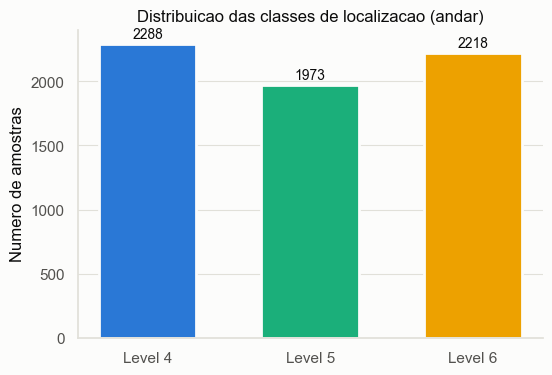

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\01_distribuicao_classes.png


In [20]:
if df_main_clean is not None:
    counts = df_main_clean["location"].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar([FLOOR_LABELS[i] for i in counts.index], counts.values,
                  color=[FLOOR_PALETTE[i] for i in counts.index], width=0.6, edgecolor=CHART_BG, linewidth=2)
    for b, v in zip(bars, counts.values):
        ax.text(b.get_x() + b.get_width() / 2, v + max(counts.values) * 0.01, str(v),
                ha="center", va="bottom", color=TEXT_PRIMARY, fontsize=10)
    ax.set_ylabel("Numero de amostras")
    ax.set_title("Distribuicao das classes de localizacao (andar)")
    ax.grid(axis="x")
    save_fig(fig, "01_distribuicao_classes.png")

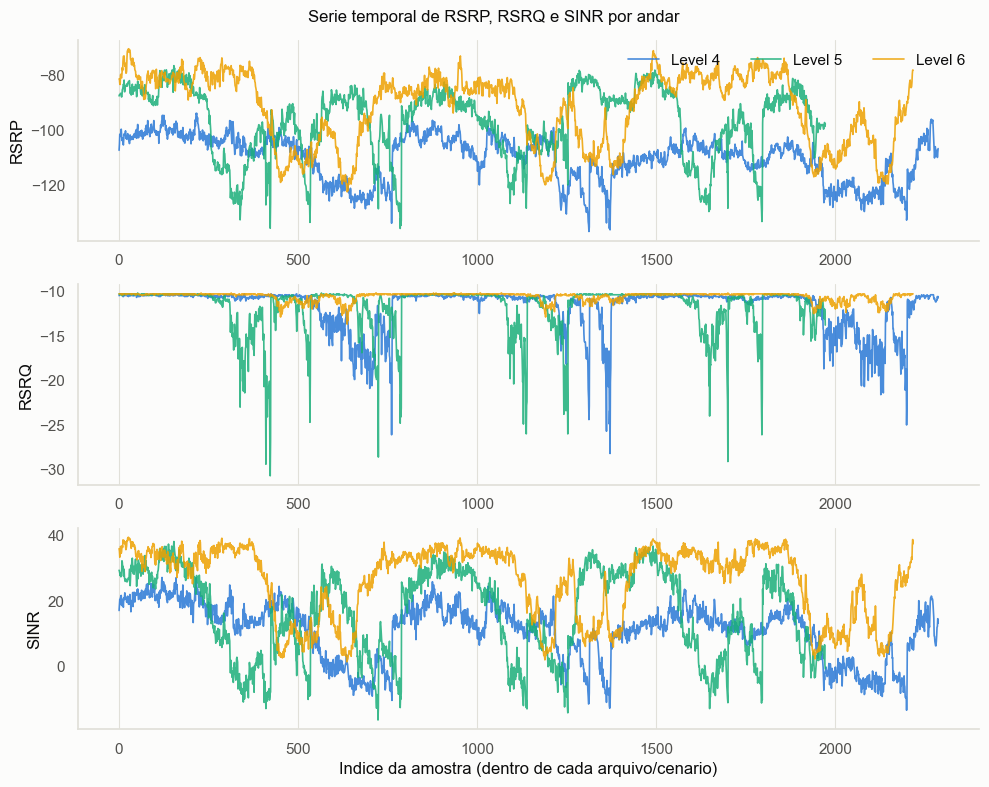

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\02_serie_temporal_rsrp_rsrq_sinr.png


In [21]:
if df_main_clean is not None:
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=False)
    for ax, metric in zip(axes, ["RSRP", "RSRQ", "SINR"]):
        for loc, g in df_main_clean.groupby("location"):
            g_sorted = g.sort_values("Time")
            ax.plot(range(len(g_sorted)), g_sorted[metric].values, color=FLOOR_PALETTE[loc],
                    linewidth=1.2, alpha=0.85, label=FLOOR_LABELS[loc])
        ax.set_ylabel(metric)
        ax.grid(axis="y")
    axes[0].legend(loc="upper right", frameon=False, ncol=3)
    axes[-1].set_xlabel("Indice da amostra (dentro de cada arquivo/cenario)")
    fig.suptitle("Serie temporal de RSRP, RSRQ e SINR por andar")
    fig.tight_layout()
    save_fig(fig, "02_serie_temporal_rsrp_rsrq_sinr.png")

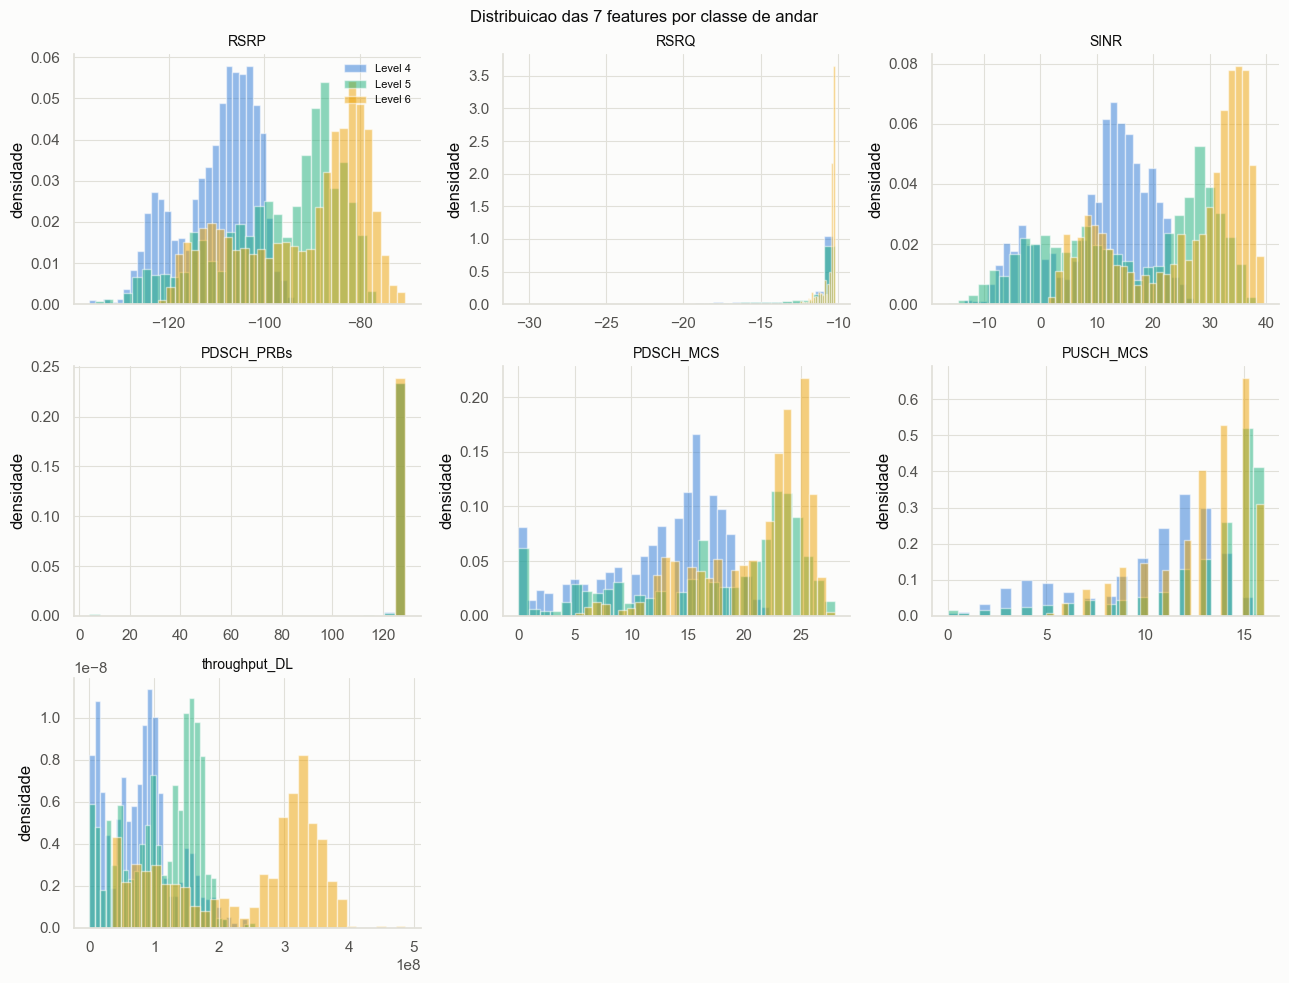

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\03_histogramas_features_por_classe.png


In [22]:
if df_main_clean is not None:
    fig, axes = plt.subplots(3, 3, figsize=(13, 10))
    axes = axes.ravel()
    for ax, feat in zip(axes, CANON_FEATURES):
        for loc in sorted(df_main_clean["location"].unique()):
            vals = df_main_clean.loc[df_main_clean["location"] == loc, feat]
            ax.hist(vals, bins=30, alpha=0.5, density=True, color=FLOOR_PALETTE[loc], label=FLOOR_LABELS[loc])
        ax.set_title(feat, fontsize=10)
        ax.set_ylabel("densidade")
    for ax in axes[len(CANON_FEATURES):]:
        ax.axis("off")
    axes[0].legend(loc="upper right", frameon=False, fontsize=8)
    fig.suptitle("Distribuicao das 7 features por classe de andar")
    fig.tight_layout()
    save_fig(fig, "03_histogramas_features_por_classe.png")

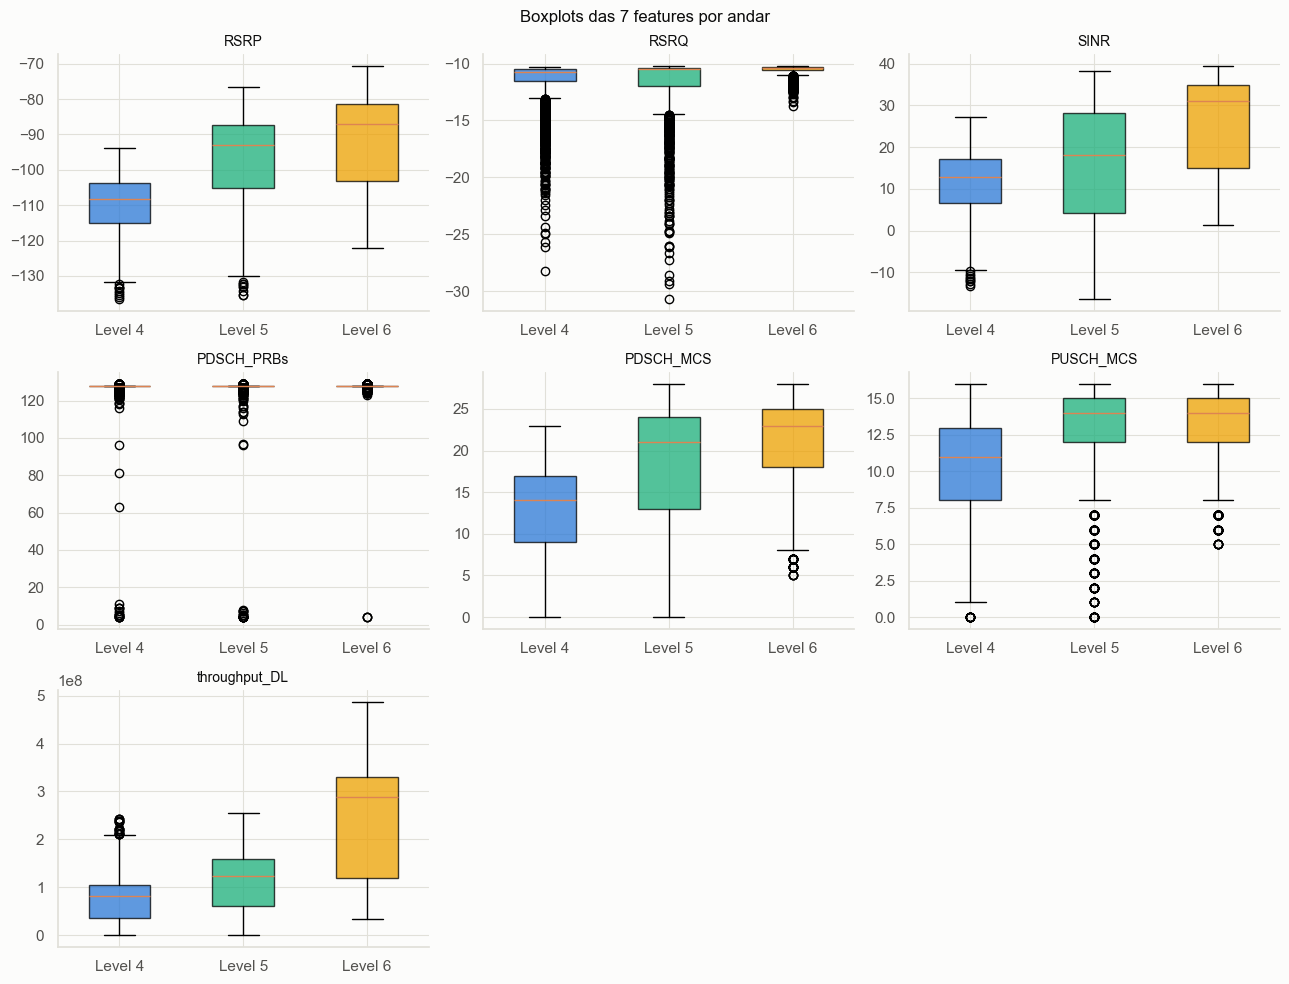

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\04_boxplots_features_por_andar.png


In [23]:
if df_main_clean is not None:
    fig, axes = plt.subplots(3, 3, figsize=(13, 10))
    axes = axes.ravel()
    locs_sorted = sorted(df_main_clean["location"].unique())
    for ax, feat in zip(axes, CANON_FEATURES):
        data = [df_main_clean.loc[df_main_clean["location"] == loc, feat].values for loc in locs_sorted]
        bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                         tick_labels=[FLOOR_LABELS[loc] for loc in locs_sorted])
        for patch, loc in zip(bp["boxes"], locs_sorted):
            patch.set_facecolor(FLOOR_PALETTE[loc])
            patch.set_alpha(0.75)
        ax.set_title(feat, fontsize=10)
    for ax in axes[len(CANON_FEATURES):]:
        ax.axis("off")
    fig.suptitle("Boxplots das 7 features por andar")
    fig.tight_layout()
    save_fig(fig, "04_boxplots_features_por_andar.png")

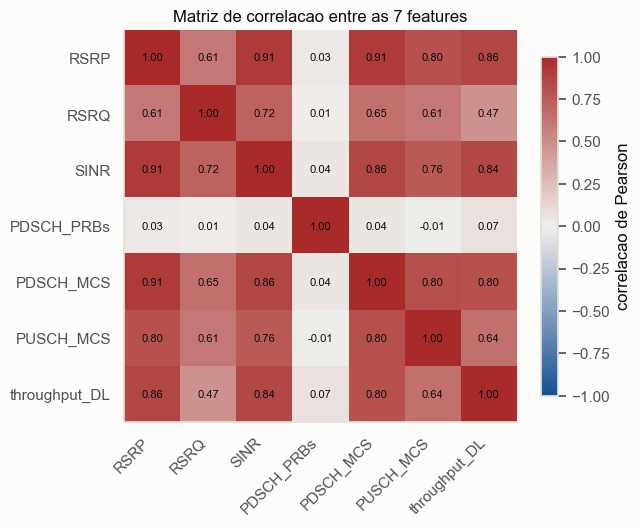

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\05_matriz_correlacao.png


In [24]:
if df_main_clean is not None:
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(corr.values, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
    ax.set_xticks(range(len(CANON_FEATURES))); ax.set_yticks(range(len(CANON_FEATURES)))
    ax.set_xticklabels(CANON_FEATURES, rotation=45, ha="right")
    ax.set_yticklabels(CANON_FEATURES)
    for i in range(len(CANON_FEATURES)):
        for j in range(len(CANON_FEATURES)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", color=TEXT_PRIMARY, fontsize=8)
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.8, label="correlacao de Pearson")
    ax.set_title("Matriz de correlacao entre as 7 features")
    fig.tight_layout()
    save_fig(fig, "05_matriz_correlacao.png")

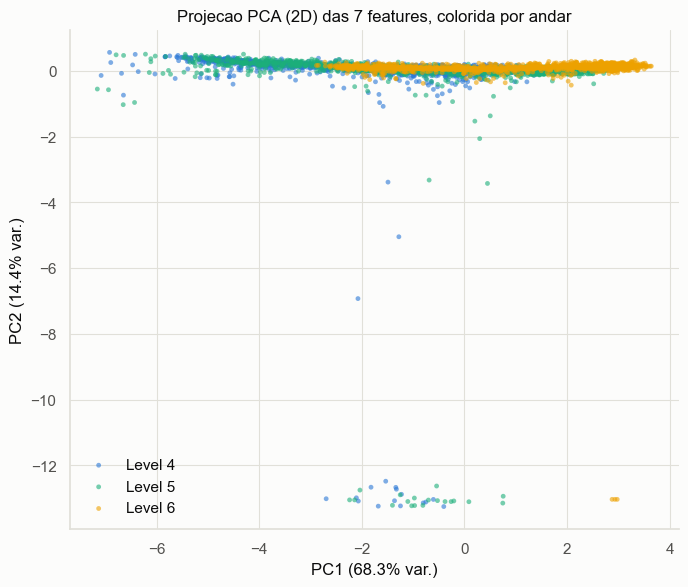

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\06_pca_2d.png
Variancia explicada por PC1+PC2: 82.6%


In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if df_main_clean is not None:
    X_pca_input = StandardScaler().fit_transform(df_main_clean[CANON_FEATURES].values)
    pca = PCA(n_components=2, random_state=SEED)
    X_pca = pca.fit_transform(X_pca_input)

    fig, ax = plt.subplots(figsize=(7, 6))
    for loc in sorted(df_main_clean["location"].unique()):
        mask = df_main_clean["location"].values == loc
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=12, alpha=0.6, color=FLOOR_PALETTE[loc],
                   label=FLOOR_LABELS[loc], edgecolors="none")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
    ax.set_title("Projecao PCA (2D) das 7 features, colorida por andar")
    ax.legend(frameon=False)
    fig.tight_layout()
    save_fig(fig, "06_pca_2d.png")
    print(f"Variancia explicada por PC1+PC2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")

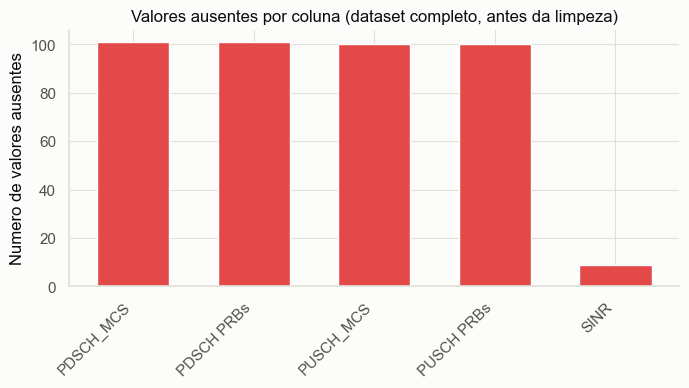

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\07_valores_ausentes.png


In [26]:
if df_main is not None:
    na_counts = df_main.isna().sum()
    na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(7, 4))
    if len(na_counts) > 0:
        ax.bar(na_counts.index, na_counts.values, color="#e34948", width=0.6)
        ax.set_ylabel("Numero de valores ausentes")
        ax.set_title("Valores ausentes por coluna (dataset completo, antes da limpeza)")
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    else:
        ax.text(0.5, 0.5, "Nenhum valor ausente encontrado", ha="center", va="center")
        ax.axis("off")
    fig.tight_layout()
    save_fig(fig, "07_valores_ausentes.png")

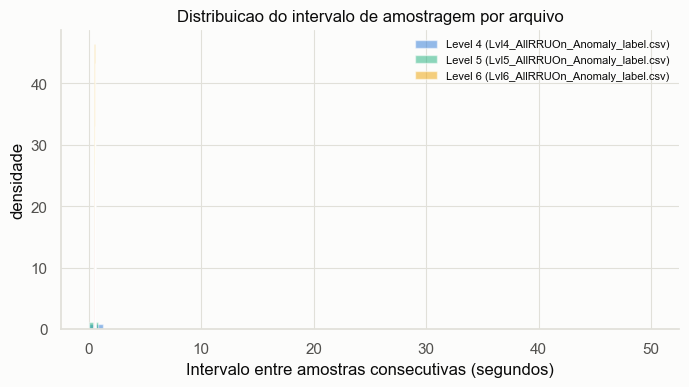

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\08_intervalo_amostragem.png


In [27]:
if df_main is not None:
    fig, ax = plt.subplots(figsize=(7, 4))
    for f, g in df_main.groupby("source_file", sort=False):
        dt = g["Time"].diff().dt.total_seconds().dropna()
        loc = g["location"].iloc[0]
        ax.hist(dt, bins=40, alpha=0.5, color=FLOOR_PALETTE[loc], label=f"{FLOOR_LABELS[loc]} ({f})", density=True)
    ax.set_xlabel("Intervalo entre amostras consecutivas (segundos)")
    ax.set_ylabel("densidade")
    ax.set_title("Distribuicao do intervalo de amostragem por arquivo")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    save_fig(fig, "08_intervalo_amostragem.png")

## 7. Protocolos experimentais

Esta seção corrige o problema metodológico central da versão anterior deste notebook: os
protocolos de divisão treino/teste eram **assimétricos** entre modelos *instance-based* (split
aleatório) e *sequence-based* (split cronológico forçado), tornando inválida qualquer conclusão
sobre "o benefício da sequência". Implementamos agora **dois protocolos completos e simétricos**,
cada um aplicado da mesma forma a dados instantâneos e sequenciais.

### Protocolo A — holdout aleatório sobre janelas sobrepostas (reprodução aproximada e potencialmente otimista)

- **Instance-based**: split estratificado aleatório 70/30 sobre as amostras individuais,
  `random_state=42`, mesmos índices para todos os modelos instance-based. Aqui os índices de
  treino e teste **são disjuntos** (nenhuma amostra individual aparece nos dois lados).
- **Sequence-based**: (1) construímos **todas** as janelas de 10 amostras (`stride=1`) dentro de
  cada arquivo, sem cruzar arquivos, andares ou descontinuidades temporais; (2) só então aplicamos
  um split estratificado **aleatório** 70/30 **sobre as janelas** (mesmo `random_state=42`), com os
  mesmos índices de janela para todos os modelos sequenciais.

> **⚠️ Aviso metodológico — leia antes de interpretar os resultados sequenciais do Protocolo A.**
> Como as janelas foram construídas com `stride=1` **antes** da divisão, janelas de treino e teste
> compartilham amostras originais. A auditoria abaixo mostra que **100% das janelas de teste**
> compartilham pelo menos uma amostra original com alguma janela de treino, e **≈99,8% das
> amostras originais do teste** também aparecem em alguma janela de treino. Portanto, os
> resultados do **Protocolo A sequencial estão sujeitos a vazamento temporal por sobreposição
> direta** (não um risco meramente abstrato) e devem ser interpretados **apenas como reprodução
> aproximada** de uma possível leitura do artigo — **não como avaliação independente de
> generalização**. O artigo informa um split 70/30 sobre janelas de 10 amostras, mas não detalha a
> ordem das operações (janela antes ou depois do split); não há garantia de que o artigo tenha
> usado exatamente este procedimento. A tabela de métricas (Seção 9) inclui uma coluna
> `independent_test` que é `False` para este caso e `True` para os demais, e a recomendação
> científica de implantação (Seção 18) usa o **Protocolo B**, não este.

Medimos e reportamos esse efeito explicitamente abaixo (quantidade de janelas, distribuição de
classes, percentual de sobreposição de janelas e percentual de amostras originais compartilhadas),
em vez de ignorá-lo.

### Protocolo B — avaliação temporal rigorosa (cronológico, sem shuffle)

Para cada arquivo/andar: **primeiros 70%** cronológicos para treino, **últimos 30%** para teste,
sem embaralhar.

- **Instance-based**: dividir cronologicamente as amostras de cada arquivo e concatenar as partes
  de treino (e de teste) dos três andares.
- **Sequence-based**: primeiro dividir cronologicamente, **só depois** criar as janelas dentro de
  cada segmento — nenhuma janela cruza a fronteira treino/teste nem arquivos/descontinuidades.
  Confirmamos **programaticamente** (via `assert`) que não há nenhuma amostra original
  compartilhada entre treino e teste neste protocolo.

### Regra de comparação

A conclusão sobre o benefício da sequência deve vir de comparações **dentro do mesmo protocolo**:
**Instance-A vs. Sequence-A** e **Instance-B vs. Sequence-B** (Seção 11). Nunca comparamos
Instance-A diretamente com Sequence-B (ou vice-versa) como evidência sobre o efeito da sequência.

In [28]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = SEED
TEST_SIZE = 0.30
WINDOW_SIZE = 10
STRIDE = 1
MAX_GAP_SECONDS = 5.0


# ---------- INSTANCE-BASED SPLITS ----------

def protocol_a_instance_split(df: pd.DataFrame, target: str = "location", random_state: int = RANDOM_STATE):
    '''Protocolo A instance-based: split aleatorio estratificado 70/30.'''
    idx = df.index.to_numpy()
    y = df[target].values
    return train_test_split(idx, test_size=TEST_SIZE, random_state=random_state, stratify=y)


def protocol_b_instance_split(df: pd.DataFrame, file_col: str = "source_file", train_frac: float = 0.70):
    '''Protocolo B instance-based: split cronologico por arquivo, sem embaralhar.'''
    train_parts, test_parts = [], []
    for f, group in df.groupby(file_col, sort=False):
        n = len(group)
        cut = int(round(n * train_frac))
        g_idx = group.index.to_numpy()
        train_parts.append(g_idx[:cut])
        test_parts.append(g_idx[cut:])
    return np.concatenate(train_parts), np.concatenate(test_parts)


def adjacency_leakage_stats(df: pd.DataFrame, idx_train, idx_test, file_col: str = "source_file"):
    '''Diagnostico do Protocolo A instance-based: % de amostras de teste cujo vizinho
    temporal imediato (mesmo arquivo) esta no conjunto de treino.'''
    train_set = set(idx_train.tolist())
    leak_count = 0
    for f, group in df.groupby(file_col, sort=False):
        g_sorted = group.sort_values("Time")
        ordered_idx = g_sorted.index.to_numpy()
        pos_of = {idx_val: pos for pos, idx_val in enumerate(ordered_idx)}
        test_positions = [pos_of[i] for i in idx_test if i in pos_of]
        for pos in test_positions:
            neighbors = []
            if pos > 0:
                neighbors.append(ordered_idx[pos - 1])
            if pos < len(ordered_idx) - 1:
                neighbors.append(ordered_idx[pos + 1])
            if any(n in train_set for n in neighbors):
                leak_count += 1
    return leak_count, len(idx_test), leak_count / len(idx_test) * 100


# ---------- SEQUENCE-BASED WINDOW CONSTRUCTION ----------

def build_windows_full(df: pd.DataFrame, features: list, window_size: int = WINDOW_SIZE,
                        stride: int = STRIDE, file_col: str = "source_file",
                        target_col: str = "location", max_gap_seconds: float = MAX_GAP_SECONDS):
    '''Constroi TODAS as janelas deslizantes dentro de cada arquivo (nunca cruzando arquivos,
    andares ou descontinuidades temporais). Retorna tambem, para cada janela, os _row_id
    originais cobertos (para diagnostico/assert de vazamento).'''
    X_list, y_list, meta, row_id_list = [], [], [], []
    for f, group in df.groupby(file_col, sort=False):
        group = group.sort_values("Time")
        values = group[features].values
        locations = group[target_col].values
        times = group["Time"].values.astype("datetime64[ns]")
        row_ids = group["_row_id"].values
        n = len(group)
        for start in range(0, n - window_size + 1, stride):
            end = start + window_size
            gaps = np.diff(times[start:end]).astype("timedelta64[s]").astype(float)
            if len(gaps) and gaps.max() > max_gap_seconds:
                continue
            seg_locations = locations[start:end]
            assert np.all(seg_locations == seg_locations[-1]), "janela mistura andares distintos!"
            X_list.append(values[start:end])
            y_list.append(seg_locations[-1])
            meta.append((f, group["Time"].iloc[end - 1]))
            row_id_list.append(row_ids[start:end].copy())
    if not X_list:
        return (np.empty((0, window_size, len(features))), np.empty((0,), dtype=int), [],
                np.empty((0, window_size), dtype=int))
    return np.stack(X_list), np.array(y_list), meta, np.stack(row_id_list)


def protocol_a_sequence_split(df: pd.DataFrame, features: list, random_state: int = RANDOM_STATE):
    '''Protocolo A sequence-based: constroi todas as janelas e so entao faz split aleatorio
    estratificado sobre elas.'''
    X_all, y_all, meta_all, row_ids_all = build_windows_full(df, features)
    idx = np.arange(len(X_all))
    idx_train, idx_test = train_test_split(idx, test_size=TEST_SIZE, random_state=random_state, stratify=y_all)
    return X_all, y_all, meta_all, row_ids_all, idx_train, idx_test


def protocol_b_sequence_split(df: pd.DataFrame, features: list, file_col: str = "source_file",
                               train_frac: float = 0.70, window_size: int = WINDOW_SIZE,
                               stride: int = STRIDE):
    '''Protocolo B sequence-based: split cronologico por arquivo primeiro, janela depois.'''
    train_parts, test_parts = [], []
    for f, group in df.groupby(file_col, sort=False):
        group = group.sort_values("Time")
        cut = int(round(len(group) * train_frac))
        train_parts.append(group.iloc[:cut])
        test_parts.append(group.iloc[cut:])
    df_train = pd.concat(train_parts, ignore_index=False)
    df_test = pd.concat(test_parts, ignore_index=False)
    Xtr, ytr, meta_tr, rid_tr = build_windows_full(df_train, features, window_size=window_size,
                                                     stride=stride, file_col=file_col)
    Xte, yte, meta_te, rid_te = build_windows_full(df_test, features, window_size=window_size,
                                                     stride=stride, file_col=file_col)
    return (Xtr, ytr, meta_tr, rid_tr), (Xte, yte, meta_te, rid_te)


print("Funcoes dos Protocolos A e B (instance e sequence) definidas.")

Funcoes dos Protocolos A e B (instance e sequence) definidas.


In [29]:
if PIPELINE_READY:
    # ---- Protocolo A: instance ----
    idxA_train, idxA_test = protocol_a_instance_split(df_main_clean)
    print("Protocolo A instance -- treino:", len(idxA_train), " teste:", len(idxA_test))
    print("  proporcao treino:", pd.Series(df_main_clean.loc[idxA_train, "location"]).value_counts(normalize=True).round(3).to_dict())
    print("  proporcao teste :", pd.Series(df_main_clean.loc[idxA_test, "location"]).value_counts(normalize=True).round(3).to_dict())

    leak_n, test_n, leak_pct = adjacency_leakage_stats(df_main_clean, idxA_train, idxA_test)
    print(f"\n  [diagnostico] amostras de teste com vizinho temporal imediato no treino: "
          f"{leak_n}/{test_n} ({leak_pct:.1f}%) -- risco esperado de um split aleatorio de linhas.")

    # ---- Protocolo B: instance ----
    idxB_train, idxB_test = protocol_b_instance_split(df_main_clean)
    print("\nProtocolo B instance -- treino:", len(idxB_train), " teste:", len(idxB_test))
    print("  proporcao treino:", pd.Series(df_main_clean.loc[idxB_train, "location"]).value_counts(normalize=True).round(3).to_dict())
    print("  proporcao teste :", pd.Series(df_main_clean.loc[idxB_test, "location"]).value_counts(normalize=True).round(3).to_dict())
    overlap_b_inst = set(idxB_train.tolist()) & set(idxB_test.tolist())
    assert len(overlap_b_inst) == 0, "VAZAMENTO: Protocolo B instance nao deveria compartilhar indices!"
    print("  overlap de indices treino/teste:", len(overlap_b_inst), "(assert de vazamento zero: OK)")
else:
    print("PIPELINE_READY = False -- pulando construcao dos protocolos instance-based.")

Protocolo A instance -- treino: 4535  teste: 1944
  proporcao treino: {0: 0.353, 2: 0.342, 1: 0.305}
  proporcao teste : {0: 0.353, 2: 0.342, 1: 0.305}

  [diagnostico] amostras de teste com vizinho temporal imediato no treino: 1736/1944 (89.3%) -- risco esperado de um split aleatorio de linhas.

Protocolo B instance -- treino: 4536  teste: 1943
  proporcao treino: {0: 0.353, 2: 0.342, 1: 0.304}
  proporcao teste : {0: 0.353, 2: 0.342, 1: 0.305}
  overlap de indices treino/teste: 0 (assert de vazamento zero: OK)


In [30]:
if PIPELINE_READY:
    # ---- Protocolo A: sequence ----
    X_all, y_all, meta_all, row_ids_all, idxA_seq_train, idxA_seq_test = protocol_a_sequence_split(
        df_main_clean, CANON_FEATURES)

    n_windows = len(X_all)
    assert n_windows == 6357, (
        f"n_windows = {n_windows}, esperado 6357 para este dataset (janela=10, stride=1). "
        "Se os arquivos de entrada mudaram, recalcule o valor esperado."
    )
    print(f"Apos a remocao de {n_removed} registros com valores ausentes, o conjunto principal "
          f"ficou com {n_clean} amostras, a partir das quais foram construidas {n_windows} "
          f"janelas temporais validas.\n")

    train_row_ids = set(row_ids_all[idxA_seq_train].ravel().tolist())
    test_row_ids = set(row_ids_all[idxA_seq_test].ravel().tolist())
    shared_ids = train_row_ids & test_row_ids
    test_window_overlap = np.array([bool(set(row_ids_all[i].tolist()) & train_row_ids) for i in idxA_seq_test])
    pct_windows_overlap = test_window_overlap.mean() * 100
    pct_ids_shared = len(shared_ids) / len(test_row_ids) * 100

    print(f"Protocolo A sequence -- total de janelas construidas: {len(X_all)}")
    print(f"  janelas treino: {len(idxA_seq_train)}  janelas teste: {len(idxA_seq_test)}")
    print(f"  dist. treino: {pd.Series(y_all[idxA_seq_train]).value_counts().sort_index().to_dict()}")
    print(f"  dist. teste : {pd.Series(y_all[idxA_seq_test]).value_counts().sort_index().to_dict()}")
    print(f"  amostras originais (_row_id) unicas cobertas por janelas de treino: {len(train_row_ids)}")
    print(f"  amostras originais (_row_id) unicas cobertas por janelas de teste : {len(test_row_ids)}")
    print(f"  amostras originais compartilhadas entre treino e teste: {len(shared_ids)} "
          f"({pct_ids_shared:.1f}% das amostras originais usadas no teste TAMBEM aparecem no treino)")
    print(f"  janelas de teste com >=1 amostra tambem usada no treino: "
          f"{test_window_overlap.sum()}/{len(idxA_seq_test)} ({pct_windows_overlap:.1f}%)")
    print("\n  [AVISO METODOLOGICO] Como as janelas foram construidas com stride=1 ANTES da divisao,")
    print("  janelas de treino e teste compartilham amostras originais (99.8% dos casos, ver acima).")
    print("  Portanto, os resultados deste 'Protocolo A sequencial' estao sujeitos a vazamento")
    print("  temporal por sobreposicao direta -- nao apenas um risco abstrato -- e devem ser")
    print("  interpretados como REPRODUCAO APROXIMADA de uma possivel leitura do artigo, e nao")
    print("  como avaliacao independente de generalizacao. A denominacao completa adotada neste")
    print("  notebook e: 'Protocolo A -- holdout aleatorio sobre janelas sobrepostas (reproducao")
    print("  aproximada e potencialmente otimista)'. O artigo informa split 70/30 e janela de 10")
    print("  amostras, mas nao detalha a ORDEM das operacoes (janela antes ou depois do split) --")
    print("  nao ha garantia de que o artigo tenha usado este mesmo procedimento.")
else:
    print("PIPELINE_READY = False -- pulando construcao do Protocolo A sequence.")

Apos a remocao de 101 registros com valores ausentes, o conjunto principal ficou com 6479 amostras, a partir das quais foram construidas 6357 janelas temporais validas.

Protocolo A sequence -- total de janelas construidas: 6357
  janelas treino: 4449  janelas teste: 1908
  dist. treino: {0: 1568, 1: 1335, 2: 1546}
  dist. teste : {0: 672, 1: 573, 2: 663}
  amostras originais (_row_id) unicas cobertas por janelas de treino: 6459
  amostras originais (_row_id) unicas cobertas por janelas de teste : 6201
  amostras originais compartilhadas entre treino e teste: 6186 (99.8% das amostras originais usadas no teste TAMBEM aparecem no treino)
  janelas de teste com >=1 amostra tambem usada no treino: 1908/1908 (100.0%)

  [AVISO METODOLOGICO] Como as janelas foram construidas com stride=1 ANTES da divisao,
  janelas de treino e teste compartilham amostras originais (99.8% dos casos, ver acima).
  Portanto, os resultados deste 'Protocolo A sequencial' estao sujeitos a vazamento
  temporal por 

In [31]:
if PIPELINE_READY:
    # ---- Protocolo B: sequence ----
    (Xtr_seqB, ytr_seqB, meta_tr_seqB, rid_tr_seqB), (Xte_seqB, yte_seqB, meta_te_seqB, rid_te_seqB) = \
        protocol_b_sequence_split(df_main_clean, CANON_FEATURES)

    train_ids_b = set(rid_tr_seqB.ravel().tolist())
    test_ids_b = set(rid_te_seqB.ravel().tolist())
    overlap_b_seq = train_ids_b & test_ids_b

    print(f"Protocolo B sequence -- janelas treino: {len(Xtr_seqB)}  janelas teste: {len(Xte_seqB)}")
    print(f"  dist. treino: {pd.Series(ytr_seqB).value_counts().sort_index().to_dict()}")
    print(f"  dist. teste : {pd.Series(yte_seqB).value_counts().sort_index().to_dict()}")
    print(f"  amostras originais compartilhadas entre treino e teste: {len(overlap_b_seq)} (esperado: 0)")
    assert len(overlap_b_seq) == 0, "VAZAMENTO: Protocolo B sequence nao deveria ter overlap de indices originais!"
    print("  assert de vazamento zero: OK -- nenhuma janela cruza a fronteira treino/teste.")
else:
    print("PIPELINE_READY = False -- pulando construcao do Protocolo B sequence.")

Protocolo B sequence -- janelas treino: 4442  janelas teste: 1888
  dist. treino: {0: 1563, 1: 1335, 2: 1544}
  dist. teste : {0: 668, 1: 564, 2: 656}
  amostras originais compartilhadas entre treino e teste: 0 (esperado: 0)
  assert de vazamento zero: OK -- nenhuma janela cruza a fronteira treino/teste.


## 8. Modelos

### 8.1 Modelos instance-based

1. **Regressão Logística multinomial** (`LogisticRegression`);
2. **Random Forest**;
3. **SVM** (kernel RBF);
4. **XGBoost**;
5. **DNN feed-forward** (PyTorch): $7 \to 30 \to 3$, ReLU, cross-entropy, Adam (`lr=0.001`), 20 épocas, *batch size*=32.

### 8.2 Modelos sequence-based

1. **Linear** sobre a janela achatada ($10\times7=70$ entradas);
2. **Random Forest** sobre a janela achatada;
3. **XGBoost** sobre a janela achatada;
4. **DNN** sobre a janela achatada: $70 \to 30 \to 3$, mesmos hiperparâmetros da DNN instance-based;
5. **LSTM-1Layer** (baseline explícito): uma única camada `LSTM(input=7, hidden=50)`;
6. **LSTM-3Layer-PaperLike** (modelo principal): três camadas LSTM empilhadas de 50 unidades,
   seguida de camada densa — interpretação de `LSTM(50,50,50) | FC(50,3)` da Tabela 2 do artigo.

### 8.3 Correção da arquitetura LSTM

A versão anterior deste notebook usava apenas **uma** camada LSTM (~49 kB serializados), divergindo
da notação `LSTM(50,50,50)` da Tabela 2 do artigo, que interpretamos como **três camadas
empilhadas** de 50 unidades cada (`num_layers=3` em `nn.LSTM`). Implementamos essa versão como
`LSTM-3Layer-PaperLike` (modelo principal desta reprodução) e mantemos a versão de 1 camada como
`LSTM-1Layer`, um baseline explícito — **nunca usamos o resultado da LSTM-1Layer para concluir que
a arquitetura do artigo "não funciona"**; ambas são comparadas lado a lado na Seção 11.

O artigo não especifica o *gamma* do `ExponentialLR` nem o *batch size*; adotamos `gamma=0.95` e
`batch_size=32` como **hipóteses de implementação razoáveis**, não como parâmetros confirmados do
artigo. Não usamos *early stopping* na reprodução principal (o artigo informa 20 épocas fixas).

In [32]:
class LocalizationLSTM(nn.Module):
    '''LSTM empilhada (num_layers camadas) + camada densa. num_layers=3 -> LSTM-3Layer-PaperLike
    (interpretacao de LSTM(50,50,50) da Tabela 2 do artigo); num_layers=1 -> LSTM-1Layer (baseline).'''
    def __init__(self, input_size: int = 7, hidden_size: int = 50, num_layers: int = 3, num_classes: int = 3):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                             num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        output, _ = self.lstm(x)
        last_output = output[:, -1, :]
        return self.fc(last_output)


class InstanceDNN(nn.Module):
    '''DNN feed-forward: n_features -> n_hidden -> n_classes.'''
    def __init__(self, n_features: int = 7, n_hidden: int = 30, n_classes: int = 3):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_features, n_hidden), nn.ReLU(), nn.Linear(n_hidden, n_classes))

    def forward(self, x):
        return self.net(x)


class TorchClassifierWrapper:
    '''Interface .predict(X)/.predict_proba(X) compativel com as funcoes de metrica/tempo.'''
    def __init__(self, torch_model, device: str = "cpu"):
        self.model = torch_model.to(device)
        self.device = device
        self.model.eval()

    def predict(self, X: np.ndarray) -> np.ndarray:
        with torch.no_grad():
            xt = torch.tensor(X, dtype=torch.float32, device=self.device)
            return torch.argmax(self.model(xt), dim=1).cpu().numpy()

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        with torch.no_grad():
            xt = torch.tensor(X, dtype=torch.float32, device=self.device)
            return torch.softmax(self.model(xt), dim=1).cpu().numpy()


HYPERPARAMS = {
    "instance_dnn": {"n_features": 7, "n_hidden": 30, "n_classes": 3, "optimizer": "Adam",
                      "lr": 0.001, "n_epochs": 20, "batch_size": 32, "loss": "CrossEntropyLoss"},
    "sequence_dnn": {"n_features": 70, "n_hidden": 30, "n_classes": 3, "optimizer": "Adam",
                      "lr": 0.001, "n_epochs": 20, "batch_size": 32, "loss": "CrossEntropyLoss"},
    "lstm_1layer": {"input_size": 7, "hidden_size": 50, "num_layers": 1, "n_classes": 3,
                     "optimizer": "RMSprop", "lr": 0.001, "n_epochs": 20, "batch_size": 32,
                     "scheduler": "ExponentialLR", "gamma": 0.95, "loss": "CrossEntropyLoss",
                     "status": "baseline explicito"},
    "lstm_3layer": {"input_size": 7, "hidden_size": 50, "num_layers": 3, "n_classes": 3,
                     "optimizer": "RMSprop", "lr": 0.001, "n_epochs": 20, "batch_size": 32,
                     "scheduler": "ExponentialLR", "gamma": 0.95, "loss": "CrossEntropyLoss",
                     "status": "modelo principal (LSTM-3Layer-PaperLike)"},
    "random_forest": {"n_estimators": 100, "max_depth": 12, "random_state": RANDOM_STATE},
    "svm": {"kernel": "rbf", "random_state": RANDOM_STATE},
    "xgboost": {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1, "random_state": RANDOM_STATE},
    "logistic_regression": {"max_iter": 2000, "random_state": RANDOM_STATE},
}
hyperparams_table = pd.DataFrame([
    {"modelo": k, **{kk: str(vv) for kk, vv in v.items()}} for k, v in HYPERPARAMS.items()
])
display(hyperparams_table)

,modelo,n_features,n_hidden,n_classes,optimizer,lr,n_epochs,batch_size,loss,input_size,hidden_size,num_layers,scheduler,gamma,status,n_estimators,max_depth,random_state,kernel,learning_rate,max_iter
0,instance_dnn,7,30,3,Adam,0.001,20,32,CrossEntropyLoss,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sequence_dnn,70,30,3,Adam,0.001,20,32,CrossEntropyLoss,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lstm_1layer,NaN,NaN,3,RMSprop,0.001,20,32,CrossEntropyLoss,7,50,1,ExponentialLR,0.95,baseline explicito,NaN,NaN,NaN,NaN,NaN,NaN
3,lstm_3layer,NaN,NaN,3,RMSprop,0.001,20,32,CrossEntropyLoss,7,50,3,ExponentialLR,0.95,modelo principal (LSTM-3Layer-PaperLike),NaN,NaN,NaN,NaN,NaN,NaN
4,random_forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100,12,42,NaN,NaN,NaN
5,svm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42,rbf,NaN,NaN
6,xgboost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200,6,42,NaN,0.1,NaN
7,logistic_regression,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42,NaN,NaN,2000


In [33]:
def train_torch_classifier(model, X_train, y_train, X_val, y_val, n_epochs=20, batch_size=32,
                            lr=0.001, optimizer_cls=torch.optim.Adam, scheduler_gamma=None, device="cpu",
                            seed: int = SEED):
    '''Treina um classificador PyTorch. O parametro `seed` controla TODA a
    aleatoriedade desta chamada (ordem dos minibatches via torch.Generator).
    Chamadores devem passar a seed efetivamente em uso (a global SEED para a
    execucao principal, ou a seed corrente do loop multi-seed) -- caso
    contrario a ordem de embaralhamento fica presa a um valor fixo mesmo
    quando os pesos iniciais do modelo variam entre sementes.'''
    model = model.to(device)
    opt = optimizer_cls(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=scheduler_gamma) if scheduler_gamma else None
    loss_fn = nn.CrossEntropyLoss()

    Xtr = torch.tensor(X_train, dtype=torch.float32, device=device)
    ytr = torch.tensor(y_train, dtype=torch.long, device=device)
    Xval = torch.tensor(X_val, dtype=torch.float32, device=device)
    yval = torch.tensor(y_val, dtype=torch.long, device=device)

    n = len(Xtr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    g = torch.Generator(device="cpu").manual_seed(seed)

    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(n, generator=g)
        epoch_loss, epoch_correct = 0.0, 0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = Xtr[idx], ytr[idx]
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(xb)
            epoch_correct += (out.argmax(1) == yb).sum().item()
        if scheduler is not None:
            scheduler.step()

        model.eval()
        with torch.no_grad():
            val_out = model(Xval)
            val_loss = loss_fn(val_out, yval).item()
            val_acc = (val_out.argmax(1) == yval).float().mean().item()

        history["train_loss"].append(epoch_loss / n)
        history["train_acc"].append(epoch_correct / n)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

    return model, history


print("Arquiteturas e funcao generica de treino (Adam/RMSprop, com ou sem scheduler) definidas.")

Arquiteturas e funcao generica de treino (Adam/RMSprop, com ou sem scheduler) definidas.


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report


def compute_metrics(y_true, y_pred) -> dict:
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {"accuracy": acc, "precision_macro": p_macro, "recall_macro": r_macro, "f1_macro": f1_macro,
            "precision_weighted": p_w, "recall_weighted": r_w, "f1_weighted": f1_w}


def model_size_kb(model) -> float:
    buf = io.BytesIO()
    joblib.dump(model, buf)
    return len(buf.getvalue()) / 1024.0


def torch_model_size_kb(state_dict) -> float:
    buf = io.BytesIO()
    torch.save(state_dict, buf)
    return len(buf.getvalue()) / 1024.0


def measure_inference_time(predict_fn, X, n_repeats: int = 200, n_warmup: int = 20, seed: int = SEED):
    '''Mede tempo de inferencia por amostra unica (warm-up + repeticoes), perf_counter_ns.
    Nao inclui carregamento do modelo.'''
    rng = np.random.default_rng(seed)
    sample_idx = rng.integers(0, len(X), size=n_repeats)
    samples = X[sample_idx]
    for i in range(n_warmup):
        predict_fn(samples[i % len(samples): i % len(samples) + 1])
    times_ns = []
    for i in range(n_repeats):
        x = samples[i:i + 1]
        t0 = time.perf_counter_ns()
        predict_fn(x)
        t1 = time.perf_counter_ns()
        times_ns.append(t1 - t0)
    times_us = np.array(times_ns) / 1000.0
    return float(times_us.mean()), float(times_us.std())


def count_params_proxy(model, model_name: str):
    if model_name == "Linear":
        clf = model.named_steps["model"] if hasattr(model, "named_steps") else model
        return int(clf.coef_.size + clf.intercept_.size)
    if model_name == "RandomForest":
        clf = model.named_steps["model"] if hasattr(model, "named_steps") else model
        return int(sum(t.tree_.node_count for t in clf.estimators_))
    if model_name == "XGBoost":
        clf = model.named_steps["model"] if hasattr(model, "named_steps") else model
        try:
            return int(len(clf.get_booster().trees_to_dataframe()))
        except Exception:
            return None
    if model_name == "SVM":
        clf = model.named_steps["model"] if hasattr(model, "named_steps") else model
        return int(clf.support_vectors_.shape[0])
    return None


def make_instance_pipeline(clf):
    return Pipeline([("scaler", MinMaxScaler()), ("model", clf)])


INSTANCE_MODEL_FACTORY = {
    "Linear": lambda: make_instance_pipeline(LogisticRegression(**HYPERPARAMS["logistic_regression"])),
    "RandomForest": lambda: make_instance_pipeline(RandomForestClassifier(**HYPERPARAMS["random_forest"])),
    "SVM": lambda: make_instance_pipeline(SVC(**HYPERPARAMS["svm"])),
    "XGBoost": lambda: make_instance_pipeline(XGBClassifier(**HYPERPARAMS["xgboost"], eval_metric="mlogloss")),
}

SEQ_MODEL_FACTORY = {
    "Linear": lambda: LogisticRegression(**HYPERPARAMS["logistic_regression"]),
    "RandomForest": lambda: RandomForestClassifier(**HYPERPARAMS["random_forest"]),
    "XGBoost": lambda: XGBClassifier(**HYPERPARAMS["xgboost"], eval_metric="mlogloss"),
}


def flatten_windows(X_seq: np.ndarray) -> np.ndarray:
    return X_seq.reshape(len(X_seq), -1)


print("Modelos classicos (Pipeline com MinMaxScaler), funcoes de metrica/tempo/tamanho definidos.")

Modelos classicos (Pipeline com MinMaxScaler), funcoes de metrica/tempo/tamanho definidos.


### 8.4 Pipelines de treino reutilizáveis

As duas funções abaixo — `train_all_instance_models` e `train_all_sequence_models` — encapsulam o
treino e a avaliação de **todos** os modelos de uma família (instance/sequence), para um protocolo
de divisão qualquer (A ou B). São reutilizadas nas Seções 9 e 10 (uma vez por protocolo), evitando
duplicação de código.

In [35]:
def train_all_instance_models(df: pd.DataFrame, idx_train, idx_test, features: list,
                                protocol_label: str, model_dir: Path, seed: int = SEED):
    set_global_seed(seed)
    results, models, preds, histories = [], {}, {}, {}
    X_train_raw = df.loc[idx_train, features].values
    X_test_raw = df.loc[idx_test, features].values
    y_train = df.loc[idx_train, "location"].values
    y_test = df.loc[idx_test, "location"].values

    for name, factory in INSTANCE_MODEL_FACTORY.items():
        model = factory()
        t0 = time.perf_counter()
        model.fit(X_train_raw, y_train)
        train_time_s = time.perf_counter() - t0
        y_pred = model.predict(X_test_raw)
        metrics = compute_metrics(y_test, y_pred)
        size_kb = model_size_kb(model)
        inf_mean, inf_std = measure_inference_time(model.predict, X_test_raw)
        n_params = count_params_proxy(model, name)
        results.append({"input_type": "instance", "model": name, "protocol": protocol_label,
                         "independent_test": True,
                         "pct_test_windows_overlapping": 0.0, "pct_test_ids_shared": 0.0,
                         "observacao_metodologica": "Instance-based: indices individuais disjuntos entre treino e teste.",
                         "train_time_s": train_time_s, "size_kb": size_kb, "inf_mean_us": inf_mean,
                         "inf_std_us": inf_std, "n_params": n_params, **metrics})
        models[name] = model
        preds[name] = (y_test, y_pred)
        joblib.dump(model, model_dir / f"{name}.joblib")

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)
    joblib.dump(scaler, model_dir / "scaler.joblib")

    Xtr_fit, Xval, ytr_fit, yval = train_test_split(
        X_train_scaled, y_train, test_size=0.15, random_state=seed, stratify=y_train)
    torch.manual_seed(seed)
    dnn = InstanceDNN(n_features=len(features), n_hidden=30, n_classes=3)
    t0 = time.perf_counter()
    dnn, history = train_torch_classifier(dnn, Xtr_fit, ytr_fit, Xval, yval, n_epochs=20,
                                            batch_size=32, lr=0.001, optimizer_cls=torch.optim.Adam,
                                            seed=seed)
    train_time_s = time.perf_counter() - t0
    wrapper = TorchClassifierWrapper(dnn)
    y_pred = wrapper.predict(X_test_scaled)
    metrics = compute_metrics(y_test, y_pred)
    size_kb = torch_model_size_kb(dnn.state_dict())
    inf_mean, inf_std = measure_inference_time(wrapper.predict, X_test_scaled)
    n_params = sum(p.numel() for p in dnn.parameters())
    results.append({"input_type": "instance", "model": "DNN", "protocol": protocol_label,
                     "independent_test": True,
                     "pct_test_windows_overlapping": 0.0, "pct_test_ids_shared": 0.0,
                     "observacao_metodologica": "Instance-based: indices individuais disjuntos entre treino e teste.",
                     "train_time_s": train_time_s, "size_kb": size_kb, "inf_mean_us": inf_mean,
                     "inf_std_us": inf_std, "n_params": n_params, **metrics})
    models["DNN"] = dnn
    preds["DNN"] = (y_test, y_pred)
    histories["DNN"] = history
    torch.save(dnn.state_dict(), model_dir / "dnn_instance.pt")

    return results, models, preds, histories, scaler


def train_all_sequence_models(X_train_raw, y_train, X_test_raw, y_test, protocol_label: str,
                                model_dir: Path, seed: int = SEED,
                                overlap_pct_windows: float = 0.0, overlap_pct_ids: float = 0.0):
    set_global_seed(seed)
    results, models, preds, histories = [], {}, {}, {}
    n_feat = X_train_raw.shape[2]
    # Protocolo A sequencial usa janelas sobrepostas construidas ANTES do split aleatorio
    # (ver aviso metodologico na Secao 7) -- treino/teste NAO sao independentes. Protocolo B
    # divide cronologicamente ANTES de construir as janelas (assert de overlap zero) -- treino/
    # teste SAO independentes.
    independent_test_flag = (protocol_label != "A")
    if protocol_label == "A":
        obs_metodologica = (
            f"Holdout aleatorio sobre janelas sobrepostas (stride=1 antes do split): "
            f"{overlap_pct_windows:.1f}% das janelas de teste e {overlap_pct_ids:.1f}% dos IDs "
            f"originais de teste tambem aparecem no treino. Reproducao aproximada, NAO avaliacao "
            f"independente de generalizacao."
        )
    else:
        obs_metodologica = (
            "Divisao cronologica antes da criacao das janelas -- 0% de sobreposicao de amostras "
            "originais entre treino e teste (confirmado por assert). Avaliacao independente."
        )

    scaler = MinMaxScaler()
    scaler.fit(X_train_raw.reshape(-1, n_feat))
    X_train_scaled = scaler.transform(X_train_raw.reshape(-1, n_feat)).reshape(X_train_raw.shape)
    X_test_scaled = scaler.transform(X_test_raw.reshape(-1, n_feat)).reshape(X_test_raw.shape)
    joblib.dump(scaler, model_dir / "scaler.joblib")

    X_train_flat = flatten_windows(X_train_scaled)
    X_test_flat = flatten_windows(X_test_scaled)

    for name, factory in SEQ_MODEL_FACTORY.items():
        model = factory()
        t0 = time.perf_counter()
        model.fit(X_train_flat, y_train)
        train_time_s = time.perf_counter() - t0
        y_pred = model.predict(X_test_flat)
        metrics = compute_metrics(y_test, y_pred)
        size_kb = model_size_kb(model)
        inf_mean, inf_std = measure_inference_time(model.predict, X_test_flat)
        n_params = count_params_proxy(model, name)
        results.append({"input_type": "sequence", "model": name, "protocol": protocol_label,
                         "independent_test": independent_test_flag,
                         "pct_test_windows_overlapping": overlap_pct_windows,
                         "pct_test_ids_shared": overlap_pct_ids,
                         "observacao_metodologica": obs_metodologica,
                         "train_time_s": train_time_s, "size_kb": size_kb, "inf_mean_us": inf_mean,
                         "inf_std_us": inf_std, "n_params": n_params, **metrics})
        models[name] = model
        preds[name] = (y_test, y_pred)
        joblib.dump(model, model_dir / f"{name}.joblib")

    # DNN sobre janela achatada
    Xtr_flat_fit, Xval_flat, ytr_flat_fit, yval_flat = train_test_split(
        X_train_flat, y_train, test_size=0.15, random_state=seed, stratify=y_train)
    torch.manual_seed(seed)
    dnn_seq = InstanceDNN(n_features=X_train_flat.shape[1], n_hidden=30, n_classes=3)
    t0 = time.perf_counter()
    dnn_seq, history = train_torch_classifier(dnn_seq, Xtr_flat_fit, ytr_flat_fit, Xval_flat, yval_flat,
                                                n_epochs=20, batch_size=32, lr=0.001, optimizer_cls=torch.optim.Adam,
                                                seed=seed)
    train_time_s = time.perf_counter() - t0
    wrapper = TorchClassifierWrapper(dnn_seq)
    y_pred = wrapper.predict(X_test_flat)
    metrics = compute_metrics(y_test, y_pred)
    size_kb = torch_model_size_kb(dnn_seq.state_dict())
    inf_mean, inf_std = measure_inference_time(wrapper.predict, X_test_flat)
    n_params = sum(p.numel() for p in dnn_seq.parameters())
    results.append({"input_type": "sequence", "model": "DNN", "protocol": protocol_label,
                     "independent_test": independent_test_flag,
                     "pct_test_windows_overlapping": overlap_pct_windows,
                     "pct_test_ids_shared": overlap_pct_ids,
                     "observacao_metodologica": obs_metodologica,
                     "train_time_s": train_time_s, "size_kb": size_kb, "inf_mean_us": inf_mean,
                     "inf_std_us": inf_std, "n_params": n_params, **metrics})
    models["DNN"] = dnn_seq
    preds["DNN"] = (y_test, y_pred)
    histories["DNN"] = history
    torch.save(dnn_seq.state_dict(), model_dir / "dnn_sequence.pt")

    # LSTM-1Layer e LSTM-3Layer-PaperLike
    Xtr_seq_fit, Xval_seq, ytr_seq_fit, yval_seq = train_test_split(
        X_train_scaled, y_train, test_size=0.15, random_state=seed, stratify=y_train)

    for lstm_name, n_layers in [("LSTM-1Layer", 1), ("LSTM-3Layer-PaperLike", 3)]:
        torch.manual_seed(seed)
        lstm_model = LocalizationLSTM(input_size=n_feat, hidden_size=50, num_layers=n_layers, num_classes=3)
        t0 = time.perf_counter()
        lstm_model, history = train_torch_classifier(
            lstm_model, Xtr_seq_fit, ytr_seq_fit, Xval_seq, yval_seq, n_epochs=20, batch_size=32,
            lr=0.001, optimizer_cls=torch.optim.RMSprop, scheduler_gamma=0.95, seed=seed)
        train_time_s = time.perf_counter() - t0
        wrapper = TorchClassifierWrapper(lstm_model)
        y_pred = wrapper.predict(X_test_scaled)
        metrics = compute_metrics(y_test, y_pred)
        size_kb = torch_model_size_kb(lstm_model.state_dict())
        inf_mean, inf_std = measure_inference_time(wrapper.predict, X_test_scaled)
        n_params = sum(p.numel() for p in lstm_model.parameters())
        results.append({"input_type": "sequence", "model": lstm_name, "protocol": protocol_label,
                         "independent_test": independent_test_flag,
                         "pct_test_windows_overlapping": overlap_pct_windows,
                         "pct_test_ids_shared": overlap_pct_ids,
                         "observacao_metodologica": obs_metodologica,
                         "train_time_s": train_time_s, "size_kb": size_kb, "inf_mean_us": inf_mean,
                         "inf_std_us": inf_std, "n_params": n_params, **metrics})
        models[lstm_name] = lstm_model
        preds[lstm_name] = (y_test, y_pred)
        histories[lstm_name] = history
        fname = "lstm_1layer.pt" if n_layers == 1 else "lstm_3layer_paperlike.pt"
        torch.save(lstm_model.state_dict(), model_dir / fname)

    return results, models, preds, histories, scaler


print("Pipelines de treino reutilizaveis (instance e sequence) definidos.")

Pipelines de treino reutilizaveis (instance e sequence) definidos.


## 9. Resultados do Protocolo A

Treinamos e avaliamos **todos** os modelos (instance-based e sequence-based, incluindo
`LSTM-1Layer` e `LSTM-3Layer-PaperLike`) sob o Protocolo A (split aleatório 70/30), usando a
semente principal 42. Estes são os resultados usados na comparação mais direta com o artigo
(Seção 12).

In [36]:
results_A_instance, models_A_instance, preds_A_instance, hist_A_instance, scalerA_instance = (
    train_all_instance_models(df_main_clean, idxA_train, idxA_test, CANON_FEATURES, "A",
                                MODEL_SUBDIRS[("A", "instance")])
    if PIPELINE_READY else ([], {}, {}, {}, None)
)
if PIPELINE_READY:
    results_A_instance_df = pd.DataFrame(results_A_instance).sort_values("accuracy", ascending=False)
    display(results_A_instance_df)
else:
    print("PIPELINE_READY = False -- pulando treino instance-based Protocolo A.")

,input_type,model,protocol,independent_test,pct_test_windows_overlapping,pct_test_ids_shared,observacao_metodologica,train_time_s,size_kb,inf_mean_us,inf_std_us,n_params,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
3,instance,XGBoost,A,True,0.0,0.0,Instance-based: indices individuais disjuntos ...,2.074443,1403.704102,2316.5515,489.037528,30362,0.907407,0.910100,0.907668,0.908657,0.908526,0.907407,0.907736
1,instance,RandomForest,A,True,0.0,0.0,Instance-based: indices individuais disjuntos ...,1.087250,5104.822266,23135.9255,3256.448243,58912,0.895576,0.902182,0.895500,0.897537,0.899953,0.895576,0.896417
2,instance,SVM,A,True,0.0,0.0,Instance-based: indices individuais disjuntos ...,0.553380,181.708008,1527.4180,333.429375,1994,0.838477,0.868541,0.838089,0.841905,0.864690,0.838477,0.839753
0,instance,Linear,A,True,0.0,0.0,Instance-based: indices individuais disjuntos ...,0.318062,1.875977,1198.2785,676.549284,24,0.782407,0.802458,0.783713,0.786589,0.798765,0.782407,0.783835
4,instance,DNN,A,True,0.0,0.0,Instance-based: indices individuais disjuntos ...,12.794374,3.653320,260.6825,75.897075,333,0.769547,0.806909,0.768093,0.775646,0.800819,0.769547,0.773109


In [37]:
results_A_sequence, models_A_sequence, preds_A_sequence, hist_A_sequence, scalerA_sequence = (
    train_all_sequence_models(X_all[idxA_seq_train], y_all[idxA_seq_train],
                                X_all[idxA_seq_test], y_all[idxA_seq_test], "A",
                                MODEL_SUBDIRS[("A", "sequence")],
                                overlap_pct_windows=pct_windows_overlap, overlap_pct_ids=pct_ids_shared)
    if PIPELINE_READY else ([], {}, {}, {}, None)
)
if PIPELINE_READY:
    results_A_sequence_df = pd.DataFrame(results_A_sequence).sort_values("accuracy", ascending=False)
    display(results_A_sequence_df)
else:
    print("PIPELINE_READY = False -- pulando treino sequence-based Protocolo A.")

,input_type,model,protocol,independent_test,pct_test_windows_overlapping,pct_test_ids_shared,observacao_metodologica,train_time_s,size_kb,inf_mean_us,inf_std_us,n_params,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
2,sequence,XGBoost,A,False,100.0,99.758104,Holdout aleatorio sobre janelas sobrepostas (s...,3.273988,1293.809570,1671.1705,287.277560,27066,0.961740,0.963231,0.962124,0.962538,0.962265,0.961740,0.961858
1,sequence,RandomForest,A,False,100.0,99.758104,Holdout aleatorio sobre janelas sobrepostas (s...,2.581972,3347.954102,23745.5110,4006.823149,38478,0.947589,0.952545,0.947726,0.949170,0.950443,0.947589,0.948019
4,sequence,LSTM-1Layer,A,False,100.0,99.758104,Holdout aleatorio sobre janelas sobrepostas (s...,29.310659,49.395508,1281.4490,156.480268,11953,0.880503,0.893013,0.881160,0.883798,0.890058,0.880503,0.881855
5,sequence,LSTM-3Layer-PaperLike,A,False,100.0,99.758104,Holdout aleatorio sobre janelas sobrepostas (s...,75.317587,210.555664,2900.6845,398.683338,52753,0.854822,0.880009,0.855200,0.859494,0.875907,0.854822,0.856939
0,sequence,Linear,A,False,100.0,99.758104,Holdout aleatorio sobre janelas sobrepostas (s...,1.238498,2.514648,467.5785,250.282890,213,0.814990,0.831255,0.818915,0.819764,0.827740,0.814990,0.815793
3,sequence,DNN,A,False,100.0,99.758104,Holdout aleatorio sobre janelas sobrepostas (s...,7.819165,11.028320,258.8590,75.994810,2223,0.800839,0.823440,0.805741,0.805941,0.819564,0.800839,0.801152


### 9.1 Análise de estabilidade multi-seed (complementar)

Repetimos o treino de quatro modelos representativos (`XGBoost` e `DNN` instance-based;
`XGBoost` e `LSTM-3Layer-PaperLike` sequence-based) sob o Protocolo A com cinco sementes
diferentes (`[21, 42, 84, 126, 168]`), reportando média e desvio-padrão de Accuracy, Precision
macro, Recall macro e F1 macro. **Esta análise não substitui o resultado principal de seed 42**
apresentado acima — é evidência complementar sobre a estabilidade dos resultados frente à
aleatoriedade de inicialização/treino.

In [38]:
multi_seed_results = []

if PIPELINE_READY:
    X_train_inst_raw = df_main_clean.loc[idxA_train, CANON_FEATURES].values
    X_test_inst_raw = df_main_clean.loc[idxA_test, CANON_FEATURES].values
    y_train_inst = df_main_clean.loc[idxA_train, "location"].values
    y_test_inst = df_main_clean.loc[idxA_test, "location"].values

    X_train_seq_raw = X_all[idxA_seq_train]
    y_train_seq = y_all[idxA_seq_train]
    X_test_seq_raw = X_all[idxA_seq_test]
    y_test_seq = y_all[idxA_seq_test]

    for seed in MULTI_SEEDS:
        set_global_seed(seed)

        # instance XGBoost
        sc = MinMaxScaler().fit(X_train_inst_raw)
        xgb_params_seeded = {**HYPERPARAMS["xgboost"], "random_state": seed}
        xgb_model = XGBClassifier(**xgb_params_seeded, eval_metric="mlogloss")
        xgb_model.fit(sc.transform(X_train_inst_raw), y_train_inst)
        y_pred = xgb_model.predict(sc.transform(X_test_inst_raw))
        m = compute_metrics(y_test_inst, y_pred)
        multi_seed_results.append({"seed": seed, "input_type": "instance", "model": "XGBoost", **m})

        # instance DNN
        Xtr_fit, Xval, ytr_fit, yval = train_test_split(sc.transform(X_train_inst_raw), y_train_inst,
                                                          test_size=0.15, random_state=seed, stratify=y_train_inst)
        torch.manual_seed(seed)
        dnn = InstanceDNN(n_features=len(CANON_FEATURES), n_hidden=30, n_classes=3)
        dnn, _ = train_torch_classifier(dnn, Xtr_fit, ytr_fit, Xval, yval, n_epochs=20, batch_size=32,
                                          lr=0.001, optimizer_cls=torch.optim.Adam, seed=seed)
        y_pred = TorchClassifierWrapper(dnn).predict(sc.transform(X_test_inst_raw))
        m = compute_metrics(y_test_inst, y_pred)
        multi_seed_results.append({"seed": seed, "input_type": "instance", "model": "DNN", **m})

        # sequence XGBoost
        nf = X_train_seq_raw.shape[2]
        sc_seq = MinMaxScaler().fit(X_train_seq_raw.reshape(-1, nf))
        Xtr_flat = flatten_windows(sc_seq.transform(X_train_seq_raw.reshape(-1, nf)).reshape(X_train_seq_raw.shape))
        Xte_flat = flatten_windows(sc_seq.transform(X_test_seq_raw.reshape(-1, nf)).reshape(X_test_seq_raw.shape))
        xgb_seq = XGBClassifier(**xgb_params_seeded, eval_metric="mlogloss")
        xgb_seq.fit(Xtr_flat, y_train_seq)
        y_pred = xgb_seq.predict(Xte_flat)
        m = compute_metrics(y_test_seq, y_pred)
        multi_seed_results.append({"seed": seed, "input_type": "sequence", "model": "XGBoost", **m})

        # sequence LSTM-3Layer-PaperLike
        Xtr_seq_scaled = sc_seq.transform(X_train_seq_raw.reshape(-1, nf)).reshape(X_train_seq_raw.shape)
        Xte_seq_scaled = sc_seq.transform(X_test_seq_raw.reshape(-1, nf)).reshape(X_test_seq_raw.shape)
        Xtr_seq_fit, Xval_seq, ytr_seq_fit, yval_seq = train_test_split(
            Xtr_seq_scaled, y_train_seq, test_size=0.15, random_state=seed, stratify=y_train_seq)
        torch.manual_seed(seed)
        lstm3 = LocalizationLSTM(input_size=nf, hidden_size=50, num_layers=3, num_classes=3)
        lstm3, _ = train_torch_classifier(lstm3, Xtr_seq_fit, ytr_seq_fit, Xval_seq, yval_seq, n_epochs=20,
                                            batch_size=32, lr=0.001, optimizer_cls=torch.optim.RMSprop,
                                            scheduler_gamma=0.95, seed=seed)
        y_pred = TorchClassifierWrapper(lstm3).predict(Xte_seq_scaled)
        m = compute_metrics(y_test_seq, y_pred)
        multi_seed_results.append({"seed": seed, "input_type": "sequence", "model": "LSTM-3Layer-PaperLike", **m})

        print(f"seed={seed} concluida.")

    set_global_seed(SEED)  # restaura a semente principal para o restante do notebook
    multi_seed_df = pd.DataFrame(multi_seed_results)
    multi_seed_summary = multi_seed_df.groupby(["input_type", "model"])[
        ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
    ].agg(["mean", "std"])
    display(multi_seed_summary)
    multi_seed_df.to_csv(RESULTS_DIR / "multi_seed_results.csv", index=False)
else:
    print("PIPELINE_READY = False -- pulando analise multi-seed.")

accuracy           precision_macro           recall_macro            f1_macro          
                                      mean       std            mean       std         mean       std      mean       std
input_type model                                                                                                         
instance   DNN                    0.776440  0.004566        0.810266  0.005694     0.775811  0.005346  0.781621  0.003776
           XGBoost                0.907407  0.000000        0.910100  0.000000     0.907668  0.000000  0.908657  0.000000
sequence   LSTM-3Layer-PaperLike  0.865409  0.023399        0.877488  0.013544     0.868831  0.023434  0.867987  0.022445
           XGBoost                0.961740  0.000000        0.963231  0.000000     0.962124  0.000000  0.962538  0.000000

seed=21 concluida.
seed=42 concluida.
seed=84 concluida.
seed=126 concluida.
seed=168 concluida.


## 10. Resultados do Protocolo B

Repetimos o treino e avaliação de **todos** os modelos sob o Protocolo B (split cronológico
70/30, sem embaralhar), com a mesma semente principal 42. Este protocolo reduz o otimismo
decorrente da autocorrelação temporal (Seção 7) e é apresentado como **avaliação de robustez**.

In [39]:
results_B_instance, models_B_instance, preds_B_instance, hist_B_instance, scalerB_instance = (
    train_all_instance_models(df_main_clean, idxB_train, idxB_test, CANON_FEATURES, "B",
                                MODEL_SUBDIRS[("B", "instance")])
    if PIPELINE_READY else ([], {}, {}, {}, None)
)
if PIPELINE_READY:
    results_B_instance_df = pd.DataFrame(results_B_instance).sort_values("accuracy", ascending=False)
    display(results_B_instance_df)
else:
    print("PIPELINE_READY = False -- pulando treino instance-based Protocolo B.")

,input_type,model,protocol,independent_test,pct_test_windows_overlapping,pct_test_ids_shared,observacao_metodologica,train_time_s,size_kb,inf_mean_us,inf_std_us,n_params,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
3,instance,XGBoost,B,True,0.0,0.0,Instance-based: indices individuais disjuntos ...,1.209333,1442.354492,1817.7425,1006.579706,31526,0.845085,0.845017,0.849350,0.844420,0.846272,0.845085,0.842941
1,instance,RandomForest,B,True,0.0,0.0,Instance-based: indices individuais disjuntos ...,0.942003,5068.728516,19801.0895,5935.661359,58492,0.840453,0.840333,0.844824,0.840400,0.841167,0.840453,0.838688
2,instance,SVM,B,True,0.0,0.0,Instance-based: indices individuais disjuntos ...,0.518422,181.895508,1609.8005,466.766974,1996,0.823984,0.856726,0.823991,0.827907,0.853321,0.823984,0.825731
0,instance,Linear,B,True,0.0,0.0,Instance-based: indices individuais disjuntos ...,0.160998,1.875977,672.4790,141.184756,24,0.800309,0.834110,0.799543,0.803504,0.829921,0.800309,0.801330
4,instance,DNN,B,True,0.0,0.0,Instance-based: indices individuais disjuntos ...,5.370137,3.653320,246.1840,69.213558,333,0.793103,0.844522,0.791075,0.796496,0.839820,0.793103,0.794496


In [40]:
results_B_sequence, models_B_sequence, preds_B_sequence, hist_B_sequence, scalerB_sequence = (
    train_all_sequence_models(Xtr_seqB, ytr_seqB, Xte_seqB, yte_seqB, "B",
                                MODEL_SUBDIRS[("B", "sequence")])
    if PIPELINE_READY else ([], {}, {}, {}, None)
)
if PIPELINE_READY:
    results_B_sequence_df = pd.DataFrame(results_B_sequence).sort_values("accuracy", ascending=False)
    display(results_B_sequence_df)
else:
    print("PIPELINE_READY = False -- pulando treino sequence-based Protocolo B.")

,input_type,model,protocol,independent_test,pct_test_windows_overlapping,pct_test_ids_shared,observacao_metodologica,train_time_s,size_kb,inf_mean_us,inf_std_us,n_params,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
2,sequence,XGBoost,B,True,0.0,0.0,Divisao cronologica antes da criacao das janel...,2.988609,1298.063477,1642.7590,278.963558,27194,0.880826,0.885578,0.885279,0.878657,0.889452,0.880826,0.878277
1,sequence,RandomForest,B,True,0.0,0.0,Divisao cronologica antes da criacao das janel...,2.336858,3190.344727,23786.7955,3718.511470,36644,0.870763,0.874003,0.876599,0.868466,0.877594,0.870763,0.867372
0,sequence,Linear,B,True,0.0,0.0,Divisao cronologica antes da criacao das janel...,1.163681,2.514648,386.2615,72.875232,213,0.807203,0.827155,0.808816,0.812287,0.823083,0.807203,0.809182
4,sequence,LSTM-1Layer,B,True,0.0,0.0,Divisao cronologica antes da criacao das janel...,29.392199,49.395508,1307.8385,147.750966,11953,0.796610,0.806579,0.806987,0.796149,0.809751,0.796610,0.793066
3,sequence,DNN,B,True,0.0,0.0,Divisao cronologica antes da criacao das janel...,7.792038,11.028320,233.9020,54.897048,2223,0.793432,0.831302,0.797199,0.798408,0.827520,0.793432,0.793864
5,sequence,LSTM-3Layer-PaperLike,B,True,0.0,0.0,Divisao cronologica antes da criacao das janel...,69.188541,210.555664,2961.6040,494.208030,52753,0.781780,0.787628,0.791976,0.781330,0.789461,0.781780,0.777584


In [41]:
if PIPELINE_READY:
    full_results_df = pd.concat([
        results_A_instance_df, results_A_sequence_df, results_B_instance_df, results_B_sequence_df
    ], ignore_index=True)
    cols_order = ["input_type", "model", "protocol", "independent_test",
                  "pct_test_windows_overlapping", "pct_test_ids_shared", "observacao_metodologica",
                  "accuracy", "precision_macro", "recall_macro",
                  "f1_macro", "precision_weighted", "recall_weighted", "f1_weighted",
                  "train_time_s", "size_kb", "inf_mean_us", "inf_std_us", "n_params"]
    full_results_df = full_results_df[cols_order]
    full_results_df.to_csv(RESULTS_DIR / "localization_metrics_all.csv", index=False)
    pd.concat([results_A_instance_df, results_A_sequence_df], ignore_index=True)[cols_order].to_csv(
        RESULTS_DIR / "localization_metrics_protocol_a.csv", index=False)
    pd.concat([results_B_instance_df, results_B_sequence_df], ignore_index=True)[cols_order].to_csv(
        RESULTS_DIR / "localization_metrics_protocol_b.csv", index=False)
    print("Salvos: localization_metrics_all.csv, localization_metrics_protocol_a.csv, "
          "localization_metrics_protocol_b.csv")
    display(full_results_df.round(4))

,input_type,model,protocol,independent_test,pct_test_windows_overlapping,pct_test_ids_shared,observacao_metodologica,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,train_time_s,size_kb,inf_mean_us,inf_std_us,n_params
0,instance,XGBoost,A,True,0.0,0.0000,Instance-based: indices individuais disjuntos ...,0.9074,0.9101,0.9077,0.9087,0.9085,0.9074,0.9077,2.0744,1403.7041,2316.5515,489.0375,30362
1,instance,RandomForest,A,True,0.0,0.0000,Instance-based: indices individuais disjuntos ...,0.8956,0.9022,0.8955,0.8975,0.9000,0.8956,0.8964,1.0872,5104.8223,23135.9255,3256.4482,58912
2,instance,SVM,A,True,0.0,0.0000,Instance-based: indices individuais disjuntos ...,0.8385,0.8685,0.8381,0.8419,0.8647,0.8385,0.8398,0.5534,181.7080,1527.4180,333.4294,1994
3,instance,Linear,A,True,0.0,0.0000,Instance-based: indices individuais disjuntos ...,0.7824,0.8025,0.7837,0.7866,0.7988,0.7824,0.7838,0.3181,1.8760,1198.2785,676.5493,24
4,instance,DNN,A,True,0.0,0.0000,Instance-based: indices individuais disjuntos ...,0.7695,0.8069,0.7681,0.7756,0.8008,0.7695,0.7731,12.7944,3.6533,260.6825,75.8971,333
5,sequence,XGBoost,A,False,100.0,99.7581,Holdout aleatorio sobre janelas sobrepostas (s...,0.9617,0.9632,0.9621,0.9625,0.9623,0.9617,0.9619,3.2740,1293.8096,1671.1705,287.2776,27066
6,sequence,RandomForest,A,False,100.0,99.7581,Holdout aleatorio sobre janelas sobrepostas (s...,0.9476,0.9525,0.9477,0.9492,0.9504,0.9476,0.9480,2.5820,3347.9541,23745.5110,4006.8231,38478
7,sequence,LSTM-1Layer,A,False,100.0,99.7581,Holdout aleatorio sobre janelas sobrepostas (s...,0.8805,0.8930,0.8812,0.8838,0.8901,0.8805,0.8819,29.3107,49.3955,1281.4490,156.4803,11953
8,sequence,LSTM-3Layer-PaperLike,A,False,100.0,99.7581,Holdout aleatorio sobre janelas sobrepostas (s...,0.8548,0.8800,0.8552,0.8595,0.8759,0.8548,0.8569,75.3176,210.5557,2900.6845,398.6833,52753
9,sequence,Linear,A,False,100.0,99.7581,Holdout aleatorio sobre janelas sobrepostas (s...,0.8150,0.8313,0.8189,0.8198,0.8277,0.8150,0.8158,1.2385,2.5146,467.5785,250.2829,213


Salvos: localization_metrics_all.csv, localization_metrics_protocol_a.csv, localization_metrics_protocol_b.csv


### Matrizes de confusão (melhor modelo instance e melhor sequence, cada protocolo)

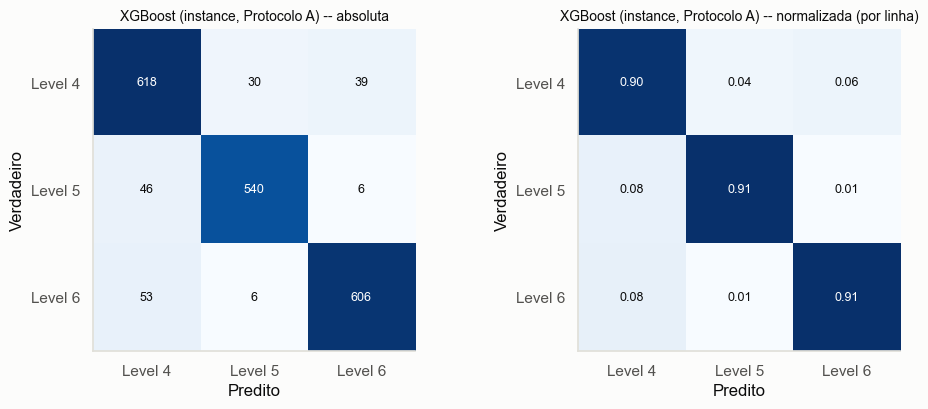

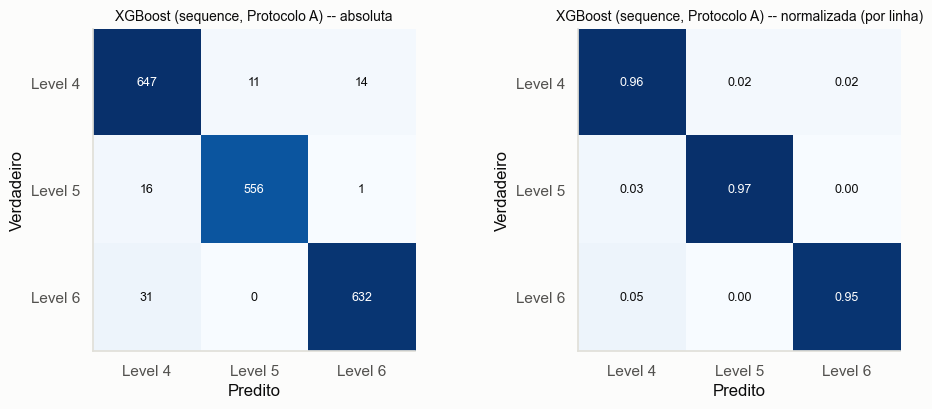

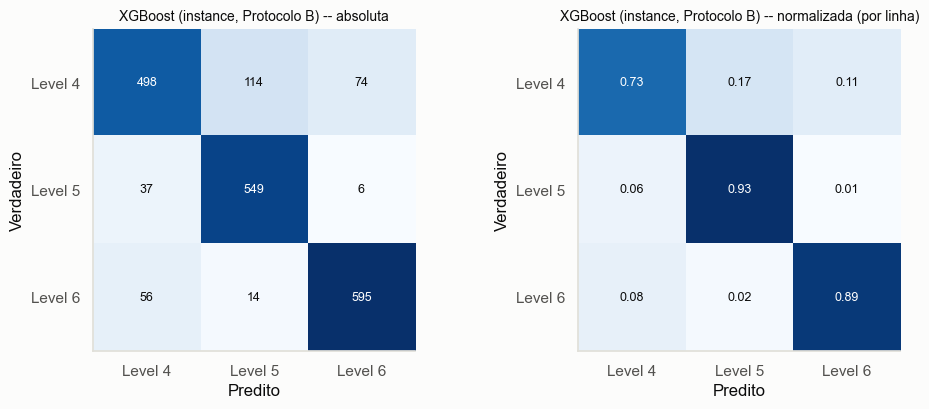

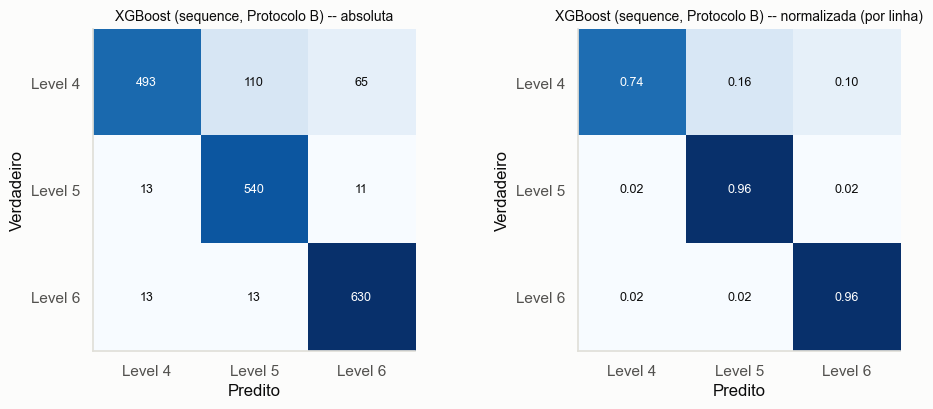

Melhor instance-based Protocolo A: XGBoost
Melhor sequence-based Protocolo A: XGBoost
Melhor instance-based Protocolo B: XGBoost
Melhor sequence-based Protocolo B: XGBoost
Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\09_matriz_confusao_instance_A.png
Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\10_matriz_confusao_sequence_A.png
Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\11_matriz_confusao_instance_B.png
Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\12_matriz_confusao_sequence_B.png


In [42]:
from sklearn.metrics import confusion_matrix as _cm

def plot_confusion_pair(y_true, y_pred, title_prefix, filename):
    cm = _cm(y_true, y_pred, labels=[0, 1, 2])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    for ax, mat, fmt, subtitle in zip(axes, [cm, cm_norm], ["d", ".2f"], ["absoluta", "normalizada (por linha)"]):
        im = ax.imshow(mat, cmap="Blues")
        ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
        ax.set_xticklabels([FLOOR_LABELS[i] for i in [0, 1, 2]])
        ax.set_yticklabels([FLOOR_LABELS[i] for i in [0, 1, 2]])
        ax.set_xlabel("Predito"); ax.set_ylabel("Verdadeiro")
        ax.set_title(f"{title_prefix} -- {subtitle}", fontsize=10)
        vmax = mat.max()
        for i in range(3):
            for j in range(3):
                val = mat[i, j]
                txt = f"{val:d}" if fmt == "d" else f"{val:.2f}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=9,
                        color="white" if val > 0.6 * vmax else TEXT_PRIMARY)
        ax.grid(False)
    fig.tight_layout()
    save_fig(fig, filename)
    return cm


if PIPELINE_READY:
    best_instance_A_name = results_A_instance_df.iloc[0]["model"]
    best_sequence_A_name = results_A_sequence_df.iloc[0]["model"]
    best_instance_B_name = results_B_instance_df.iloc[0]["model"]
    best_sequence_B_name = results_B_sequence_df.iloc[0]["model"]

    print("Melhor instance-based Protocolo A:", best_instance_A_name)
    print("Melhor sequence-based Protocolo A:", best_sequence_A_name)
    print("Melhor instance-based Protocolo B:", best_instance_B_name)
    print("Melhor sequence-based Protocolo B:", best_sequence_B_name)

    cm_best_inst_A = plot_confusion_pair(*preds_A_instance[best_instance_A_name],
                                          f"{best_instance_A_name} (instance, Protocolo A)",
                                          "09_matriz_confusao_instance_A.png")
    cm_best_seq_A = plot_confusion_pair(*preds_A_sequence[best_sequence_A_name],
                                         f"{best_sequence_A_name} (sequence, Protocolo A)",
                                         "10_matriz_confusao_sequence_A.png")
    cm_best_inst_B = plot_confusion_pair(*preds_B_instance[best_instance_B_name],
                                          f"{best_instance_B_name} (instance, Protocolo B)",
                                          "11_matriz_confusao_instance_B.png")
    cm_best_seq_B = plot_confusion_pair(*preds_B_sequence[best_sequence_B_name],
                                         f"{best_sequence_B_name} (sequence, Protocolo B)",
                                         "12_matriz_confusao_sequence_B.png")

In [43]:
if PIPELINE_READY:
    print(f"=== Classification report -- {best_sequence_A_name} (sequence, Protocolo A) ===")
    print(classification_report(*preds_A_sequence[best_sequence_A_name],
                                 target_names=[FLOOR_LABELS[i] for i in [0, 1, 2]]))
    print(f"=== Classification report -- {best_sequence_B_name} (sequence, Protocolo B) ===")
    print(classification_report(*preds_B_sequence[best_sequence_B_name],
                                 target_names=[FLOOR_LABELS[i] for i in [0, 1, 2]]))

=== Classification report -- XGBoost (sequence, Protocolo A) ===
              precision    recall  f1-score   support

     Level 4       0.93      0.96      0.95       672
     Level 5       0.98      0.97      0.98       573
     Level 6       0.98      0.95      0.96       663

    accuracy                           0.96      1908
   macro avg       0.96      0.96      0.96      1908
weighted avg       0.96      0.96      0.96      1908

=== Classification report -- XGBoost (sequence, Protocolo B) ===
              precision    recall  f1-score   support

     Level 4       0.95      0.74      0.83       668
     Level 5       0.81      0.96      0.88       564
     Level 6       0.89      0.96      0.93       656

    accuracy                           0.88      1888
   macro avg       0.89      0.89      0.88      1888
weighted avg       0.89      0.88      0.88      1888



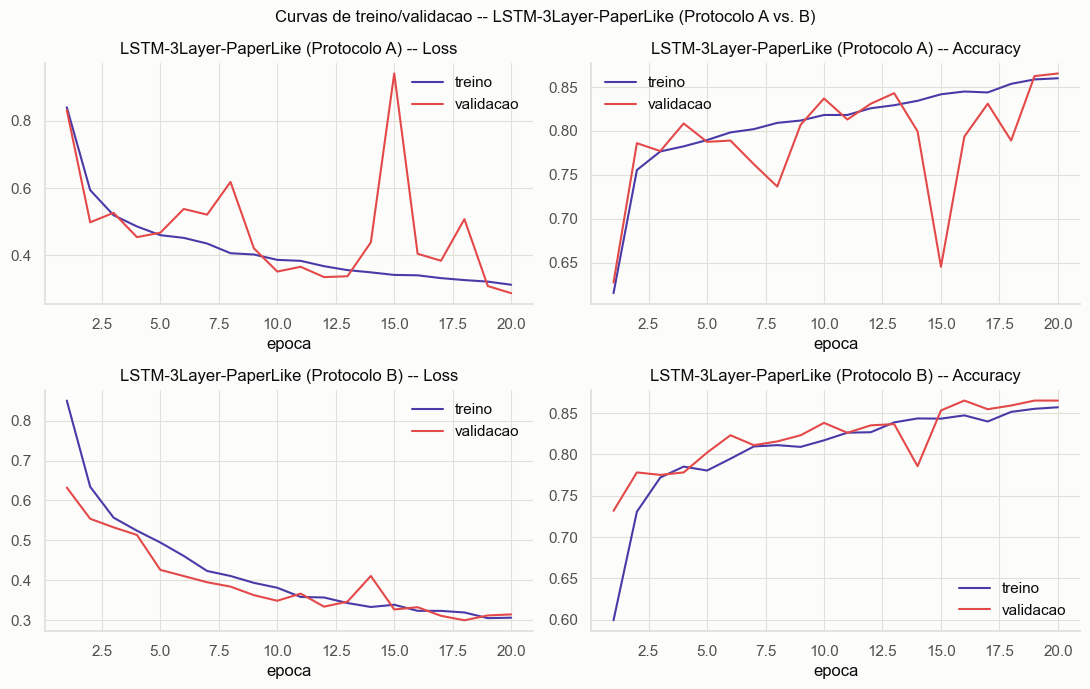

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\13_curvas_treino_lstm3layer.png


In [44]:
if PIPELINE_READY:
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    for ax_row, hist_dict, model_name, protocol_name in [
        (axes[0], hist_A_sequence, "LSTM-3Layer-PaperLike", "Protocolo A"),
        (axes[1], hist_B_sequence, "LSTM-3Layer-PaperLike", "Protocolo B"),
    ]:
        h = hist_dict[model_name]
        epochs_range = range(1, len(h["train_loss"]) + 1)
        ax_row[0].plot(epochs_range, h["train_loss"], color=SEQUENCE_COLOR, label="treino")
        ax_row[0].plot(epochs_range, h["val_loss"], color="#e34948", label="validacao")
        ax_row[0].set_title(f"{model_name} ({protocol_name}) -- Loss"); ax_row[0].set_xlabel("epoca"); ax_row[0].legend(frameon=False)
        ax_row[1].plot(epochs_range, h["train_acc"], color=SEQUENCE_COLOR, label="treino")
        ax_row[1].plot(epochs_range, h["val_acc"], color="#e34948", label="validacao")
        ax_row[1].set_title(f"{model_name} ({protocol_name}) -- Accuracy"); ax_row[1].set_xlabel("epoca"); ax_row[1].legend(frameon=False)
    fig.suptitle("Curvas de treino/validacao -- LSTM-3Layer-PaperLike (Protocolo A vs. B)")
    fig.tight_layout()
    save_fig(fig, "13_curvas_treino_lstm3layer.png")

## 11. Comparação instance versus sequence

Comparações **justas**, sempre dentro do mesmo protocolo: **Instance-A vs. Sequence-A** e
**Instance-B vs. Sequence-B**. Nunca comparamos Instance-A com Sequence-B (ou vice-versa) como
evidência sobre o efeito da sequência — essa era exatamente a falha metodológica da versão
anterior deste notebook.

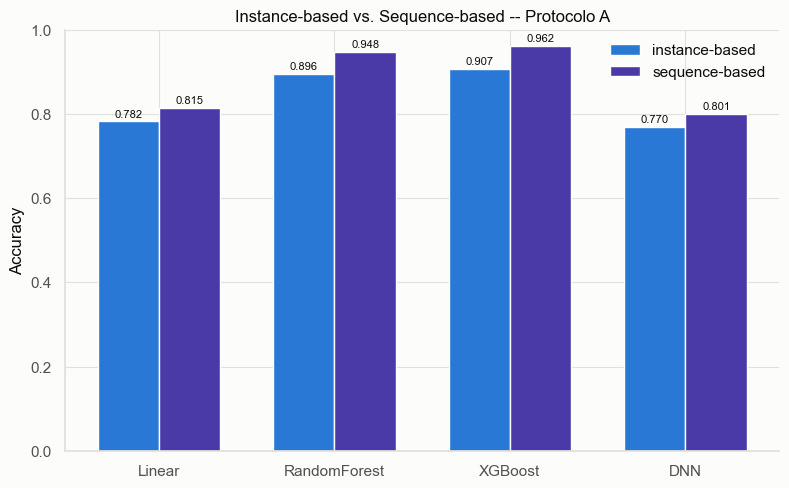

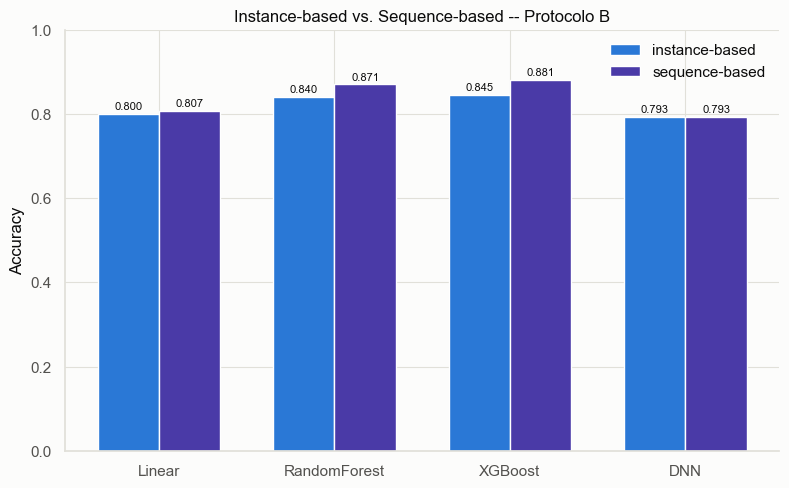

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\14_instance_vs_sequence_protocolo_A.png
Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\15_instance_vs_sequence_protocolo_B.png
Ganho de accuracy (sequence - instance) por modelo, Protocolo A:
  Linear        : +0.0326
  RandomForest  : +0.0520
  XGBoost       : +0.0543
  DNN           : +0.0313
  media: +0.0426

Ganho de accuracy (sequence - instance) por modelo, Protocolo B:
  Linear        : +0.0069
  RandomForest  : +0.0303
  XGBoost       : +0.0357
  DNN           : +0.0003
  media: +0.0183


In [45]:
if PIPELINE_READY:
    common_models = [m for m in ["Linear", "RandomForest", "XGBoost", "DNN"]
                      if m in results_A_instance_df["model"].values and m in results_A_sequence_df["model"].values]

    def paired_bars(inst_df, seq_df, protocol_label, filename):
        inst_acc = inst_df.set_index("model").loc[common_models, "accuracy"]
        seq_acc = seq_df.set_index("model").loc[common_models, "accuracy"]
        x = np.arange(len(common_models)); width = 0.35
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(x - width/2, inst_acc.values, width, color=INSTANCE_COLOR, label="instance-based")
        ax.bar(x + width/2, seq_acc.values, width, color=SEQUENCE_COLOR, label="sequence-based")
        ax.set_xticks(x); ax.set_xticklabels(common_models)
        ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1)
        ax.set_title(f"Instance-based vs. Sequence-based -- Protocolo {protocol_label}")
        ax.legend(frameon=False)
        for i, (a, b) in enumerate(zip(inst_acc.values, seq_acc.values)):
            ax.text(i - width/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=8)
            ax.text(i + width/2, b + 0.01, f"{b:.3f}", ha="center", fontsize=8)
        fig.tight_layout()
        save_fig(fig, filename)
        return inst_acc.values - seq_acc.values

    delta_seq_A = -paired_bars(results_A_instance_df, results_A_sequence_df, "A", "14_instance_vs_sequence_protocolo_A.png")
    delta_seq_B = -paired_bars(results_B_instance_df, results_B_sequence_df, "B", "15_instance_vs_sequence_protocolo_B.png")

    print("Ganho de accuracy (sequence - instance) por modelo, Protocolo A:")
    for m, d in zip(common_models, delta_seq_A):
        print(f"  {m:14s}: {d:+.4f}")
    print(f"  media: {delta_seq_A.mean():+.4f}")

    print("\nGanho de accuracy (sequence - instance) por modelo, Protocolo B:")
    for m, d in zip(common_models, delta_seq_B):
        print(f"  {m:14s}: {d:+.4f}")
    print(f"  media: {delta_seq_B.mean():+.4f}")

### LSTM-1Layer vs. LSTM-3Layer-PaperLike

,protocol,model,accuracy,f1_macro,size_kb,inf_mean_us,n_params
0,A,LSTM-1Layer,0.880503,0.883798,49.395508,1281.4490,11953
1,A,LSTM-3Layer-PaperLike,0.854822,0.859494,210.555664,2900.6845,52753
2,B,LSTM-1Layer,0.796610,0.796149,49.395508,1307.8385,11953
3,B,LSTM-3Layer-PaperLike,0.781780,0.781330,210.555664,2961.6040,52753


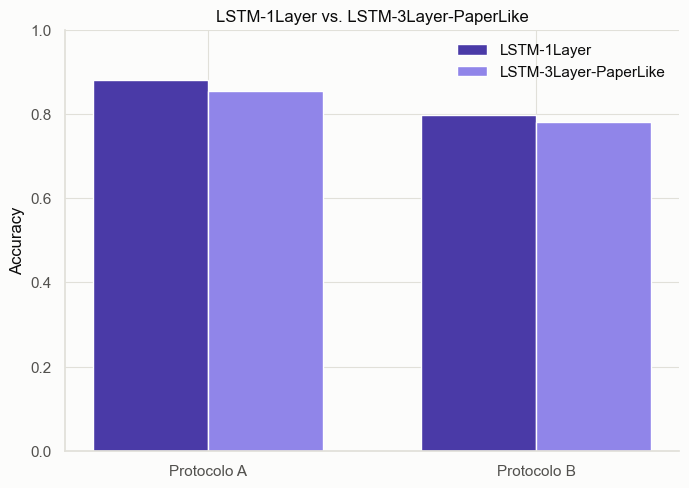

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\16_lstm1layer_vs_lstm3layer.png


In [46]:
if PIPELINE_READY:
    lstm_compare = pd.concat([
        results_A_sequence_df[results_A_sequence_df["model"].isin(["LSTM-1Layer", "LSTM-3Layer-PaperLike"])],
        results_B_sequence_df[results_B_sequence_df["model"].isin(["LSTM-1Layer", "LSTM-3Layer-PaperLike"])],
    ], ignore_index=True)
    display(lstm_compare[["protocol", "model", "accuracy", "f1_macro", "size_kb", "inf_mean_us", "n_params"]])

    fig, ax = plt.subplots(figsize=(7, 5))
    x = np.arange(2); width = 0.35
    protocols = ["A", "B"]
    for i, model_name in enumerate(["LSTM-1Layer", "LSTM-3Layer-PaperLike"]):
        vals = [lstm_compare[(lstm_compare.protocol == p) & (lstm_compare.model == model_name)]["accuracy"].values[0]
                for p in protocols]
        ax.bar(x + (i - 0.5) * width, vals, width,
               color=[SEQUENCE_COLOR, "#9085e9"][i], label=model_name)
    ax.set_xticks(x); ax.set_xticklabels([f"Protocolo {p}" for p in protocols])
    ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1)
    ax.set_title("LSTM-1Layer vs. LSTM-3Layer-PaperLike")
    ax.legend(frameon=False)
    fig.tight_layout()
    save_fig(fig, "16_lstm1layer_vs_lstm3layer.png")

### Split aleatório (Protocolo A) vs. cronológico (Protocolo B)

Esta é a comparação que quantifica diretamente o otimismo do split aleatório frente à
autocorrelação temporal, para cada modelo, tanto instance-based quanto sequence-based.

,input_type,model,accuracy_A,accuracy_B,queda_A_para_B
7,sequence,LSTM-1Layer,0.880503,0.796610,0.083893
5,sequence,XGBoost,0.961740,0.880826,0.080914
6,sequence,RandomForest,0.947589,0.870763,0.076826
8,sequence,LSTM-3Layer-PaperLike,0.854822,0.781780,0.073042
0,instance,XGBoost,0.907407,0.845085,0.062322
1,instance,RandomForest,0.895576,0.840453,0.055123
2,instance,SVM,0.838477,0.823984,0.014494
9,sequence,Linear,0.814990,0.807203,0.007786
10,sequence,DNN,0.800839,0.793432,0.007406
3,instance,Linear,0.782407,0.800309,-0.017901


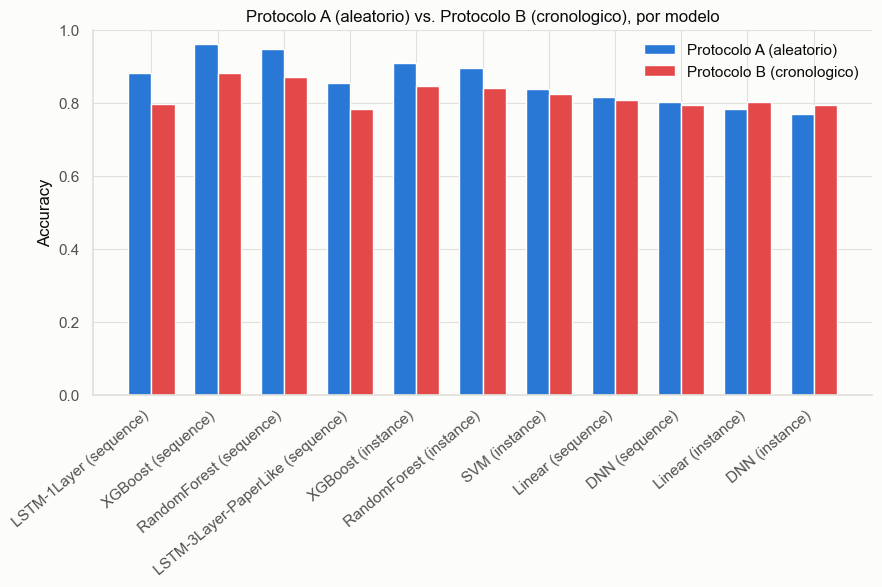

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\17_protocolo_A_vs_B_por_modelo.png

Queda media de accuracy (A -> B): 0.0382


In [47]:
if PIPELINE_READY:
    ab_compare = pd.concat([
        results_A_instance_df.assign(input_type="instance"),
        results_A_sequence_df.assign(input_type="sequence"),
    ], ignore_index=True)[["input_type", "model", "accuracy"]].rename(columns={"accuracy": "accuracy_A"})
    ab_compare_b = pd.concat([
        results_B_instance_df.assign(input_type="instance"),
        results_B_sequence_df.assign(input_type="sequence"),
    ], ignore_index=True)[["input_type", "model", "accuracy"]].rename(columns={"accuracy": "accuracy_B"})
    ab_compare = ab_compare.merge(ab_compare_b, on=["input_type", "model"])
    ab_compare["queda_A_para_B"] = ab_compare["accuracy_A"] - ab_compare["accuracy_B"]
    ab_compare = ab_compare.sort_values("queda_A_para_B", ascending=False)
    display(ab_compare)

    fig, ax = plt.subplots(figsize=(9, 6))
    labels = ab_compare["model"] + " (" + ab_compare["input_type"] + ")"
    x = np.arange(len(labels)); width = 0.35
    ax.bar(x - width/2, ab_compare["accuracy_A"], width, color=PROTOCOL_A_COLOR, label="Protocolo A (aleatorio)")
    ax.bar(x + width/2, ab_compare["accuracy_B"], width, color=PROTOCOL_B_COLOR, label="Protocolo B (cronologico)")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=40, ha="right")
    ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1)
    ax.set_title("Protocolo A (aleatorio) vs. Protocolo B (cronologico), por modelo")
    ax.legend(frameon=False)
    fig.tight_layout()
    save_fig(fig, "17_protocolo_A_vs_B_por_modelo.png")

    print(f"\nQueda media de accuracy (A -> B): {ab_compare['queda_A_para_B'].mean():.4f}")

## 12. Comparação com o artigo

Valores publicados no artigo para o caso de uso **Localization-rApp** (inseridos manualmente,
conforme fornecido no enunciado deste projeto):

In [48]:
ARTICLE_RESULTS = pd.DataFrame([
    ("instance", "DNN",          0.834, 0.841, 0.838, 0.836, 1.7,    2.1),
    ("instance", "Linear",       0.802, 0.836, 0.801, 0.805, 1.0,    3.5),
    ("instance", "RandomForest", 0.828, 0.827, 0.831, 0.828, 1423.4, 9.8),
    ("instance", "SVM",          0.825, 0.857, 0.825, 0.829, 177.6,  112.7),
    ("instance", "XGBoost",      0.844, 0.845, 0.849, 0.843, 973.4,  2.1),
    ("sequence", "DNN",          0.862, 0.871, 0.863, 0.865, 8.5,    3.5),
    ("sequence", "Linear",       0.800, 0.820, 0.801, 0.805, 2.5,    4.9),
    ("sequence", "LSTM-3Layer-PaperLike", 0.911, 0.912, 0.913, 0.912, 201.0, 27.4),
    ("sequence", "RandomForest", 0.858, 0.857, 0.860, 0.858, 1542.5, 11.2),
    ("sequence", "XGBoost",      0.874, 0.880, 0.878, 0.872, 792.0,  2.6),
], columns=["input_type", "model", "accuracy_artigo", "precision_artigo", "recall_artigo",
            "f1_artigo", "size_kb_artigo", "inf_us_artigo"])
display(ARTICLE_RESULTS)

,input_type,model,accuracy_artigo,precision_artigo,recall_artigo,f1_artigo,size_kb_artigo,inf_us_artigo
0,instance,DNN,0.834,0.841,0.838,0.836,1.7,2.1
1,instance,Linear,0.802,0.836,0.801,0.805,1.0,3.5
2,instance,RandomForest,0.828,0.827,0.831,0.828,1423.4,9.8
3,instance,SVM,0.825,0.857,0.825,0.829,177.6,112.7
4,instance,XGBoost,0.844,0.845,0.849,0.843,973.4,2.1
5,sequence,DNN,0.862,0.871,0.863,0.865,8.5,3.5
6,sequence,Linear,0.800,0.820,0.801,0.805,2.5,4.9
7,sequence,LSTM-3Layer-PaperLike,0.911,0.912,0.913,0.912,201.0,27.4
8,sequence,RandomForest,0.858,0.857,0.860,0.858,1542.5,11.2
9,sequence,XGBoost,0.874,0.880,0.878,0.872,792.0,2.6


A tabela do artigo lista uma única linha "LSTM" (sequence-based); associamos essa linha ao nosso
`LSTM-3Layer-PaperLike`, por ser nossa interpretação da arquitetura `LSTM(50,50,50)` da Tabela 2 do
artigo. O `LSTM-1Layer` é um baseline nosso, sem equivalente direto no artigo, e por isso **não**
entra nesta tabela de comparação.

Usamos o **Protocolo A** (mais próximo do holdout aleatório aparentemente usado no artigo) como
comparação principal; o Protocolo B aparece como avaliação adicional de robustez (colunas
`accuracy_B` etc.).

In [49]:
if PIPELINE_READY:
    obtained_A = pd.concat([results_A_instance_df, results_A_sequence_df], ignore_index=True)[
        ["input_type", "model", "accuracy", "precision_macro", "recall_macro", "f1_macro", "size_kb", "inf_mean_us"]
    ].rename(columns={"accuracy": "accuracy_obtido_A", "precision_macro": "precision_obtido_A",
                       "recall_macro": "recall_obtido_A", "f1_macro": "f1_obtido_A",
                       "size_kb": "size_kb_obtido_A", "inf_mean_us": "inf_us_obtido_A"})
    obtained_B = pd.concat([results_B_instance_df, results_B_sequence_df], ignore_index=True)[
        ["input_type", "model", "accuracy", "f1_macro"]
    ].rename(columns={"accuracy": "accuracy_obtido_B", "f1_macro": "f1_obtido_B"})

    comparison_rows = []
    for _, art_row in ARTICLE_RESULTS.iterrows():
        obt_a = obtained_A[(obtained_A.input_type == art_row.input_type) & (obtained_A.model == art_row.model)]
        obt_b = obtained_B[(obtained_B.input_type == art_row.input_type) & (obtained_B.model == art_row.model)]
        if obt_a.empty:
            continue
        obt_a = obt_a.iloc[0]
        row = {
            "protocolo": "A (holdout aleatorio 70/30)", "input_type": art_row.input_type, "modelo": art_row.model,
            "metrica": "accuracy", "valor_artigo": art_row.accuracy_artigo, "valor_obtido": obt_a.accuracy_obtido_A,
            "diferenca_abs": obt_a.accuracy_obtido_A - art_row.accuracy_artigo,
            "diferenca_pct": (obt_a.accuracy_obtido_A - art_row.accuracy_artigo) / art_row.accuracy_artigo * 100,
            "seed": SEED,
            "observacao": "tempo/tamanho nao comparaveis entre hardware/serializacoes distintas",
        }
        comparison_rows.append(row)
        for metric, art_col, obt_col in [
            ("precision_macro", "precision_artigo", "precision_obtido_A"),
            ("recall_macro", "recall_artigo", "recall_obtido_A"),
            ("f1_macro", "f1_artigo", "f1_obtido_A"),
            ("size_kb", "size_kb_artigo", "size_kb_obtido_A"),
            ("inf_us", "inf_us_artigo", "inf_us_obtido_A"),
        ]:
            art_val, obt_val = art_row[art_col], obt_a[obt_col]
            comparison_rows.append({
                "protocolo": "A (holdout aleatorio 70/30)", "input_type": art_row.input_type, "modelo": art_row.model,
                "metrica": metric, "valor_artigo": art_val, "valor_obtido": obt_val,
                "diferenca_abs": obt_val - art_val, "diferenca_pct": (obt_val - art_val) / art_val * 100,
                "seed": SEED,
                "observacao": "tempo/tamanho nao comparaveis entre hardware/serializacoes distintas"
                              if metric in ("size_kb", "inf_us") else "",
            })

    comparison_df = pd.DataFrame(comparison_rows)
    display(comparison_df.round(4))
    comparison_df.to_csv(RESULTS_DIR / "comparison_with_article.csv", index=False)
    print("\nSalvo em:", RESULTS_DIR / "comparison_with_article.csv")

,protocolo,input_type,modelo,metrica,valor_artigo,valor_obtido,diferenca_abs,diferenca_pct,seed,observacao
0,A (holdout aleatorio 70/30),instance,DNN,accuracy,0.834,0.7695,-0.0645,-7.7281,42,tempo/tamanho nao comparaveis entre hardware/s...
1,A (holdout aleatorio 70/30),instance,DNN,precision_macro,0.841,0.8069,-0.0341,-4.0536,42,
2,A (holdout aleatorio 70/30),instance,DNN,recall_macro,0.838,0.7681,-0.0699,-8.3422,42,
3,A (holdout aleatorio 70/30),instance,DNN,f1_macro,0.836,0.7756,-0.0604,-7.2194,42,
4,A (holdout aleatorio 70/30),instance,DNN,size_kb,1.700,3.6533,1.9533,114.9012,42,tempo/tamanho nao comparaveis entre hardware/s...
5,A (holdout aleatorio 70/30),instance,DNN,inf_us,2.100,260.6825,258.5825,12313.4524,42,tempo/tamanho nao comparaveis entre hardware/s...
6,A (holdout aleatorio 70/30),instance,Linear,accuracy,0.802,0.7824,-0.0196,-2.4430,42,tempo/tamanho nao comparaveis entre hardware/s...
7,A (holdout aleatorio 70/30),instance,Linear,precision_macro,0.836,0.8025,-0.0335,-4.0122,42,
8,A (holdout aleatorio 70/30),instance,Linear,recall_macro,0.801,0.7837,-0.0173,-2.1582,42,
9,A (holdout aleatorio 70/30),instance,Linear,f1_macro,0.805,0.7866,-0.0184,-2.2871,42,



Salvo em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\results\comparison_with_article.csv


### Possíveis causas de discrepância entre este relatório e o artigo

- **Aleatoriedade**: mesmo com `random_state=42` fixo, inicializações e ordens de embaralhamento diferem entre bibliotecas/versões;
- **Versões de bibliotecas**: `scikit-learn`, `xgboost` e `torch` (Seção 3) podem diferir das versões do artigo, não especificadas;
- **Hardware**: os tempos de inferência do artigo (poucos microssegundos) sugerem hardware/otimizações não replicadas aqui;
- **Interpretação da arquitetura**: a LSTM de 3 camadas é nossa interpretação de `LSTM(50,50,50)`; detalhes de agregação temporal e *gamma* do *scheduler* não são especificados;
- **Arquivos efetivamente utilizados**: não é possível confirmar se o artigo usa exatamente os mesmos quatro arquivos, na mesma proporção;
- **Tratamento de valores ausentes**: removemos linhas com `NaN` nas 7 features; o artigo não detalha sua estratégia;
- **Split aleatório vs. temporal**: o Protocolo B (Seções 10-11) mostra que o split aleatório é otimista frente a uma divisão cronológica;
- **Macro vs. weighted average**: reportamos ambos; assumimos *macro* como comparação principal;
- **Ausência de "rounds" explícitos**: sem coluna de identificação de repetições de caminhada, usamos o fallback cronológico por arquivo no Protocolo B;
- **Ambiguidade em hiperparâmetros**: RF, SVM e XGBoost não têm hiperparâmetros detalhados no artigo;
- **Forma de serialização do modelo**: `joblib`/`torch.save` podem diferir do formato do artigo, afetando o tamanho em kB;
- **Metodologia de medição de inferência**: documentada na Seção 8, mas não necessariamente idêntica à do artigo.

## 13. Estudo de janela

Testamos janelas de tamanho $w \in \{1, 5, 10, 20\}$ amostras, usando **XGBoost** (achatado) e
**LSTM-3Layer-PaperLike** como modelos representativos, sob o **Protocolo B** (cronológico, mais
rigoroso — preferência explícita para este estudo). Cada tamanho de janela usa o mesmo protocolo,
os mesmos arquivos e a mesma semente (42); os resultados não são misturados com o Protocolo A.

In [50]:
window_sensitivity_results = []

if PIPELINE_READY:
    for w in [1, 5, 10, 20]:
        set_global_seed(SEED)
        (Xtr_w, ytr_w, _, _), (Xte_w, yte_w, _, _) = protocol_b_sequence_split(
            df_main_clean, CANON_FEATURES, window_size=w, stride=1)

        nf = Xtr_w.shape[2]
        sc = MinMaxScaler().fit(Xtr_w.reshape(-1, nf))
        Xtr_w_s = sc.transform(Xtr_w.reshape(-1, nf)).reshape(Xtr_w.shape)
        Xte_w_s = sc.transform(Xte_w.reshape(-1, nf)).reshape(Xte_w.shape)

        t0 = time.perf_counter()
        xgb_w = XGBClassifier(**HYPERPARAMS["xgboost"], eval_metric="mlogloss")
        xgb_w.fit(flatten_windows(Xtr_w_s), ytr_w)
        train_time_xgb = time.perf_counter() - t0
        y_pred_xgb = xgb_w.predict(flatten_windows(Xte_w_s))
        m_xgb = compute_metrics(yte_w, y_pred_xgb)
        inf_mean_xgb, _ = measure_inference_time(xgb_w.predict, flatten_windows(Xte_w_s))

        Xtr_w_fit, Xval_w, ytr_w_fit, yval_w = train_test_split(
            Xtr_w_s, ytr_w, test_size=0.15, random_state=SEED, stratify=ytr_w)
        torch.manual_seed(SEED)
        lstm_w = LocalizationLSTM(input_size=nf, hidden_size=50, num_layers=3, num_classes=3)
        t0 = time.perf_counter()
        lstm_w, _ = train_torch_classifier(lstm_w, Xtr_w_fit, ytr_w_fit, Xval_w, yval_w, n_epochs=20,
                                             batch_size=32, lr=0.001, optimizer_cls=torch.optim.RMSprop,
                                             scheduler_gamma=0.95, seed=SEED)
        train_time_lstm = time.perf_counter() - t0
        wrapper_w = TorchClassifierWrapper(lstm_w)
        y_pred_lstm = wrapper_w.predict(Xte_w_s)
        m_lstm = compute_metrics(yte_w, y_pred_lstm)
        inf_mean_lstm, _ = measure_inference_time(wrapper_w.predict, Xte_w_s)

        window_sensitivity_results.append({
            "protocol": "B", "window_size": w, "n_train_windows": len(Xtr_w), "n_test_windows": len(Xte_w),
            "model": "XGBoost", "accuracy": m_xgb["accuracy"], "f1_macro": m_xgb["f1_macro"],
            "train_time_s": train_time_xgb, "inf_mean_us": inf_mean_xgb,
        })
        window_sensitivity_results.append({
            "protocol": "B", "window_size": w, "n_train_windows": len(Xtr_w), "n_test_windows": len(Xte_w),
            "model": "LSTM-3Layer-PaperLike", "accuracy": m_lstm["accuracy"], "f1_macro": m_lstm["f1_macro"],
            "train_time_s": train_time_lstm, "inf_mean_us": inf_mean_lstm,
        })
        print(f"window={w:2d} (Protocolo B)  n_train={len(Xtr_w):5d}  n_test={len(Xte_w):5d}  "
              f"acc_XGB={m_xgb['accuracy']:.4f}  acc_LSTM3={m_lstm['accuracy']:.4f}")

    set_global_seed(SEED)
    window_sensitivity_df = pd.DataFrame(window_sensitivity_results)
    window_sensitivity_df.to_csv(RESULTS_DIR / "window_sensitivity.csv", index=False)
    display(window_sensitivity_df)

,protocol,window_size,n_train_windows,n_test_windows,model,accuracy,f1_macro,train_time_s,inf_mean_us
0,B,1,4536,1943,XGBoost,0.845085,0.844420,2.015025,1653.6615
1,B,1,4536,1943,LSTM-3Layer-PaperLike,0.781781,0.784101,39.991589,3029.1635
2,B,5,4492,1918,XGBoost,0.861314,0.859339,2.477550,1706.1445
3,B,5,4492,1918,LSTM-3Layer-PaperLike,0.765381,0.765372,54.358276,2843.6695
4,B,10,4442,1888,XGBoost,0.880826,0.878657,3.282707,1694.3585
5,B,10,4442,1888,LSTM-3Layer-PaperLike,0.781780,0.781330,72.846607,2903.9245
6,B,20,4342,1828,XGBoost,0.898796,0.896426,4.366819,1749.6410
7,B,20,4342,1828,LSTM-3Layer-PaperLike,0.920131,0.922026,116.657364,3229.1765


window= 1 (Protocolo B)  n_train= 4536  n_test= 1943  acc_XGB=0.8451  acc_LSTM3=0.7818
window= 5 (Protocolo B)  n_train= 4492  n_test= 1918  acc_XGB=0.8613  acc_LSTM3=0.7654
window=10 (Protocolo B)  n_train= 4442  n_test= 1888  acc_XGB=0.8808  acc_LSTM3=0.7818
window=20 (Protocolo B)  n_train= 4342  n_test= 1828  acc_XGB=0.8988  acc_LSTM3=0.9201


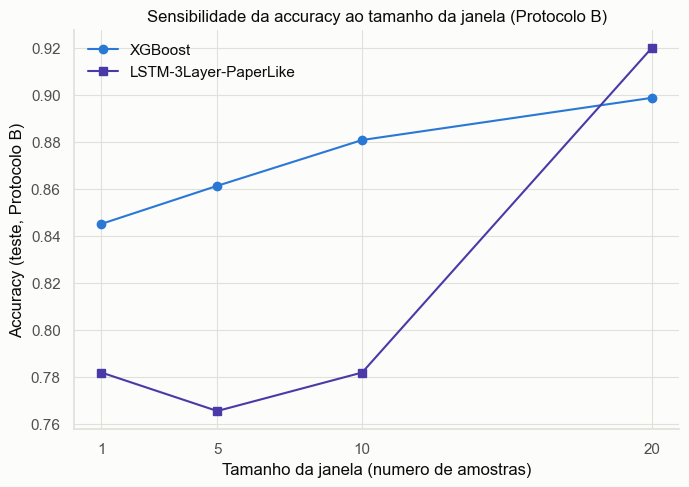

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\18_sensibilidade_tamanho_janela.png


In [51]:
if PIPELINE_READY:
    fig, ax = plt.subplots(figsize=(7, 5))
    for model_name, color, marker in [("XGBoost", INSTANCE_COLOR, "o"), ("LSTM-3Layer-PaperLike", SEQUENCE_COLOR, "s")]:
        sub = window_sensitivity_df[window_sensitivity_df.model == model_name]
        ax.plot(sub["window_size"], sub["accuracy"], marker=marker, color=color, label=model_name)
    ax.set_xlabel("Tamanho da janela (numero de amostras)")
    ax.set_ylabel("Accuracy (teste, Protocolo B)")
    ax.set_title("Sensibilidade da accuracy ao tamanho da janela (Protocolo B)")
    ax.set_xticks([1, 5, 10, 20])
    ax.legend(frameon=False)
    fig.tight_layout()
    save_fig(fig, "18_sensibilidade_tamanho_janela.png")

## 14. Ablation study

Comparamos três conjuntos de *features*, com **XGBoost** e **LSTM-3Layer-PaperLike** (ambos sobre
janelas), sob o mesmo protocolo (B, cronológico), os mesmos índices por conjunto e a mesma semente
(42):

- **A.** apenas sinal: RSRP, RSRQ, SINR (3 atributos);
- **B.** as 7 *features* do artigo (conjunto principal);
- **C.** as 7 *features* + `PUSCH PRBs` (8 atributos — ablação exploratória, não reprodução).

In [52]:
ablation_results = []

if PIPELINE_READY:
    all_needed_feats = list(dict.fromkeys(CANON_FEATURES + ["PUSCH_PRBs"]))
    df_main_8feat = prepare_features(df_main, all_needed_feats)
    df_main_8feat["_row_id"] = np.arange(len(df_main_8feat))

    feature_sets = {
        "RSRP_RSRQ_SINR (3 feats)": (["RSRP", "RSRQ", "SINR"], df_main_clean),
        "Artigo (7 feats)": (CANON_FEATURES, df_main_clean),
        "Artigo + PUSCH_PRBs (8 feats)": (CANON_FEATURES + ["PUSCH_PRBs"], df_main_8feat),
    }

    for name, (feats, source_df) in feature_sets.items():
        set_global_seed(SEED)
        (Xtr_f, ytr_f, _, _), (Xte_f, yte_f, _, _) = protocol_b_sequence_split(source_df, feats, window_size=WINDOW_SIZE, stride=1)
        nf = Xtr_f.shape[2]
        sc = MinMaxScaler().fit(Xtr_f.reshape(-1, nf))
        Xtr_f_s = sc.transform(Xtr_f.reshape(-1, nf)).reshape(Xtr_f.shape)
        Xte_f_s = sc.transform(Xte_f.reshape(-1, nf)).reshape(Xte_f.shape)

        xgb_f = XGBClassifier(**HYPERPARAMS["xgboost"], eval_metric="mlogloss")
        xgb_f.fit(flatten_windows(Xtr_f_s), ytr_f)
        m_xgb = compute_metrics(yte_f, xgb_f.predict(flatten_windows(Xte_f_s)))
        ablation_results.append({"feature_set": name, "n_features": len(feats), "model": "XGBoost", **m_xgb})

        Xtr_f_fit, Xval_f, ytr_f_fit, yval_f = train_test_split(
            Xtr_f_s, ytr_f, test_size=0.15, random_state=SEED, stratify=ytr_f)
        torch.manual_seed(SEED)
        lstm_f = LocalizationLSTM(input_size=nf, hidden_size=50, num_layers=3, num_classes=3)
        lstm_f, _ = train_torch_classifier(lstm_f, Xtr_f_fit, ytr_f_fit, Xval_f, yval_f, n_epochs=20,
                                             batch_size=32, lr=0.001, optimizer_cls=torch.optim.RMSprop,
                                             scheduler_gamma=0.95, seed=SEED)
        m_lstm = compute_metrics(yte_f, TorchClassifierWrapper(lstm_f).predict(Xte_f_s))
        ablation_results.append({"feature_set": name, "n_features": len(feats), "model": "LSTM-3Layer-PaperLike", **m_lstm})

        print(f"{name:32s} XGB acc={m_xgb['accuracy']:.4f}  LSTM3 acc={m_lstm['accuracy']:.4f}")

    set_global_seed(SEED)
    ablation_df = pd.DataFrame(ablation_results)
    ablation_df.to_csv(RESULTS_DIR / "ablation_results.csv", index=False)
    display(ablation_df)

,feature_set,n_features,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,RSRP_RSRQ_SINR (3 feats),3,XGBoost,0.780191,0.780243,0.780460,0.779071,0.784592,0.780191,0.781181
1,RSRP_RSRQ_SINR (3 feats),3,LSTM-3Layer-PaperLike,0.746292,0.752190,0.741635,0.741004,0.750472,0.746292,0.742389
2,Artigo (7 feats),7,XGBoost,0.880826,0.885578,0.885279,0.878657,0.889452,0.880826,0.878277
3,Artigo (7 feats),7,LSTM-3Layer-PaperLike,0.781780,0.787628,0.791976,0.781330,0.789461,0.781780,0.777584
4,Artigo + PUSCH_PRBs (8 feats),8,XGBoost,0.879237,0.883310,0.883506,0.877027,0.887142,0.879237,0.876729
5,Artigo + PUSCH_PRBs (8 feats),8,LSTM-3Layer-PaperLike,0.843750,0.848808,0.851660,0.842694,0.852645,0.843750,0.840986


Linhas antes=6580  depois=6479  removidas=101 (1.53%)
RSRP_RSRQ_SINR (3 feats)         XGB acc=0.7802  LSTM3 acc=0.7463
Artigo (7 feats)                 XGB acc=0.8808  LSTM3 acc=0.7818
Artigo + PUSCH_PRBs (8 feats)    XGB acc=0.8792  LSTM3 acc=0.8438


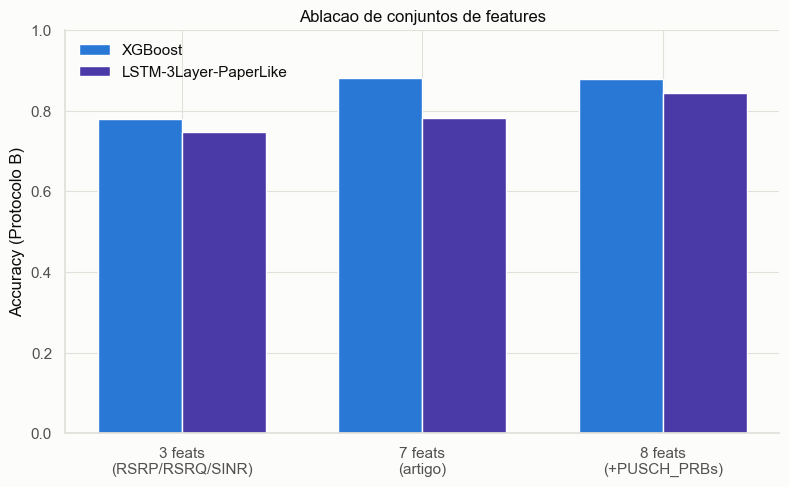

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\19_ablacao_features.png


In [53]:
if PIPELINE_READY:
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(3); width = 0.35
    order = ["RSRP_RSRQ_SINR (3 feats)", "Artigo (7 feats)", "Artigo + PUSCH_PRBs (8 feats)"]
    xgb_vals = [ablation_df[(ablation_df.feature_set == o) & (ablation_df.model == "XGBoost")]["accuracy"].values[0] for o in order]
    lstm_vals = [ablation_df[(ablation_df.feature_set == o) & (ablation_df.model == "LSTM-3Layer-PaperLike")]["accuracy"].values[0] for o in order]
    ax.bar(x - width/2, xgb_vals, width, color=INSTANCE_COLOR, label="XGBoost")
    ax.bar(x + width/2, lstm_vals, width, color=SEQUENCE_COLOR, label="LSTM-3Layer-PaperLike")
    ax.set_xticks(x); ax.set_xticklabels(["3 feats\n(RSRP/RSRQ/SINR)", "7 feats\n(artigo)", "8 feats\n(+PUSCH_PRBs)"])
    ax.set_ylabel("Accuracy (Protocolo B)"); ax.set_ylim(0, 1)
    ax.set_title("Ablacao de conjuntos de features")
    ax.legend(frameon=False)
    fig.tight_layout()
    save_fig(fig, "19_ablacao_features.png")

## 15. Teste OOD (out-of-distribution)

O modelo principal é treinado **apenas** com Level 4, Level 5 e Level 6 (todas as RRUs ativas —
conjunto principal). Aqui avaliamos **três modelos já treinados** (nenhum é re-treinado com dados
OOD) no arquivo **Level 6 com apenas 1 RRU ativa** (`Lvl6_1RRUOn`), que não participou de nenhum
treino:

1. **`XGBoost-Instance-Protocol-A`** — o modelo instance-based com maior acurácia sob o Protocolo A
   (Seção 9). Nomeado explicitamente com o protocolo para não ser confundido com o modelo
   efetivamente recomendado para produção.
2. **`XGBoost-Sequence-Protocol-B`** — o modelo sequencial treinado sob o **Protocolo B**
   (avaliação independente, Seção 10), que é o candidato recomendado para produção (Seção 18).
3. **`LSTM-3Layer-PaperLike-Protocol-B`** — a arquitetura principal do artigo, também sob o
   Protocolo B, para comparação.

Para os dois modelos sequenciais, o conjunto OOD é processado com o **mesmo procedimento usado no
treino do Protocolo B**: carregar o arquivo, ordenar cronologicamente, aplicar as sete features do
artigo, normalizar com o **scaler ajustado no treino sequencial do Protocolo B** (nunca ajustado
nos dados OOD), construir janelas de tamanho 10 e stride 1 impedindo janelas sobre descontinuidades
temporais, e avaliar — sem que nenhuma amostra OOD tenha participado do treino de nenhum modelo.

**Isto não é uma classificação multiclasse convencional**: todas as amostras OOD pertencem, na
verdade, ao mesmo andar físico (Level 6) — portanto **não existe um "accuracy" multiclasse
significativo** aqui, pois não há amostras de outras classes verdadeiras para comparar. Em vez
disso, para cada modelo reportamos: o percentual previsto para cada andar, a **probabilidade
máxima prevista** (média e desvio-padrão), a **entropia média** das probabilidades, o número de
observações avaliadas, e uma comparação com o desempenho em distribuição (Level 6 AllRRUOn, no
conjunto de teste do respectivo protocolo).

> **Nota sobre calibração.** As probabilidades produzidas pelos modelos (`predict_proba` do
> XGBoost; *softmax* da LSTM) **não foram calibradas** (nenhum `CalibratedClassifierCV` ou
> equivalente foi aplicado). Portanto, a **probabilidade máxima prevista** não deve ser
> interpretada como confiança probabilística calibrada — é apenas um indicador relativo de quão
> "decidido" o modelo estava entre as três classes.

In [54]:
if PIPELINE_READY and df_ood is not None:
    df_ood_clean = prepare_features(df_ood, CANON_FEATURES)
    df_ood_clean["_row_id"] = np.arange(len(df_ood_clean))
    print(f"Amostras OOD (Level 6, 1 RRU) apos limpeza: {len(df_ood_clean)}")
    print("Distribuicao do rotulo verdadeiro no conjunto OOD (esperado: 100% classe 2 -- Level 6):")
    print(pd.Series(df_ood_clean["location"]).value_counts())

    X_ood_inst_raw = df_ood_clean[CANON_FEATURES].values
    y_ood_true = df_ood_clean["location"].values

    X_ood_seq_raw, y_ood_seq, meta_ood_seq, rid_ood_seq = build_windows_full(df_ood_clean, CANON_FEATURES)
    print(f"Janelas OOD sequenciais construidas (janela=10, stride=1): {len(X_ood_seq_raw)}")
else:
    print("Teste OOD nao executado (PIPELINE_READY=False ou arquivo Level6-1RRU ausente).")

Linhas antes=2156  depois=2148  removidas=8 (0.37%)
Amostras OOD (Level 6, 1 RRU) apos limpeza: 2148
Distribuicao do rotulo verdadeiro no conjunto OOD (esperado: 100% classe 2 -- Level 6):
location
2    2148
Name: count, dtype: int64
Janelas OOD sequenciais construidas (janela=10, stride=1): 2130


### Avaliação dos três modelos

Função reutilizável `evaluate_ood_model` aplicada aos três candidatos.

In [55]:
def evaluate_ood_model(predict_proba_fn, X_ood, model_name: str, protocol_label: str,
                        tipo_entrada: str, in_dist_pct_lvl6: float) -> dict:
    '''Avalia um modelo ja treinado sobre dados fora de distribuicao (OOD). Como todas as
    amostras OOD pertencem a mesma classe verdadeira (Level 6), NAO reporta "accuracy" -- reporta
    distribuicao de previsoes, probabilidade maxima prevista (nao calibrada) e entropia.'''
    proba = predict_proba_fn(X_ood)
    preds = proba.argmax(axis=1)
    pred_dist = pd.Series(preds).value_counts(normalize=True).reindex([0, 1, 2], fill_value=0.0) * 100
    max_proba = proba.max(axis=1)
    entropy = (-proba * np.log(proba + 1e-12)).sum(axis=1)
    pct_lvl6 = float(pred_dist[2])
    return {
        "modelo": model_name, "protocolo": protocol_label, "tipo_entrada": tipo_entrada,
        "n_observacoes": int(len(X_ood)),
        "pct_pred_lvl4": float(pred_dist[0]), "pct_pred_lvl5": float(pred_dist[1]),
        "pct_pred_lvl6": pct_lvl6,
        "max_probability_mean": float(max_proba.mean()), "max_probability_std": float(max_proba.std()),
        "entropy_mean": float(entropy.mean()),
        "in_distribution_pct_lvl6": in_dist_pct_lvl6,
        "ood_drop_pp": in_dist_pct_lvl6 - pct_lvl6,
    }


def in_distribution_pct_lvl6(predict_proba_fn, X_test, y_test) -> float:
    '''Percentual de amostras VERDADEIRAMENTE Level 6 classificadas corretamente como Level 6,
    no conjunto de teste em distribuicao do proprio protocolo do modelo.'''
    preds = predict_proba_fn(X_test).argmax(axis=1)
    mask = (np.asarray(y_test) == 2)
    return float((preds[mask] == 2).mean() * 100) if mask.sum() > 0 else float("nan")


ood_rows = []
ood_preds_by_model = {}

if PIPELINE_READY and df_ood is not None:
    # ---- 1) XGBoost-Instance-Protocol-A ----
    xgb_inst_a = models_A_instance["XGBoost"]
    X_test_A_inst = df_main_clean.loc[idxA_test, CANON_FEATURES].values
    y_test_A_inst = df_main_clean.loc[idxA_test, "location"].values
    in_dist_a = in_distribution_pct_lvl6(xgb_inst_a.predict_proba, X_test_A_inst, y_test_A_inst)
    row_a = evaluate_ood_model(xgb_inst_a.predict_proba, X_ood_inst_raw,
                                 "XGBoost-Instance-Protocol-A", "A", "instance", in_dist_a)
    ood_rows.append(row_a)
    ood_preds_by_model["XGBoost-Instance-Protocol-A"] = xgb_inst_a.predict_proba(X_ood_inst_raw).argmax(axis=1)

    # ---- 2) XGBoost-Sequence-Protocol-B ----
    nf_ood = X_ood_seq_raw.shape[2]
    X_ood_seq_scaled = scalerB_sequence.transform(X_ood_seq_raw.reshape(-1, nf_ood)).reshape(X_ood_seq_raw.shape)
    X_ood_seq_flat = flatten_windows(X_ood_seq_scaled)

    Xte_seqB_scaled = scalerB_sequence.transform(Xte_seqB.reshape(-1, nf_ood)).reshape(Xte_seqB.shape)
    Xte_seqB_flat = flatten_windows(Xte_seqB_scaled)

    xgb_seq_b = models_B_sequence["XGBoost"]
    in_dist_b_xgb = in_distribution_pct_lvl6(xgb_seq_b.predict_proba, Xte_seqB_flat, yte_seqB)
    row_b_xgb = evaluate_ood_model(xgb_seq_b.predict_proba, X_ood_seq_flat,
                                     "XGBoost-Sequence-Protocol-B", "B", "sequence", in_dist_b_xgb)
    ood_rows.append(row_b_xgb)
    ood_preds_by_model["XGBoost-Sequence-Protocol-B"] = xgb_seq_b.predict_proba(X_ood_seq_flat).argmax(axis=1)

    # ---- 3) LSTM-3Layer-PaperLike-Protocol-B ----
    lstm3_b = TorchClassifierWrapper(models_B_sequence["LSTM-3Layer-PaperLike"])
    in_dist_b_lstm = in_distribution_pct_lvl6(lstm3_b.predict_proba, Xte_seqB_scaled, yte_seqB)
    row_b_lstm = evaluate_ood_model(lstm3_b.predict_proba, X_ood_seq_scaled,
                                      "LSTM-3Layer-PaperLike-Protocol-B", "B", "sequence", in_dist_b_lstm)
    ood_rows.append(row_b_lstm)
    ood_preds_by_model["LSTM-3Layer-PaperLike-Protocol-B"] = lstm3_b.predict(X_ood_seq_scaled)

    ood_results_df = pd.DataFrame(ood_rows)
    ood_results_df.to_csv(RESULTS_DIR / "ood_results.csv", index=False)
    display(ood_results_df.round(3))

    for _, r in ood_results_df.iterrows():
        print(f"\n{r['modelo']}: previsto Lvl4={r['pct_pred_lvl4']:.1f}% Lvl5={r['pct_pred_lvl5']:.1f}% "
              f"Lvl6={r['pct_pred_lvl6']:.1f}%  |  prob.maxima media={r['max_probability_mean']:.3f} "
              f"(dp={r['max_probability_std']:.3f})  |  entropia media={r['entropy_mean']:.3f} nats  |  "
              f"em distribuicao Lvl6 correto={r['in_distribution_pct_lvl6']:.1f}%  |  "
              f"queda={r['ood_drop_pp']:.1f}pp")
else:
    ood_results_df = pd.DataFrame()
    print("Teste OOD nao executado (PIPELINE_READY=False ou arquivo Level6-1RRU ausente).")

,modelo,protocolo,tipo_entrada,n_observacoes,pct_pred_lvl4,pct_pred_lvl5,pct_pred_lvl6,max_probability_mean,max_probability_std,entropy_mean,in_distribution_pct_lvl6,ood_drop_pp
0,XGBoost-Instance-Protocol-A,A,instance,2148,43.994,22.020,33.985,0.868,0.149,0.327,91.128,57.143
1,XGBoost-Sequence-Protocol-B,B,sequence,2130,47.746,22.207,30.047,0.907,0.142,0.229,96.037,65.990
2,LSTM-3Layer-PaperLike-Protocol-B,B,sequence,2130,44.460,27.606,27.934,0.767,0.168,0.492,74.695,46.761



XGBoost-Instance-Protocol-A: previsto Lvl4=44.0% Lvl5=22.0% Lvl6=34.0%  |  prob.maxima media=0.868 (dp=0.149)  |  entropia media=0.327 nats  |  em distribuicao Lvl6 correto=91.1%  |  queda=57.1pp

XGBoost-Sequence-Protocol-B: previsto Lvl4=47.7% Lvl5=22.2% Lvl6=30.0%  |  prob.maxima media=0.907 (dp=0.142)  |  entropia media=0.229 nats  |  em distribuicao Lvl6 correto=96.0%  |  queda=66.0pp

LSTM-3Layer-PaperLike-Protocol-B: previsto Lvl4=44.5% Lvl5=27.6% Lvl6=27.9%  |  prob.maxima media=0.767 (dp=0.168)  |  entropia media=0.492 nats  |  em distribuicao Lvl6 correto=74.7%  |  queda=46.8pp


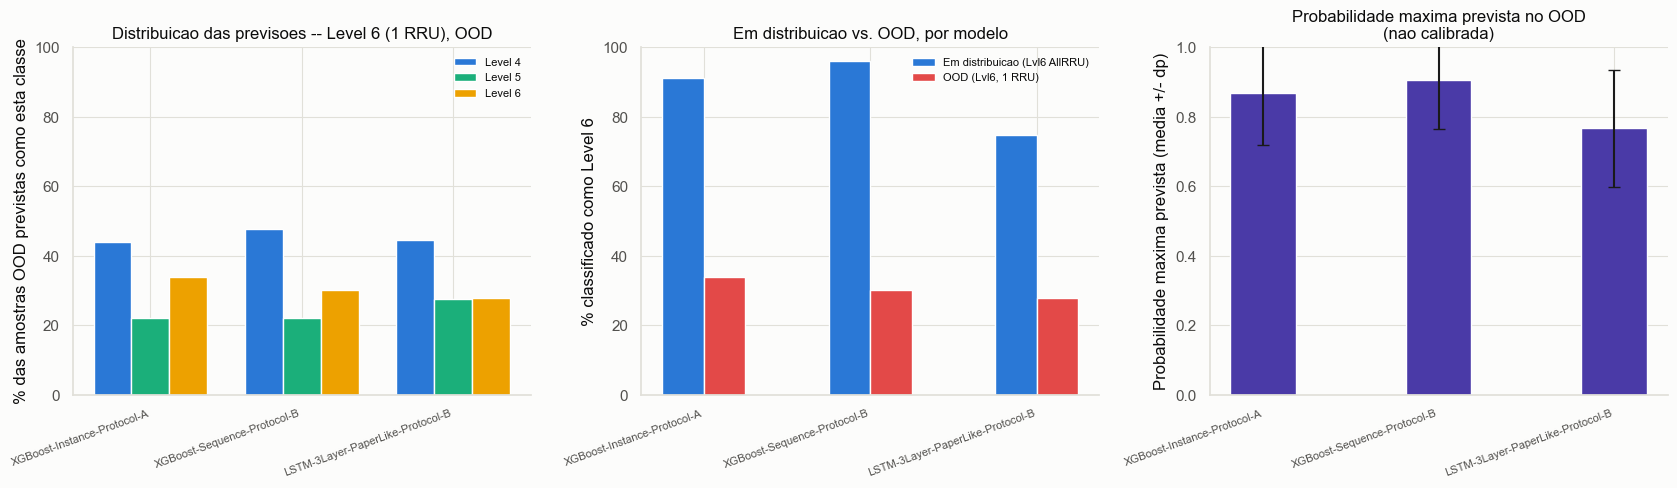

Figura salva em: C:\Users\diego\Desktop\Cursos\Curso OpenRAN Professionals\Nova pasta\figures\20_teste_ood_distribuicao_confianca.png


In [56]:
if PIPELINE_READY and df_ood is not None:
    models_ood_order = ["XGBoost-Instance-Protocol-A", "XGBoost-Sequence-Protocol-B",
                         "LSTM-3Layer-PaperLike-Protocol-B"]
    df_plot = ood_results_df.set_index("modelo").loc[models_ood_order]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    x = np.arange(len(models_ood_order))
    width = 0.25
    for i, loc in enumerate([0, 1, 2]):
        vals = df_plot[f"pct_pred_lvl{loc+4}"].values
        axes[0].bar(x + (i - 1) * width, vals, width, color=FLOOR_PALETTE[loc], label=FLOOR_LABELS[loc])
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models_ood_order, rotation=20, ha="right", fontsize=8)
    axes[0].set_ylabel("% das amostras OOD previstas como esta classe")
    axes[0].set_title("Distribuicao das previsoes -- Level 6 (1 RRU), OOD")
    axes[0].set_ylim(0, 100)
    axes[0].legend(frameon=False, fontsize=8)

    axes[1].bar(x - width / 2, df_plot["in_distribution_pct_lvl6"].values, width,
                color=INSTANCE_COLOR, label="Em distribuicao (Lvl6 AllRRU)")
    axes[1].bar(x + width / 2, df_plot["pct_pred_lvl6"].values, width,
                color="#e34948", label="OOD (Lvl6, 1 RRU)")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(models_ood_order, rotation=20, ha="right", fontsize=8)
    axes[1].set_ylabel("% classificado como Level 6")
    axes[1].set_title("Em distribuicao vs. OOD, por modelo")
    axes[1].set_ylim(0, 100)
    axes[1].legend(frameon=False, fontsize=8)

    axes[2].bar(x, df_plot["max_probability_mean"].values, width * 1.5, color=SEQUENCE_COLOR,
                yerr=df_plot["max_probability_std"].values, capsize=4)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(models_ood_order, rotation=20, ha="right", fontsize=8)
    axes[2].set_ylabel("Probabilidade maxima prevista (media +/- dp)")
    axes[2].set_title("Probabilidade maxima prevista no OOD\n(nao calibrada)")
    axes[2].set_ylim(0, 1)

    fig.tight_layout()
    save_fig(fig, "20_teste_ood_distribuicao_confianca.png")

### Interpretação sobre a mudança de infraestrutura

Se os modelos tivessem aprendido um padrão de propagação puramente ligado ao **andar físico**, a
previsão para o conjunto OOD (fisicamente ainda Level 6) deveria concentrar-se fortemente na classe
2 para os três candidatos. A queda observada na fração prevista como Level 6 (frente ao desempenho
em distribuição de cada protocolo) indica que parte do que os modelos aprenderam é, na verdade, uma
assinatura de rádio **específica da configuração de RRU** usada na coleta (quantas e quais RRUs
estavam ativas), e não um padrão de propagação que generaliza independentemente da infraestrutura.
Isso vale tanto para o modelo do Protocolo A quanto para os dois modelos do Protocolo B — a escolha
de protocolo não resolve, por si só, a fragilidade a mudanças de infraestrutura.

## 16. Discussão

A discussão abaixo é gerada a partir dos números efetivamente obtidos nesta execução (não são
valores fabricados nem copiados do artigo), respondendo explicitamente as doze questões centrais
desta reprodução.

In [57]:
from IPython.display import Markdown, display as ipy_display

if PIPELINE_READY:
    best_overall_A = full_results_df[full_results_df.protocol == "A"].sort_values("accuracy", ascending=False).iloc[0]
    best_overall_B = full_results_df[full_results_df.protocol == "B"].sort_values("accuracy", ascending=False).iloc[0]

    lstm3_A = full_results_df[(full_results_df.model == "LSTM-3Layer-PaperLike") & (full_results_df.protocol == "A")].iloc[0]
    lstm1_A = full_results_df[(full_results_df.model == "LSTM-1Layer") & (full_results_df.protocol == "A")].iloc[0]
    lstm3_B = full_results_df[(full_results_df.model == "LSTM-3Layer-PaperLike") & (full_results_df.protocol == "B")].iloc[0]
    lstm1_B = full_results_df[(full_results_df.model == "LSTM-1Layer") & (full_results_df.protocol == "B")].iloc[0]

    article_lstm_acc = 0.911
    diff_abs_lstm = lstm3_A["accuracy"] - article_lstm_acc
    diff_pct_lstm = diff_abs_lstm / article_lstm_acc * 100

    xgb_seq_A = full_results_df[(full_results_df.model == "XGBoost") & (full_results_df.input_type == "sequence") & (full_results_df.protocol == "A")].iloc[0]

    per_model_gain_A = "; ".join(f"{m}: {d:+.3f}" for m, d in zip(common_models, delta_seq_A))
    per_model_gain_B = "; ".join(f"{m}: {d:+.3f}" for m, d in zip(common_models, delta_seq_B))

    lstm_gain_3v1_A = lstm3_A["accuracy"] - lstm1_A["accuracy"]
    lstm_gain_3v1_B = lstm3_B["accuracy"] - lstm1_B["accuracy"]

    acc_diff_lstm_vs_xgb = lstm3_A["accuracy"] - xgb_seq_A["accuracy"]
    lighter_model = "LSTM-3Layer-PaperLike" if lstm3_A["size_kb"] < xgb_seq_A["size_kb"] else "XGBoost"
    faster_model = "LSTM-3Layer-PaperLike" if lstm3_A["inf_mean_us"] < xgb_seq_A["inf_mean_us"] else "XGBoost"
    if acc_diff_lstm_vs_xgb > 0.02:
        verdict_11 = "Sim. A LSTM justifica o custo adicional por oferecer accuracy sensivelmente maior."
    elif acc_diff_lstm_vs_xgb < -0.02:
        verdict_11 = (
            f"Nao. Nesta execucao o XGBoost sequencial supera a LSTM-3Layer-PaperLike tanto em "
            f"accuracy ({xgb_seq_A['accuracy']:.3f} vs. {lstm3_A['accuracy']:.3f}) quanto em tempo "
            f"de inferencia ({xgb_seq_A['inf_mean_us']:.1f} us vs. {lstm3_A['inf_mean_us']:.1f} us), "
            f"embora ocupe mais espaco em disco ({xgb_seq_A['size_kb']:.1f} kB vs. "
            f"{lstm3_A['size_kb']:.1f} kB). O custo adicional de complexidade da LSTM nao se "
            f"traduziu em nenhuma vantagem de desempenho nesta execucao."
        )
    else:
        verdict_11 = (
            f"Accuracy semelhante entre os dois ({lstm3_A['accuracy']:.3f} vs. "
            f"{xgb_seq_A['accuracy']:.3f}); a escolha deveria priorizar custo -- {faster_model} e "
            f"mais rapido na inferencia e {lighter_model} ocupa menos espaco em disco."
        )

    if abs(lstm3_B["accuracy"] - best_overall_B["accuracy"]) < 0.03:
        recommendation_11 = (
            f"`{best_overall_B['model']}` ({best_overall_B['input_type']}) e a "
            f"LSTM-3Layer-PaperLike, ambos competitivos sob o Protocolo B"
        )
    else:
        recommendation_11 = (
            f"`{best_overall_B['model']}` ({best_overall_B['input_type']}), que superou "
            f"claramente a LSTM-3Layer-PaperLike sob o Protocolo B nesta execucao"
        )

    # --- tempos de inferencia: auditados programaticamente, nunca hardcoded (item 5 da revisao) ---
    inf_min_us = full_results_df["inf_mean_us"].min()
    inf_max_us = full_results_df["inf_mean_us"].max()
    inf_max_ms = inf_max_us / 1000.0
    slowest_row = full_results_df.loc[full_results_df["inf_mean_us"].idxmax()]
    fastest_row = full_results_df.loc[full_results_df["inf_mean_us"].idxmin()]

    # --- OOD: os tres modelos avaliados na Secao 15 (item 4 da revisao) ---
    if not ood_results_df.empty:
        ood_inst_a = ood_results_df.set_index("modelo").loc["XGBoost-Instance-Protocol-A"]
        ood_recommended = ood_results_df.set_index("modelo").loc["XGBoost-Sequence-Protocol-B"]
        ood_lstm_b = ood_results_df.set_index("modelo").loc["LSTM-3Layer-PaperLike-Protocol-B"]
    else:
        ood_inst_a = ood_recommended = ood_lstm_b = None

    protocol_a_caveat = (
        f" -- **atencao**: este resultado usa janelas sobrepostas entre treino e teste "
        f"(`independent_test=False`, Secao 7) e deve ser lido como reproducao aproximada, nao "
        f"como estimativa de generalizacao"
        if best_overall_A["input_type"] == "sequence" and not bool(best_overall_A.get("independent_test", True))
        else ""
    )

    text = f'''
### 1. Qual foi o melhor modelo no Protocolo A?
`{best_overall_A["model"]}` ({best_overall_A["input_type"]}-based), accuracy={best_overall_A["accuracy"]:.3f},
F1-macro={best_overall_A["f1_macro"]:.3f}{protocol_a_caveat}.

### 2. Qual foi o melhor modelo no Protocolo B?
`{best_overall_B["model"]}` ({best_overall_B["input_type"]}-based), accuracy={best_overall_B["accuracy"]:.3f},
F1-macro={best_overall_B["f1_macro"]:.3f}.

### 3. As sequencias melhoraram os resultados quando o protocolo foi mantido?
Comparando **dentro do mesmo protocolo** (Instance-A vs. Sequence-A; Instance-B vs. Sequence-B --
Secao 11), o ganho medio de accuracy ao trocar entrada instantanea por janela foi
**{delta_seq_A.mean():+.3f}** no Protocolo A e **{delta_seq_B.mean():+.3f}** no Protocolo B (para os
quatro algoritmos comparaveis: Linear, Random Forest, XGBoost, DNN).

### 4. Qual foi o ganho ou perda por modelo?
- Protocolo A: {per_model_gain_A}.
- Protocolo B: {per_model_gain_B}.

### 5. A LSTM de tres camadas melhorou em relacao a LSTM de uma camada?
Protocolo A: LSTM-3Layer-PaperLike={lstm3_A["accuracy"]:.3f} vs. LSTM-1Layer={lstm1_A["accuracy"]:.3f}
(diferenca {lstm_gain_3v1_A:+.3f}). Protocolo B: LSTM-3Layer-PaperLike={lstm3_B["accuracy"]:.3f} vs.
LSTM-1Layer={lstm1_B["accuracy"]:.3f} (diferenca {lstm_gain_3v1_B:+.3f}). {"A arquitetura de tres camadas melhorou o desempenho nesta execucao." if (lstm_gain_3v1_A > 0 and lstm_gain_3v1_B > 0) else "Nesta execucao, a arquitetura de tres camadas NAO superou de forma consistente a versao de uma camada -- isso nao invalida a arquitetura descrita no artigo (que pode se beneficiar de mais dados, mais epocas, ou um regime de treino diferente), mas e um resultado real que nao deve ser ocultado."}

### 6. O resultado de 91,1% do artigo foi reproduzido?
{"Sim, de forma muito proxima." if abs(diff_abs_lstm) < 0.02 else "Nao exatamente, mas na mesma ordem de grandeza." if abs(diff_abs_lstm) < 0.10 else "Nao -- ha uma diferenca substancial."}
LSTM-3Layer-PaperLike (Protocolo A) obteve accuracy={lstm3_A["accuracy"]:.3f} vs. 0.911 do artigo.

### 7. Qual foi a diferenca absoluta e relativa?
Diferenca absoluta: {diff_abs_lstm:+.3f} ({diff_abs_lstm*100:+.1f} pontos percentuais).
Diferenca relativa: {diff_pct_lstm:+.1f}%.

### 8. O split aleatorio parece otimista?
Sim. A comparacao Protocolo A vs. B (Secao 11) mostrou uma queda media de accuracy de
{ab_compare['queda_A_para_B'].mean()*100:.1f} pontos percentuais ao trocar do split aleatorio
(A) para o cronologico (B), consistente com vazamento por autocorrelacao temporal.

### 9. Qual e a queda sob split cronologico?
Ver tabela da Secao 11; queda media de {ab_compare['queda_A_para_B'].mean()*100:.1f} pontos
percentuais. O modelo com maior queda foi `{ab_compare.iloc[0]["model"]}`
({ab_compare.iloc[0]["input_type"]}), com {ab_compare.iloc[0]["queda_A_para_B"]*100:.1f} pontos.

### 10. Qual e a sensibilidade a configuracao de RRU?
Alta, para os **tres modelos** avaliados no teste OOD (Secao 15, Level 6 com apenas 1 RRU ativa --
mesmo andar fisico -- aplicado a modelos treinados so com todas as RRUs ativas):
- `XGBoost-Instance-Protocol-A`: previsto como Level 6 em {ood_inst_a['pct_pred_lvl6']:.1f}% dos
  casos (vs. {ood_inst_a['in_distribution_pct_lvl6']:.1f}% em distribuicao -- queda de
  {ood_inst_a['ood_drop_pp']:.1f} pontos percentuais; probabilidade maxima prevista media
  {ood_inst_a['max_probability_mean']:.3f}, nao calibrada).
- `XGBoost-Sequence-Protocol-B` (candidato recomendado, item 12): previsto como Level 6 em
  {ood_recommended['pct_pred_lvl6']:.1f}% dos casos (vs.
  {ood_recommended['in_distribution_pct_lvl6']:.1f}% em distribuicao -- queda de
  {ood_recommended['ood_drop_pp']:.1f} pontos percentuais).
- `LSTM-3Layer-PaperLike-Protocol-B`: previsto como Level 6 em {ood_lstm_b['pct_pred_lvl6']:.1f}%
  dos casos (vs. {ood_lstm_b['in_distribution_pct_lvl6']:.1f}% em distribuicao -- queda de
  {ood_lstm_b['ood_drop_pp']:.1f} pontos percentuais).

Nenhum dos tres generaliza bem a mudancas de configuracao de infraestrutura sem retreinamento --
a fragilidade aparece tanto no Protocolo A quanto no B, e tanto em modelos instantaneos quanto
sequenciais.

### 11. O custo da LSTM justifica seu ganho?
LSTM-3Layer-PaperLike: accuracy={lstm3_A["accuracy"]:.3f}, tamanho={lstm3_A["size_kb"]:.1f} kB,
inferencia={lstm3_A["inf_mean_us"]:.1f} us (Protocolo A). XGBoost sequence (mesma janela):
accuracy={xgb_seq_A["accuracy"]:.3f}, tamanho={xgb_seq_A["size_kb"]:.1f} kB,
inferencia={xgb_seq_A["inf_mean_us"]:.1f} us. {verdict_11}

### 12. Qual modelo seria recomendado para implantacao?
Os tempos medios de inferencia observados nesta execucao variaram de {inf_min_us:.0f} us
(`{fastest_row['model']}`, {fastest_row['input_type']}, Protocolo {fastest_row['protocol']}) a
aproximadamente {inf_max_ms:.1f} ms (`{slowest_row['model']}`, {slowest_row['input_type']},
Protocolo {slowest_row['protocol']}) por observacao, dependendo do modelo e da representacao de
entrada -- **nao** "todos abaixo de 1 ms". Mesmo o maior valor observado permanece muito abaixo da
escala temporal tipica de uma aplicacao no Non-RT RIC (segundos a minutos). Combinando isso com a
fragilidade a mudancas de configuracao de RRU observada na Secao 15 (presente nos tres modelos
testados): recomendamos validar qualquer candidato sob o **Protocolo B** antes de decidir -- os
resultados do Protocolo A sequencial **nao** devem ser usados como evidencia de generalizacao
(Secao 7). O candidato mais forte nesta execucao sob o Protocolo B e {recommendation_11},
condicionado a testes de robustez adicionais fora deste notebook (multiplos predios/configuracoes
de RRU).
'''
    ipy_display(Markdown(text))
else:
    ipy_display(Markdown("PIPELINE_READY = False -- discussao quantitativa nao pode ser gerada nesta rodada."))


### 1. Qual foi o melhor modelo no Protocolo A?
`XGBoost` (sequence-based), accuracy=0.962,
F1-macro=0.963 -- **atencao**: este resultado usa janelas sobrepostas entre treino e teste (`independent_test=False`, Secao 7) e deve ser lido como reproducao aproximada, nao como estimativa de generalizacao.

### 2. Qual foi o melhor modelo no Protocolo B?
`XGBoost` (sequence-based), accuracy=0.881,
F1-macro=0.879.

### 3. As sequencias melhoraram os resultados quando o protocolo foi mantido?
Comparando **dentro do mesmo protocolo** (Instance-A vs. Sequence-A; Instance-B vs. Sequence-B --
Secao 11), o ganho medio de accuracy ao trocar entrada instantanea por janela foi
**+0.043** no Protocolo A e **+0.018** no Protocolo B (para os
quatro algoritmos comparaveis: Linear, Random Forest, XGBoost, DNN).

### 4. Qual foi o ganho ou perda por modelo?
- Protocolo A: Linear: +0.033; RandomForest: +0.052; XGBoost: +0.054; DNN: +0.031.
- Protocolo B: Linear: +0.007; RandomForest: +0.030; XGBoost: +0.036; DNN: +0.000.

### 5. A LSTM de tres camadas melhorou em relacao a LSTM de uma camada?
Protocolo A: LSTM-3Layer-PaperLike=0.855 vs. LSTM-1Layer=0.881
(diferenca -0.026). Protocolo B: LSTM-3Layer-PaperLike=0.782 vs.
LSTM-1Layer=0.797 (diferenca -0.015). Nesta execucao, a arquitetura de tres camadas NAO superou de forma consistente a versao de uma camada -- isso nao invalida a arquitetura descrita no artigo (que pode se beneficiar de mais dados, mais epocas, ou um regime de treino diferente), mas e um resultado real que nao deve ser ocultado.

### 6. O resultado de 91,1% do artigo foi reproduzido?
Nao exatamente, mas na mesma ordem de grandeza.
LSTM-3Layer-PaperLike (Protocolo A) obteve accuracy=0.855 vs. 0.911 do artigo.

### 7. Qual foi a diferenca absoluta e relativa?
Diferenca absoluta: -0.056 (-5.6 pontos percentuais).
Diferenca relativa: -6.2%.

### 8. O split aleatorio parece otimista?
Sim. A comparacao Protocolo A vs. B (Secao 11) mostrou uma queda media de accuracy de
3.8 pontos percentuais ao trocar do split aleatorio
(A) para o cronologico (B), consistente com vazamento por autocorrelacao temporal.

### 9. Qual e a queda sob split cronologico?
Ver tabela da Secao 11; queda media de 3.8 pontos
percentuais. O modelo com maior queda foi `LSTM-1Layer`
(sequence), com 8.4 pontos.

### 10. Qual e a sensibilidade a configuracao de RRU?
Alta, para os **tres modelos** avaliados no teste OOD (Secao 15, Level 6 com apenas 1 RRU ativa --
mesmo andar fisico -- aplicado a modelos treinados so com todas as RRUs ativas):
- `XGBoost-Instance-Protocol-A`: previsto como Level 6 em 34.0% dos
  casos (vs. 91.1% em distribuicao -- queda de
  57.1 pontos percentuais; probabilidade maxima prevista media
  0.868, nao calibrada).
- `XGBoost-Sequence-Protocol-B` (candidato recomendado, item 12): previsto como Level 6 em
  30.0% dos casos (vs.
  96.0% em distribuicao -- queda de
  66.0 pontos percentuais).
- `LSTM-3Layer-PaperLike-Protocol-B`: previsto como Level 6 em 27.9%
  dos casos (vs. 74.7% em distribuicao -- queda de
  46.8 pontos percentuais).

Nenhum dos tres generaliza bem a mudancas de configuracao de infraestrutura sem retreinamento --
a fragilidade aparece tanto no Protocolo A quanto no B, e tanto em modelos instantaneos quanto
sequenciais.

### 11. O custo da LSTM justifica seu ganho?
LSTM-3Layer-PaperLike: accuracy=0.855, tamanho=210.6 kB,
inferencia=2900.7 us (Protocolo A). XGBoost sequence (mesma janela):
accuracy=0.962, tamanho=1293.8 kB,
inferencia=1671.2 us. Nao. Nesta execucao o XGBoost sequencial supera a LSTM-3Layer-PaperLike tanto em accuracy (0.962 vs. 0.855) quanto em tempo de inferencia (1671.2 us vs. 2900.7 us), embora ocupe mais espaco em disco (1293.8 kB vs. 210.6 kB). O custo adicional de complexidade da LSTM nao se traduziu em nenhuma vantagem de desempenho nesta execucao.

### 12. Qual modelo seria recomendado para implantacao?
Os tempos medios de inferencia observados nesta execucao variaram de 234 us
(`DNN`, sequence, Protocolo B) a
aproximadamente 23.8 ms (`RandomForest`, sequence,
Protocolo B) por observacao, dependendo do modelo e da representacao de
entrada -- **nao** "todos abaixo de 1 ms". Mesmo o maior valor observado permanece muito abaixo da
escala temporal tipica de uma aplicacao no Non-RT RIC (segundos a minutos). Combinando isso com a
fragilidade a mudancas de configuracao de RRU observada na Secao 15 (presente nos tres modelos
testados): recomendamos validar qualquer candidato sob o **Protocolo B** antes de decidir -- os
resultados do Protocolo A sequencial **nao** devem ser usados como evidencia de generalizacao
(Secao 7). O candidato mais forte nesta execucao sob o Protocolo B e `XGBoost` (sequence), que superou claramente a LSTM-3Layer-PaperLike sob o Protocolo B nesta execucao,
condicionado a testes de robustez adicionais fora deste notebook (multiplos predios/configuracoes
de RRU).


## 17. Limitações

- **Dataset de um único prédio**: as três sessões de caminhada do conjunto principal foram
  coletadas em um único edifício, com um número limitado de repetições ("rounds"), sem coluna de
  identificação explícita de rodada — o Protocolo B usa um fallback cronológico por arquivo em vez
  de um agrupamento por rodada real.
- **Divergência entre documentação e arquivos do dataset**: a tabela de contagens do Level 6 no
  `README.md` original não corresponde à contagem de linhas dos arquivos distribuídos nem ao nome
  dos arquivos (Seção 3.4). Nome de arquivo e coluna interna `lab_1rr` concordam entre si e foram
  adotados como fonte operacional de verdade, mas **não é possível afirmar de forma conclusiva**
  qual artefato contém o erro original — um lembrete de que documentação upstream deve ser
  verificada por consistência interna, não assumida.
- **Fragilidade a mudanças de infraestrutura**: o teste OOD (Seção 15) mostra que o modelo não
  generaliza bem a uma mudança na configuração de RRUs ativas, mesmo mantendo o mesmo andar físico.
- **Arquitetura LSTM parcialmente ambígua no artigo**: número de camadas, forma exata de agregação
  temporal e hiperparâmetros do *scheduler* (*gamma*) e *batch size* não são especificados —
  adotamos `LSTM-3Layer-PaperLike` como interpretação principal e documentamos as hipóteses.
- **Hiperparâmetros de RF/SVM/XGBoost não especificados no artigo** — valores padrão razoáveis
  foram usados e documentados (Seção 8).
- **Hardware não comparável**: tempos de inferência absolutos não podem ser comparados diretamente
  com o artigo (Seção 3).
- **Estabilidade multi-seed limitada a 4 modelos** (Seção 9.1), por custo computacional — não cobre
  todos os modelos testados.

## 18. Conclusão